# EDA & ML for medical ensurance costs

# EDA

## PASO 1: **Imports**

In [112]:
# Imports de librearías:
## Cálculos y gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
## from sklearn.model_selection import train_test_split
### Modelado
from sklearn.linear_model import LogisticRegression
### Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
### Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
## from tqdm import tqdm
import warnings

In [113]:
# Read csv:
df = pd.read_csv("../data/raw/daqtos_socioemos.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## PASO 2: **Data & Problem Description**

###  **Problem desciption**

* **Planteamiento:** Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.  
Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

* **Objetivo:** Para este modelo quiero analizar la relación de la prevalencia del cancer según los datos demográficos.

### **Variable target** 
> * ``Hear disease_prevalence``, variable target escogida ya que nos indica la prevalencia de la enfermedad sin especificar cuál.

###  **Data Variables**

In [114]:
df.info(object)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3140 entries, 0 to 3139
Data columns (total 108 columns):
 #    Column                                                                         Dtype  
---   ------                                                                         -----  
 0    fips                                                                           int64  
 1    TOT_POP                                                                        int64  
 2    0-9                                                                            int64  
 3    0-9 y/o % of total pop                                                         float64
 4    19-Oct                                                                         int64  
 5    10-19 y/o % of total pop                                                       float64
 6    20-29                                                                          int64  
 7    20-29 y/o % of total pop                         

In [115]:
df.info

<bound method DataFrame.info of        fips  TOT_POP    0-9  0-9 y/o % of total pop  19-Oct  \
0      1001    55601   6787               12.206615    7637   
1      1003   218022  24757               11.355276   26913   
2      1005    24881   2732               10.980266    2960   
3      1007    22400   2456               10.964286    2596   
4      1009    57840   7095               12.266598    7570   
...     ...      ...    ...                     ...     ...   
3135  56037    43051   6104               14.178532    6326   
3136  56039    23081   2384               10.328842    2185   
3137  56041    20299   3121               15.375142    3205   
3138  56043     7885    858               10.881420    1113   
3139  56045     6967    780               11.195637     779   

      10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  \
0                    13.735364   6878                 12.370281   7089   
1                    12.344167  23579                 10.814964

**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 3140 filas y 108 columnas  
> * Los datos que aporta el datset son 106 columnas de tipo numérico (enteros y decimales) y 2 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(61), int64(45), object(2)``  

In [116]:
df['county_pop2018_18 and older']

0        42438
1       170912
2        19689
3        17813
4        44448
         ...  
3135     31761
3136     18842
3137     14455
3138      6092
3139      5520
Name: county_pop2018_18 and older, Length: 3140, dtype: int64

In [117]:
df['STATE_NAME']

0       Alabama
1       Alabama
2       Alabama
3       Alabama
4       Alabama
         ...   
3135    Wyoming
3136    Wyoming
3137    Wyoming
3138    Wyoming
3139    Wyoming
Name: STATE_NAME, Length: 3140, dtype: object

In [118]:
df['COUNTY_NAME']

0          Autauga
1          Baldwin
2          Barbour
3             Bibb
4           Blount
           ...    
3135    Sweetwater
3136         Teton
3137         Uinta
3138      Washakie
3139        Weston
Name: COUNTY_NAME, Length: 3140, dtype: object

In [119]:
df['Urban_rural_code']

0       3
1       4
2       6
3       2
4       2
       ..
3135    5
3136    5
3137    5
3138    6
3139    6
Name: Urban_rural_code, Length: 3140, dtype: int64

In [120]:
df['county_pop2018_18 and older']


0        42438
1       170912
2        19689
3        17813
4        44448
         ...  
3135     31761
3136     18842
3137     14455
3138      6092
3139      5520
Name: county_pop2018_18 and older, Length: 3140, dtype: int64

In [123]:
# elimino la siguiente información; Nombre del estado, código del condado, nombre del condado
df.drop(['STATE_NAME', 'COUNTY_NAME', 'Urban_rural_code', 'county_pop2018_18 and older']) 

KeyError: "['STATE_NAME', 'COUNTY_NAME', 'Urban_rural_code', 'county_pop2018_18 and older'] not found in axis"

##### **Grupos de columnas del ds:**

DESCRIPCIÓN DE LAS VARIABLES Y CONCLUSIONES DE LA PRIMERA LIMPIEZA DE DATOS:

**1. Identificadores geográficos:**  DOUBLE CHECK CON QUE TE QUEDAS --- TAREA
* Elimino county_name, state_name y cnty_fips.  
* Mantengo STATE_FIPS (Código FIPS del estado) para tener almenos un indicador geográfico más concreto que el global y mantener todas las columnas numéricas.
> * fips → Código FIPS del condado (ID único) -- NO ENTIENDO BIE QUE ES ESTA COLUMNA  
STATE_FIPS → Código FIPS del estado

**2. Población total y por edad:**  hay un patron de columnas divididas en grupos de edades, tenemos dos columnas del mismo grupo de edades, una de ellas indica el total numérico y la otra el porcentaje de ese grupo. También hay una columna con el numérico total de la población.  
0-9 → Población 0-9 años  
0-9 y/o % of total pop → Porcentaje de población 0-9 años  
10-19 → Población 10-19 años  
10-19 y/o % of total pop → Porcentaje de población 10-19 años  
...

* Se han agrupado las edades en un rango de 20 años para recudir el número de variables que aportan información del mismo grupo de personas.  
* Se elimina la variable TOT_POP porque no interesa el numero total para el análisis, ya se puede interpretar por el número de filas.  
* Mantengo las siguientes columnas: ---- check las siguientes tres para ver que ocntienen---TAREA

80+ y/o % of total pop → Porcentaje de población 80 años o más  
Population Aged 60+ → Población mayor a 60 años  
Percent of Population Aged 60+ → Porcentaje población mayor a 60 años

**3. Raza / Etnicidad**
* Mantengo todas para no eliminar información de la persona que define el usuario del target. El grupo de personas ás propensas a desarollar la enfermedad

**4. Dinámica poblacional**
* Me quedo con las variables que aportan información numérica del número de la población

XX POP_ESTIMATE_2018 → Estimación de población 2018

N_POP_CHG_2018 → Cambio neto de población

GQ_ESTIMATES_2018 → Población institucionalizada

R_birth_2018 → Nacimientos

R_death_2018 → Muertes

R_NATURAL_INC_2018 → Incremento natural (nacimientos – muertes)

R_INTERNATIONAL_MIG_2018 → Migración internacional

R_DOMESTIC_MIG_2018 → Migración interna

R_NET_MIG_2018 → Migración neta

Características: Crecimiento poblacional, migración y dinámica natural.

**5. Educación**Introduzco todas

Less than a high school diploma 2014-18 → Número de adultos sin diploma

High school diploma only 2014-18 → Número con solo secundaria

Some college or associate's degree 2014-18 → Número con estudios parciales / grado asociado

Bachelor's degree or higher 2014-18 → Número con licenciatura o más

Percent of adults with less than a high school diploma 2014-18

Percent of adults with a high school diploma only 2014-18

Percent of adults completing some college or associate's degree 2014-18

Percent of adults with a bachelor's degree or higher 2014-18

Características: Nivel educativo de la población adulta; relevante para análisis socioeconómico.

**6. Pobreza e ingresos** 
* En estas dos varibales sucede como con la columna de edad, la información aparece dos veces en número absoluto y en porcentaje así que elimino la mitad de las columnas del grupo

POVALL_2018 → Número de personas en pobreza

PCTPOVALL_2018 → Porcentaje población en pobreza

*  Mantengo 'PCTPOV517_2018' que indica el porcentaje de 5-17 años en pobreza TAREA:COMPARARLLA OCN ESTA --> PCTPOV017_2018 → Porcentaje de menores de 17 en pobreza

* También incluyo las siguientes columnas en el análisis:  
MEDHHINC_2018 → Ingreso medio del hogar,  
CI90LBINC_2018 → Límite inferior 90% IC del ingreso,  
CI90UBINC_2018 → Límite superior 90% IC del ingreso  
Median_Household_Income_2018 → Mediana ingreso familiar  
Med_HH_Income_Percent_of_State_Total_2018 → Porcentaje del ingreso estatal


**7. Mercado laboral** Mantengo todas porque son factores que pueden influir en la economía de las personas

Civilian_labor_force_2018 → Fuerza laboral civil

Employed_2018 → Personas empleadas

Unemployed_2018 → Personas desempleadas

Unemployment_rate_2018 → Tasa de desempleo


**8. Profesionales de la salud**: DOUBLE CHECK --- TAREA -- recursos médicos disponibles y capacidad sanitaria del momento

Active Physicians per 100000 Population 2018 (AAMC)

Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)

Active Primary Care Physicians per 100000 Population 2018 (AAMC)

Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)

Active General Surgeons per 100000 Population 2018 (AAMC)

Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)

Total nurse practitioners (2019)

Total physician assistants (2019)

Total Hospitals (2019)

Internal Medicine Primary Care (2019)

Family Medicine/General Practice Primary Care (2019)

Total Specialist Physicians (2019)

ICU Beds_x


**9. Salud y prevalencia de enfermedades**: Decido no eliminar ninguna variable deeste grupo ya que puede influir en la aparición del target y proporciona ---- Información epidemiológica ---- 

anycondition_prevalence

anycondition_Lower 95% CI

anycondition_Upper 95% CI

anycondition_number

Obesity_prevalence

Obesity_Lower 95% CI

Obesity_Upper 95% CI

Obesity_number

Heart disease_prevalence

Heart disease_Lower 95% CI

Heart disease_Upper 95% CI

Heart disease_number

COPD_prevalence

COPD_Lower 95% CI

COPD_Upper 95% CI

COPD_number

diabetes_prevalence

diabetes_Lower 95% CI

diabetes_Upper 95% CI

diabetes_number

CKD_prevalence

CKD_Lower 95% CI

CKD_Upper 95% CI

CKD_number



**10. Código urbano / rural** Código de localización más exacto-- no interesa tanto -- Urban_rural_code → Clasificación de urbanización

**11. Población general y mayores**: TAREA: ANALIZAR QUE EDADES CONTIENEN ESAS COLUMNAS

Total Population

XXX county_pop2018_18 and older

## PASO 3: **Limpieza de datos**

In [ ]:
df.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='object', length=108)

In [ ]:
df.drop([''])

KeyError: "[''] not found in axis"

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Compruebo si hay datos nulos (datos faltantes)
df.isna().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [ ]:
# Print df de las columnas duplicadas para ver la fila duplicada:
df_dupl = df[df.duplicated(subset=df.columns, keep=False)]
df_dupl

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code


**Conclusión de la limpieza de datos:**

> 1. VAOLRES NULOS Y DUPLICADOS:
> * Las columnas no contienen valores nulos y hay solamente una fila duplicada

In [ ]:
df.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='object', length=108)

In [ ]:
df = df.drop(["Total Population", "TOT_POP","0-9", "19-Oct", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+", "White-alone pop", "Black-alone pop", "Native American/American Indian-alone pop", "Asian-alone pop", "Hawaiian/Pacific Islander-alone pop", "Two or more races pop", "Less than a high school diploma 2014-18", "High school diploma only 2014-18", "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", "POP_ESTIMATE_2018", "N_POP_CHG_2018", "GQ_ESTIMATES_2018", "R_birth_2018", "R_death_2018", "R_NATURAL_INC_2018", "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "R_NET_MIG_2018", "POVALL_2018","PCTPOV017_2018", "PCTPOV517_2018", "CI90LBINC_2018", "CI90UBINC_2018", "Employed_2018", "Unemployed_2018", "Median_Household_Income_2018", "COUNTY_NAME", "STATE_NAME", "STATE_FIPS", "CNTY_FIPS", "anycondition_Lower 95% CI", "anycondition_Upper 95% CI", "Obesity_Lower 95% CI", "Obesity_Upper 95% CI", "Heart disease_Lower 95% CI", "Heart disease_Upper 95% CI", "COPD_Lower 95% CI", "COPD_Upper 95% CI", "diabetes_Lower 95% CI", "diabetes_Upper 95% CI", "CKD_Lower 95% CI", "CKD_Upper 95% CI"], axis = 1)


conclusioin:eliminamos columnas que portan info repetida y tot pop que es el total de la población

## PASO 4: **Análisis de las variables:**

In [ ]:
#FACTORIZACION 'Urban_rural_code'

df['Urban_rural_code'].factorize

<bound method IndexOpsMixin.factorize of 0       3
1       4
2       6
3       2
4       2
       ..
3135    5
3136    5
3137    5
3138    6
3139    6
Name: Urban_rural_code, Length: 3140, dtype: int64>

In [ ]:
# corr = df[["edad", "target"]].corr().iloc[0,1]
# print("Correlación:", corr)

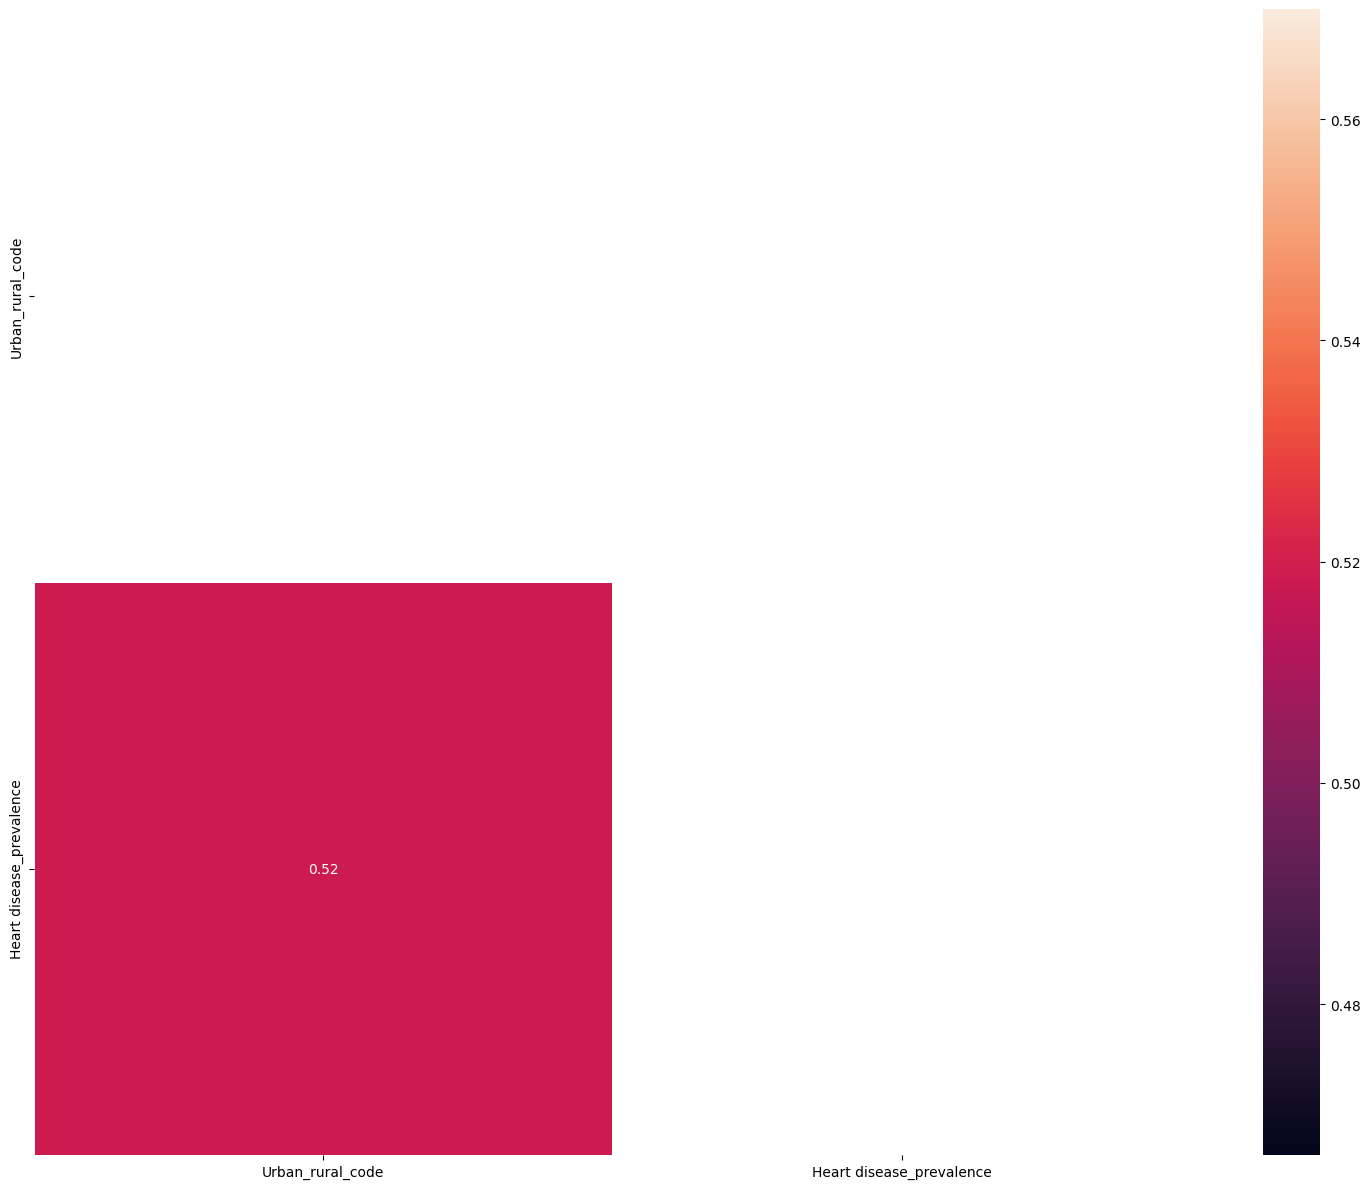

In [ ]:
corr = df[['Urban_rural_code', 'Heart disease_prevalence']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

gente en ciudades + estres...
gente rural vida más tranquila...

In [ ]:
df['Urban_rural_code'].unique()

array([3, 4, 6, 2, 5, 1])

In [ ]:
df['Urban_rural_code']

0       3
1       4
2       6
3       2
4       2
       ..
3135    5
3136    5
3137    5
3138    6
3139    6
Name: Urban_rural_code, Length: 3140, dtype: int64

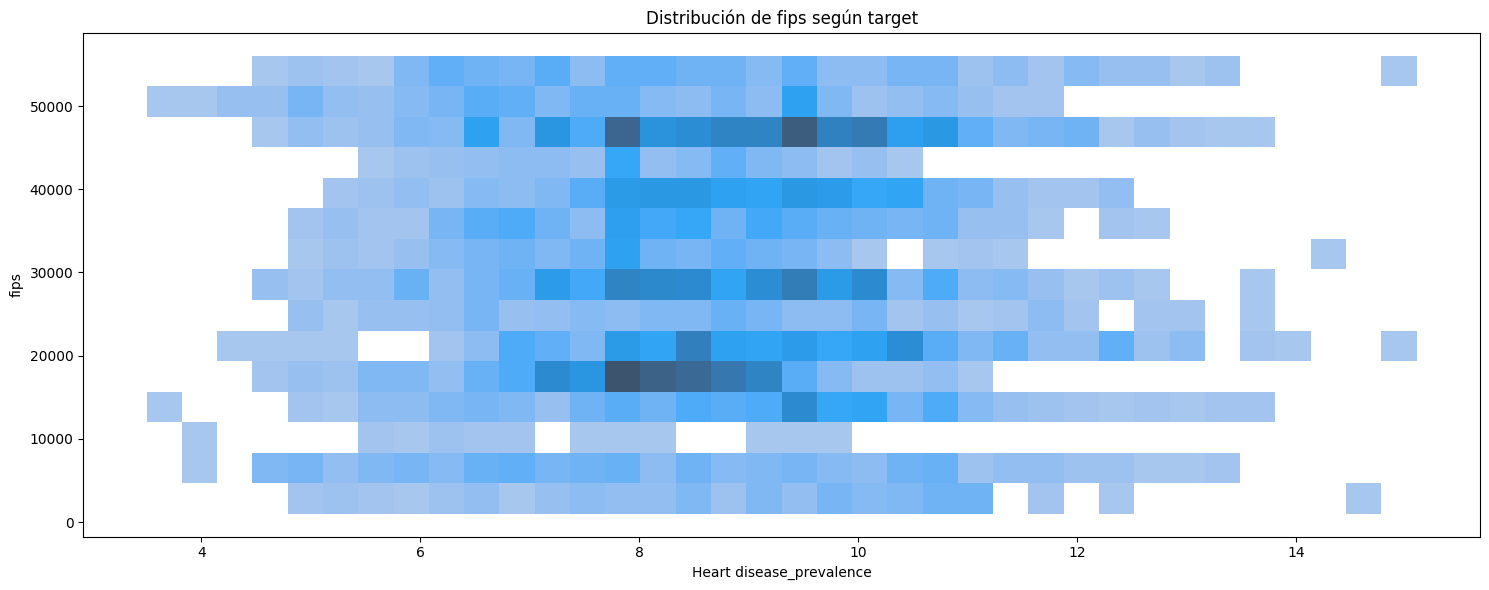

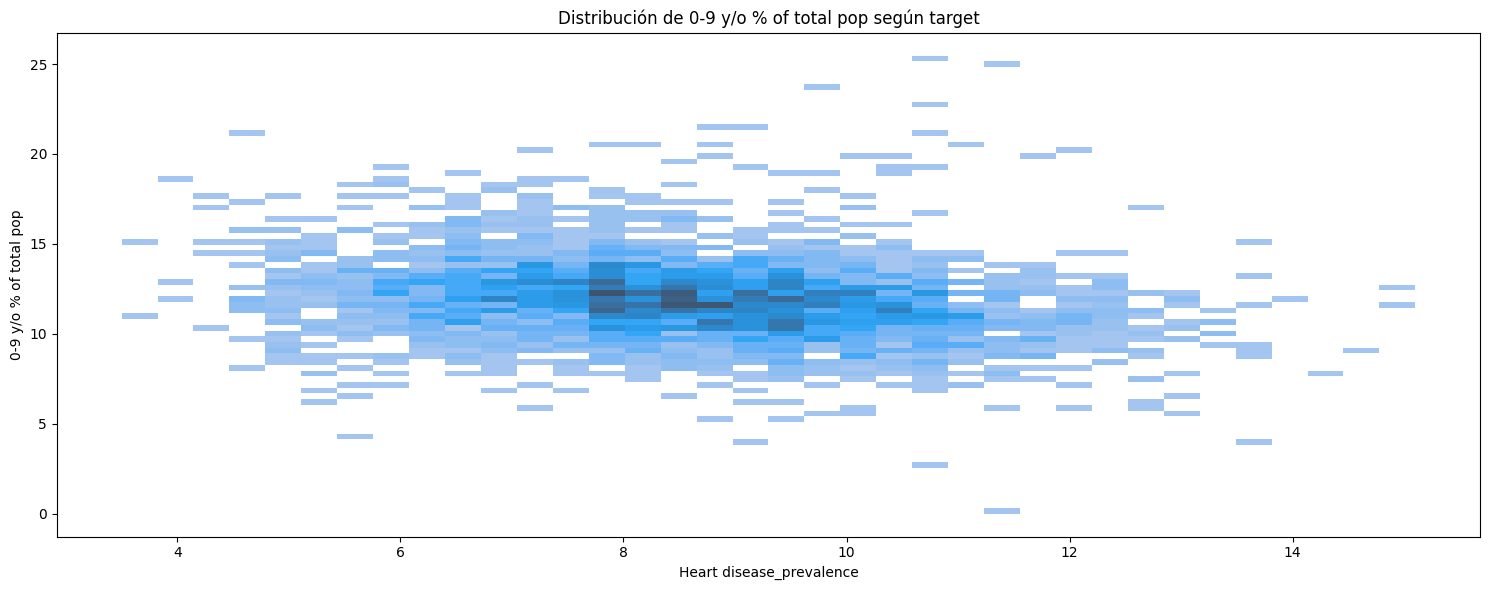

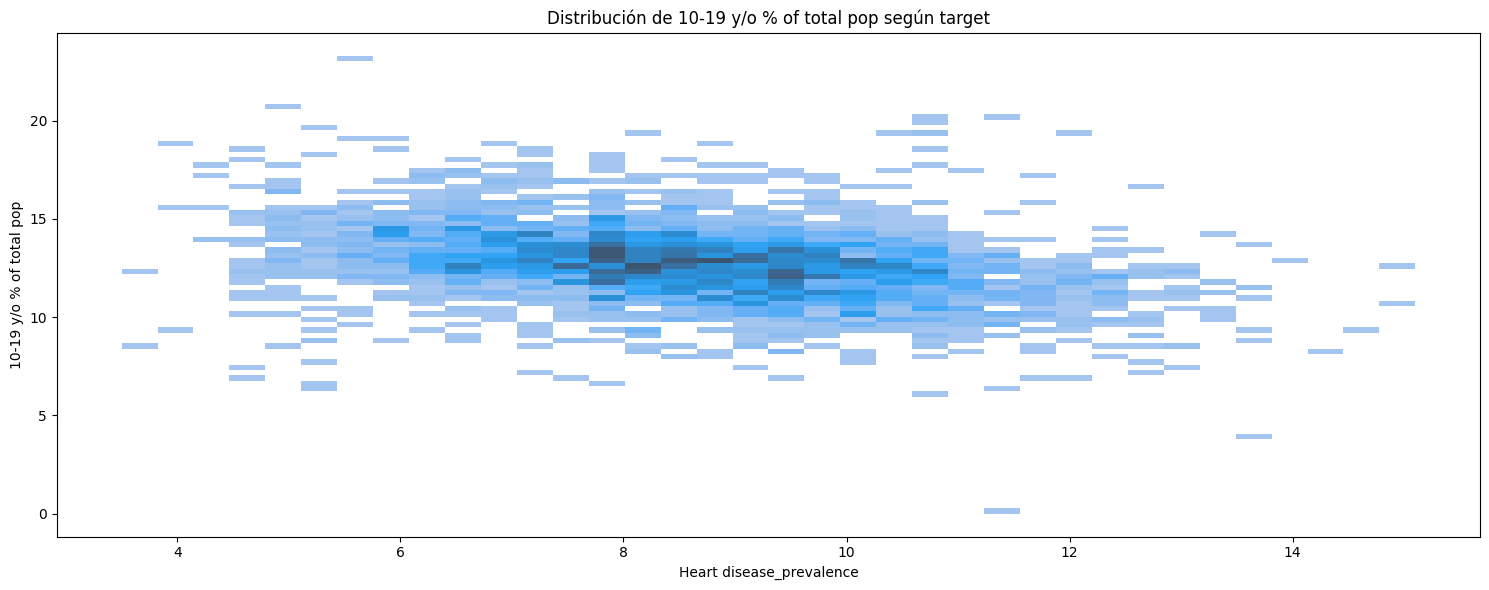

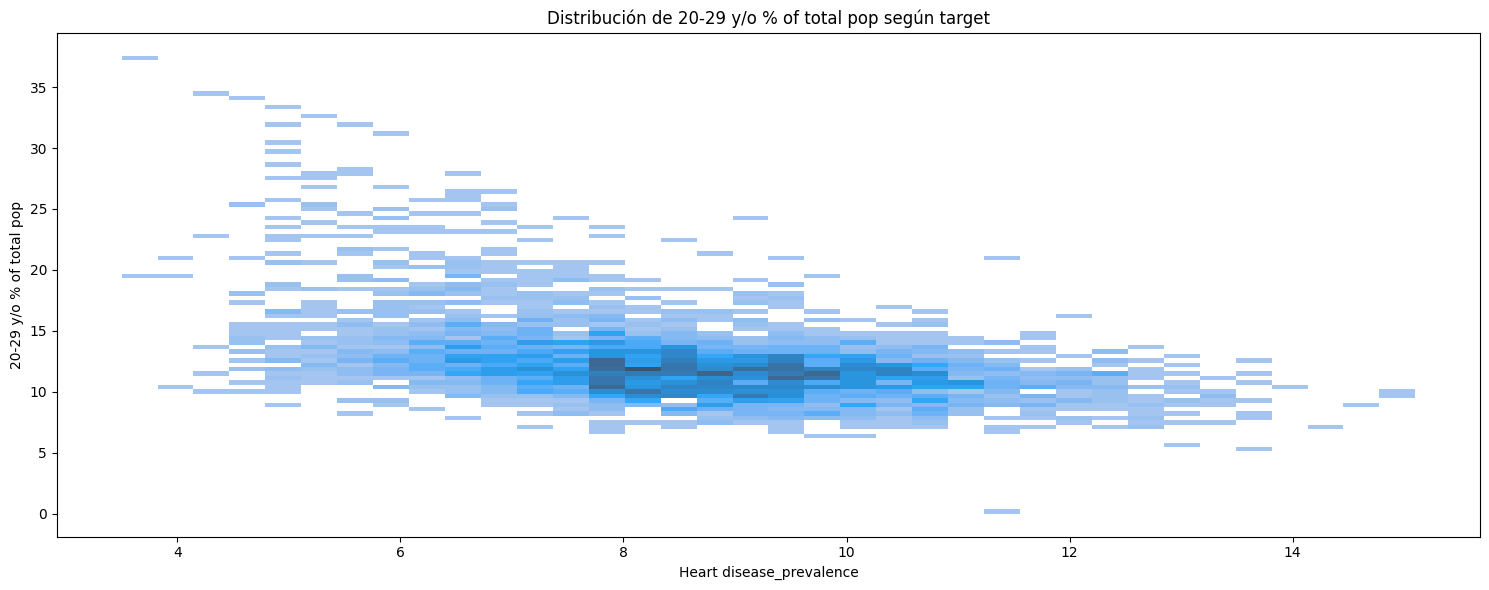

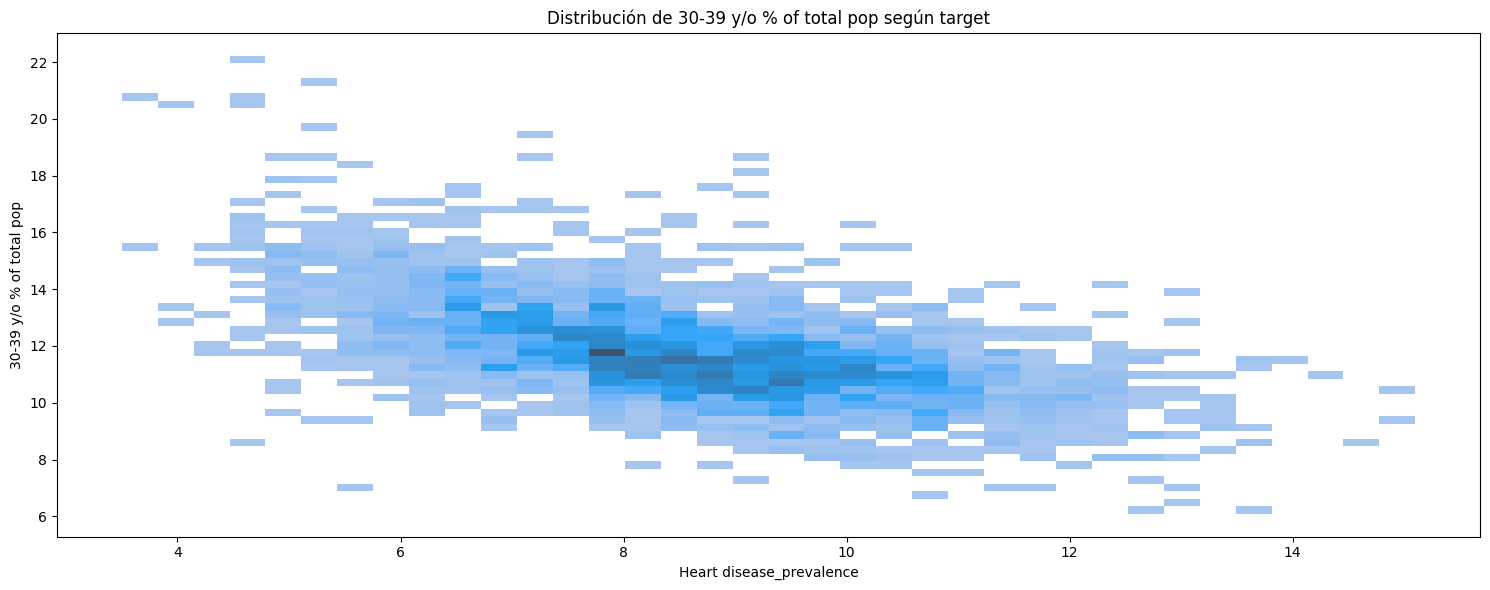

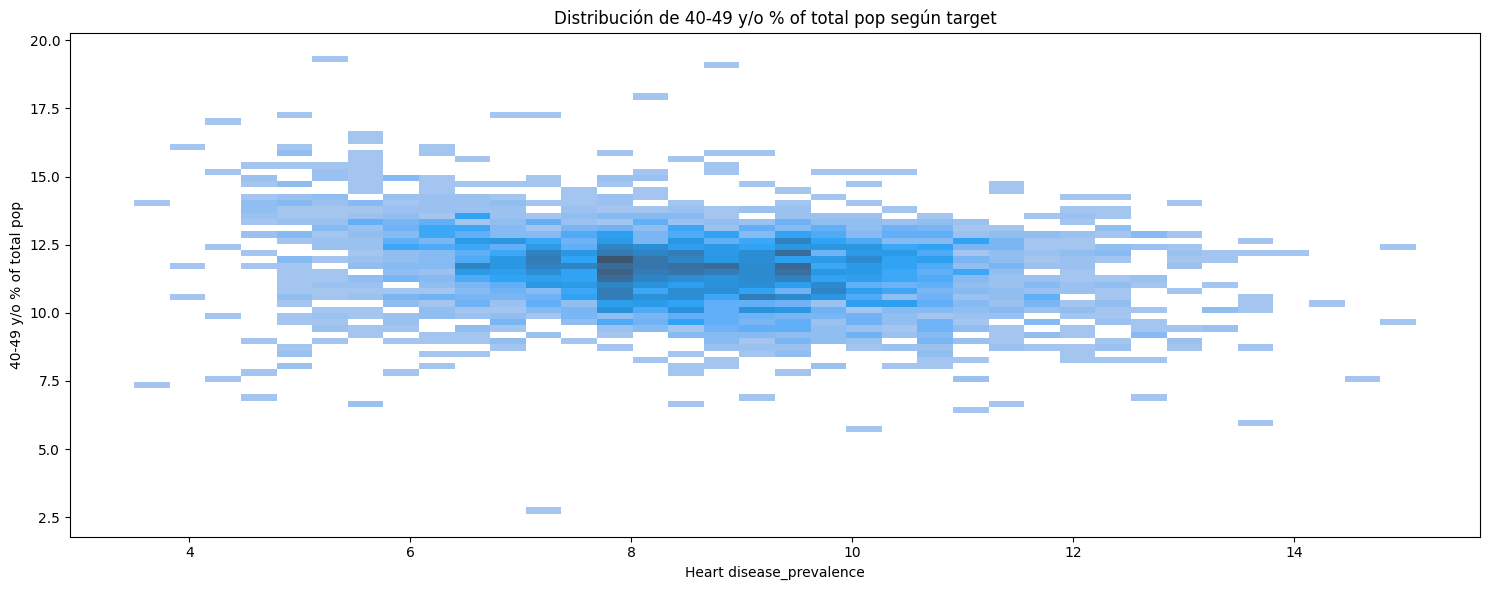

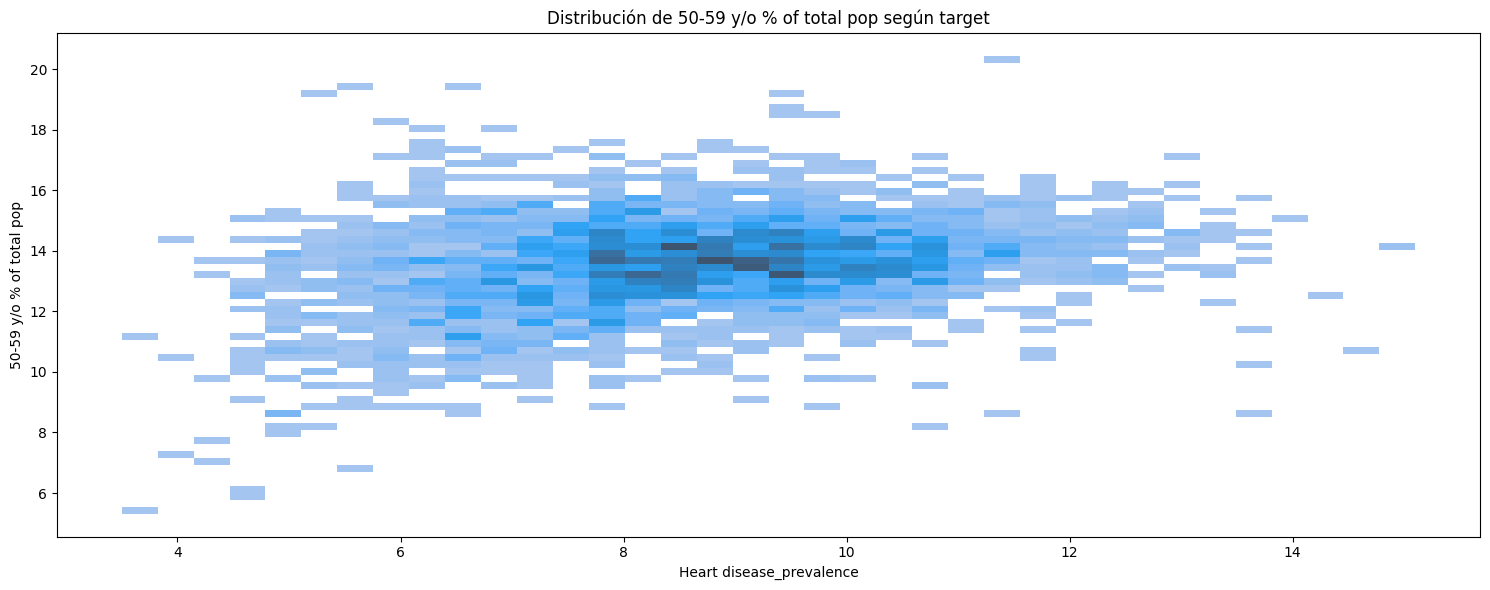

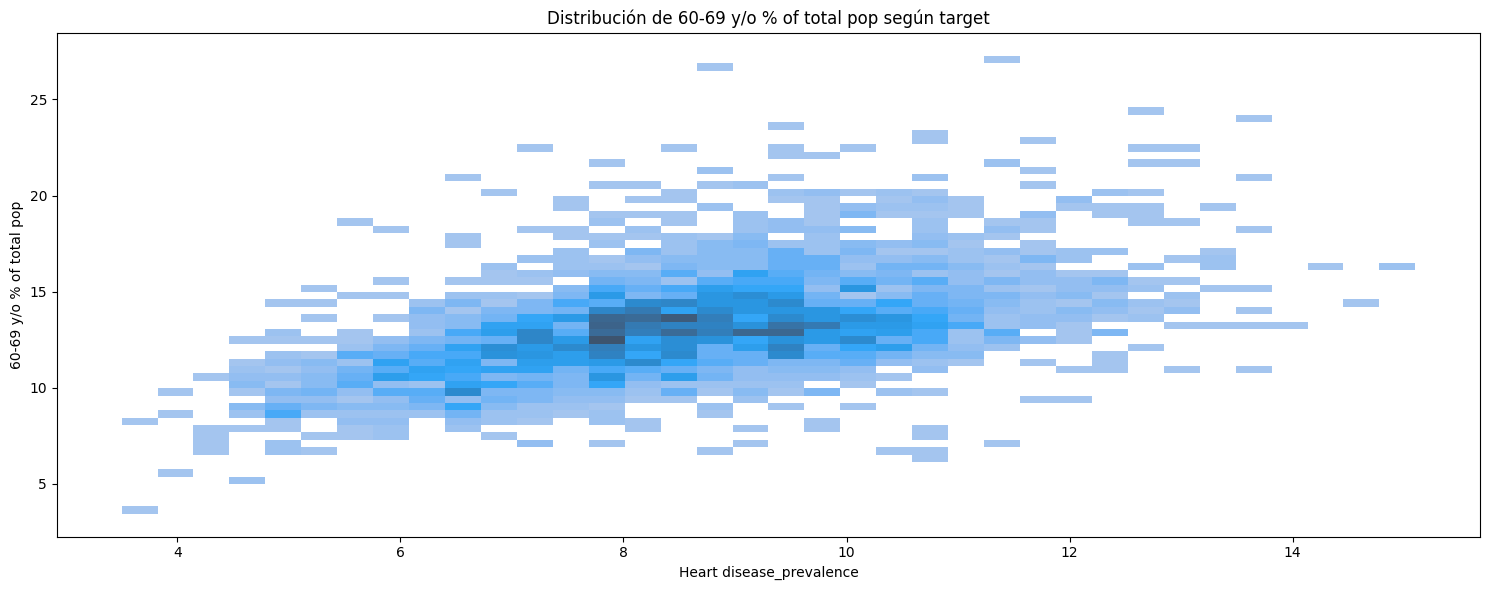

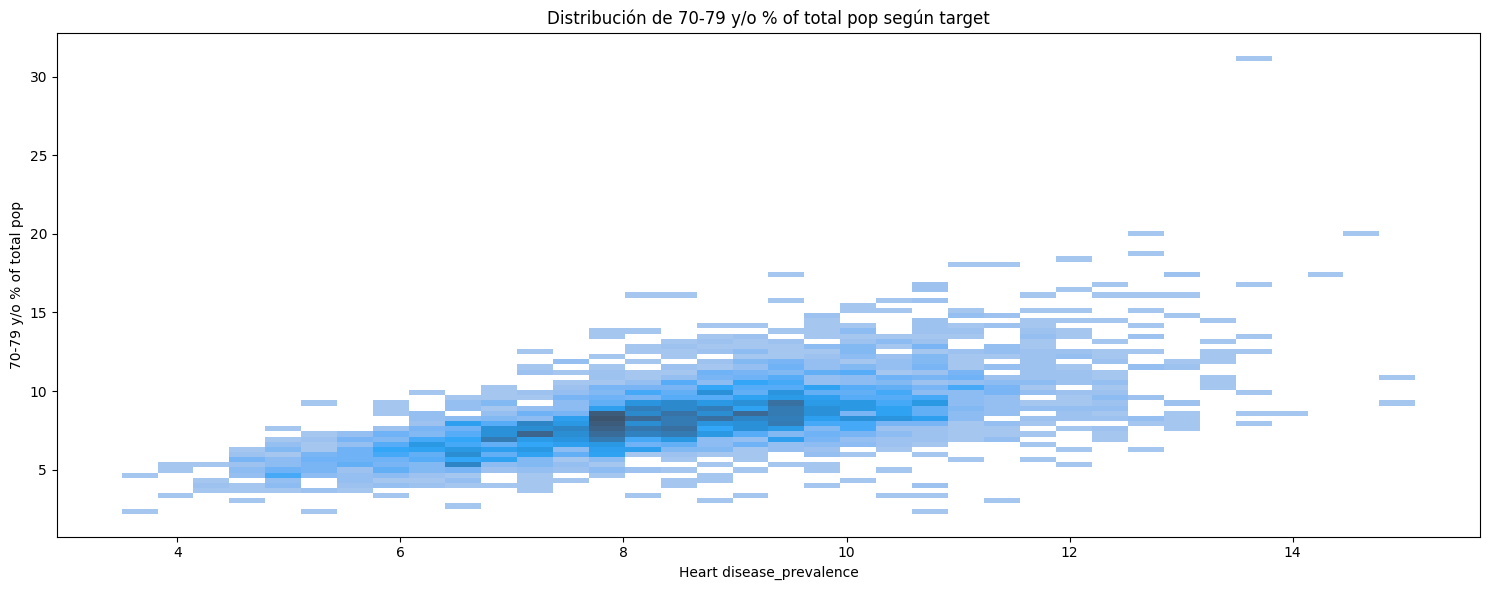

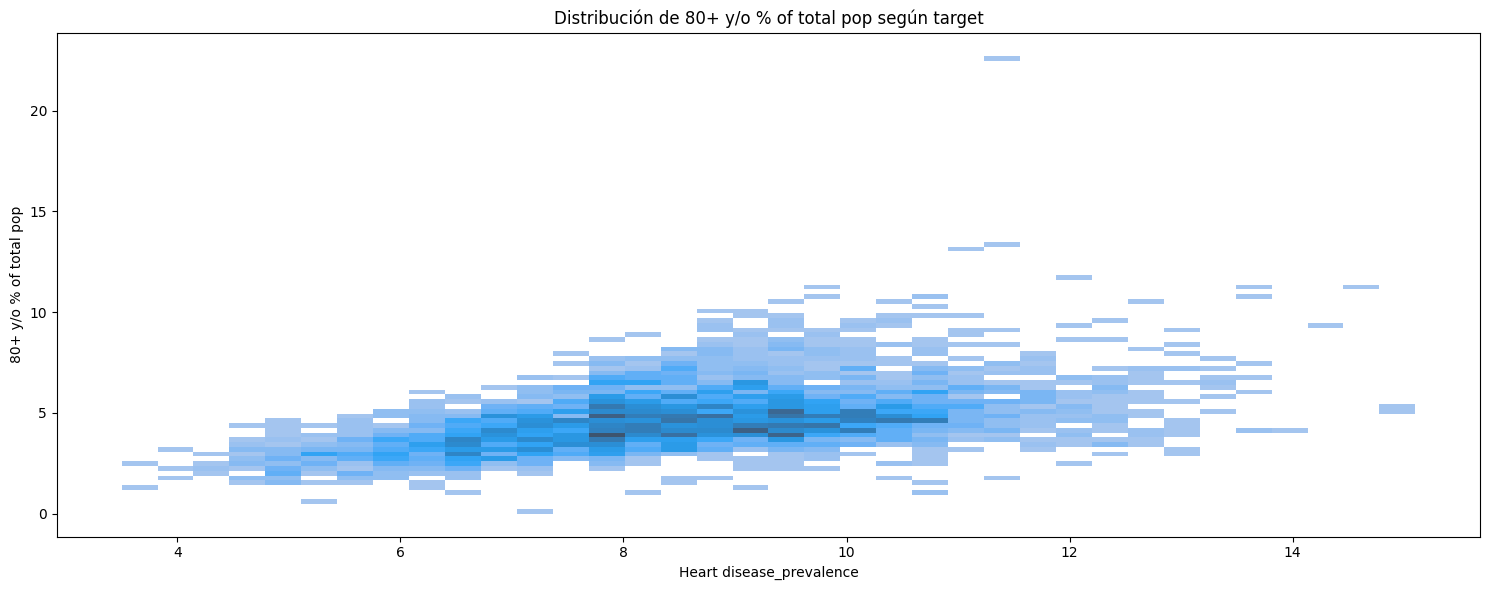

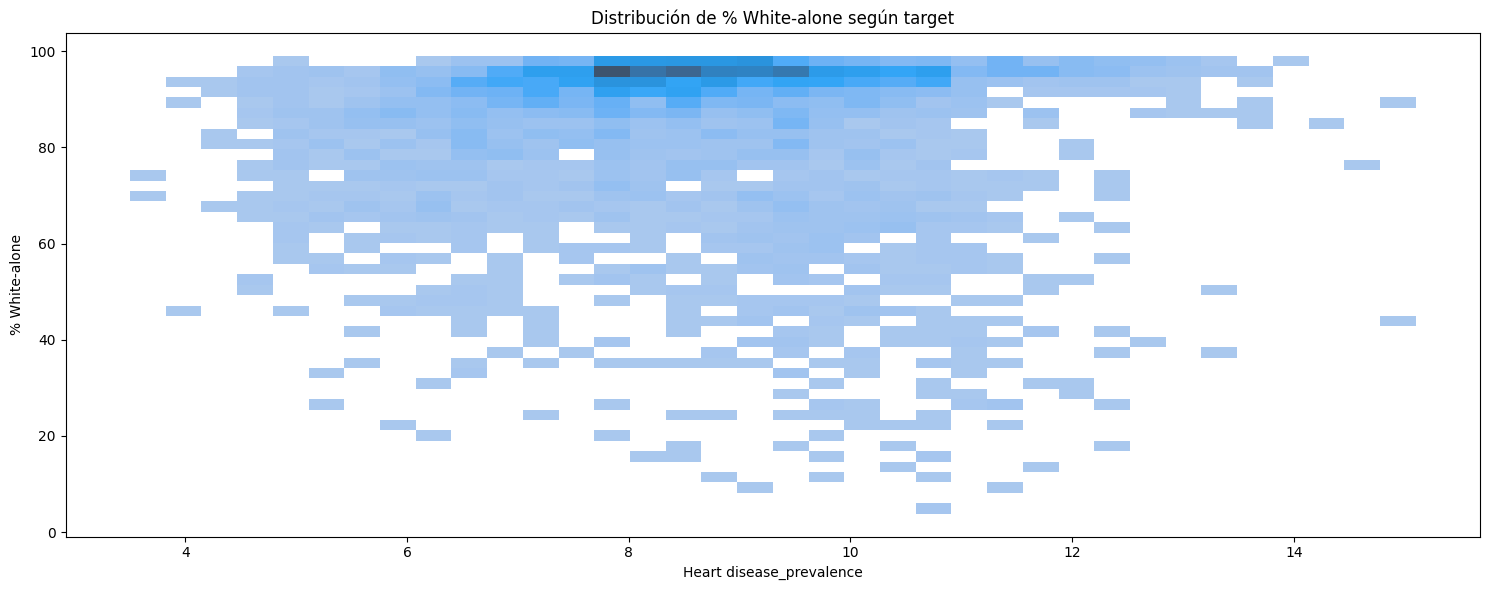

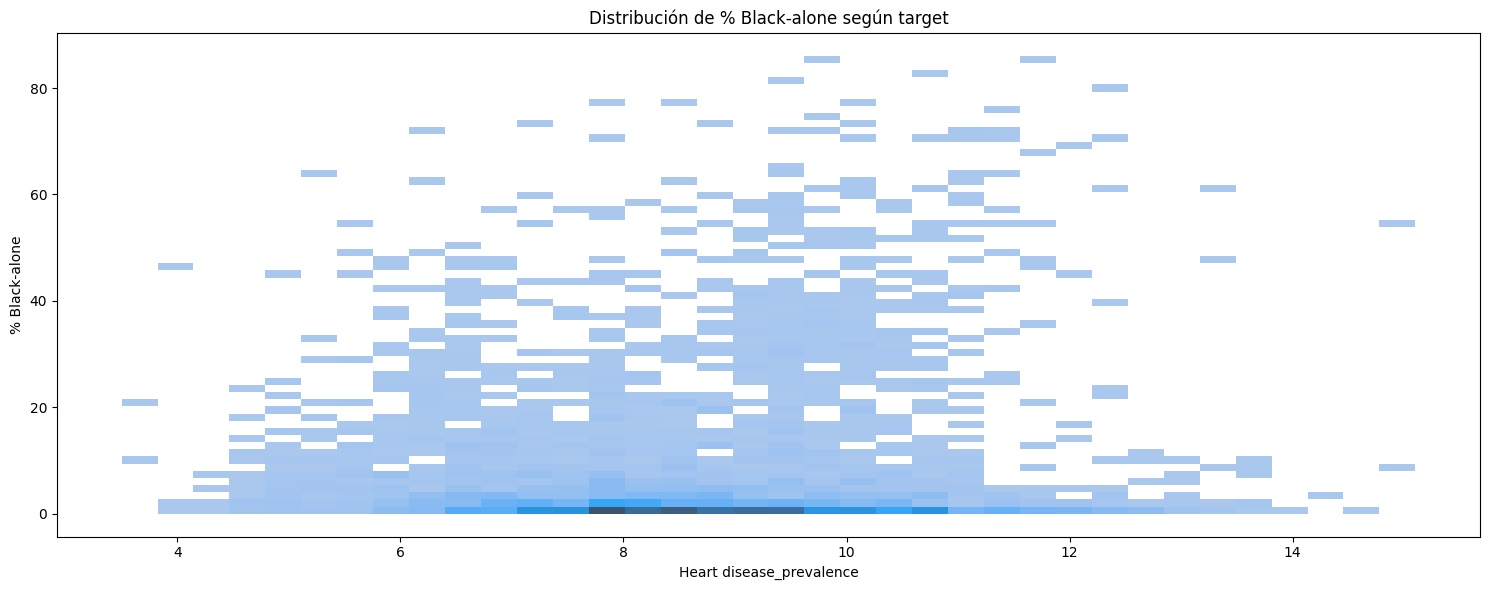

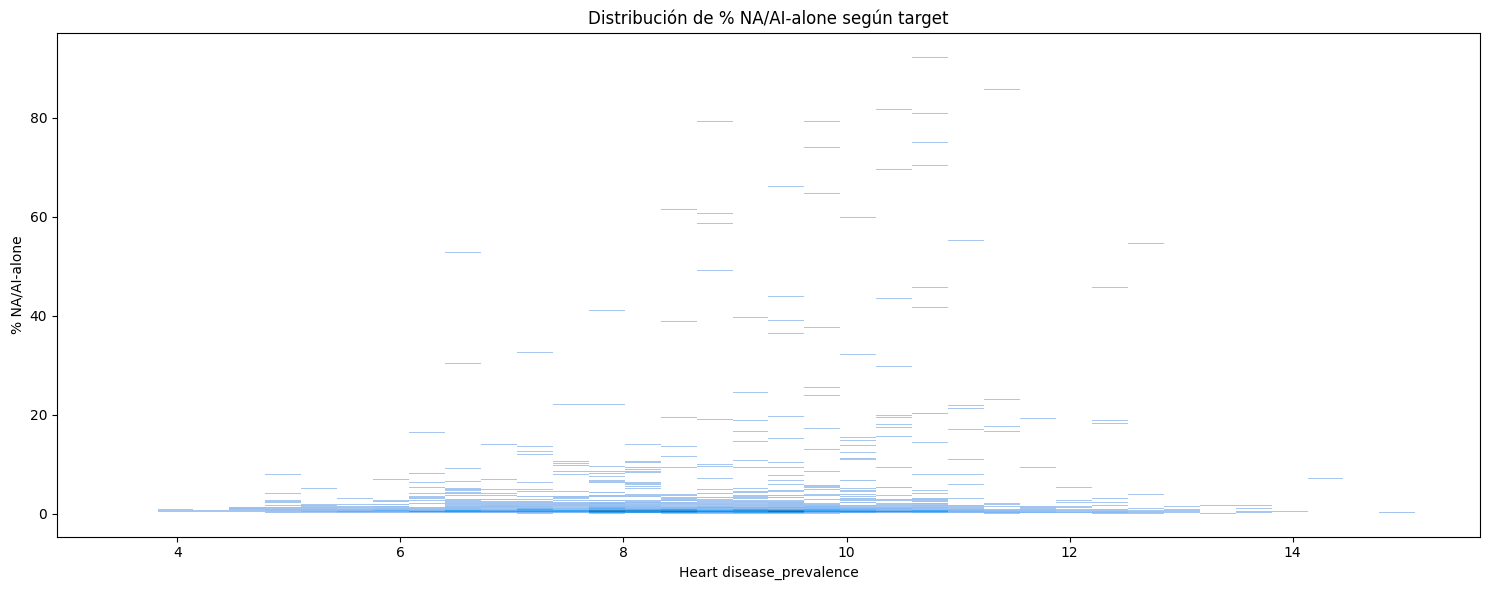

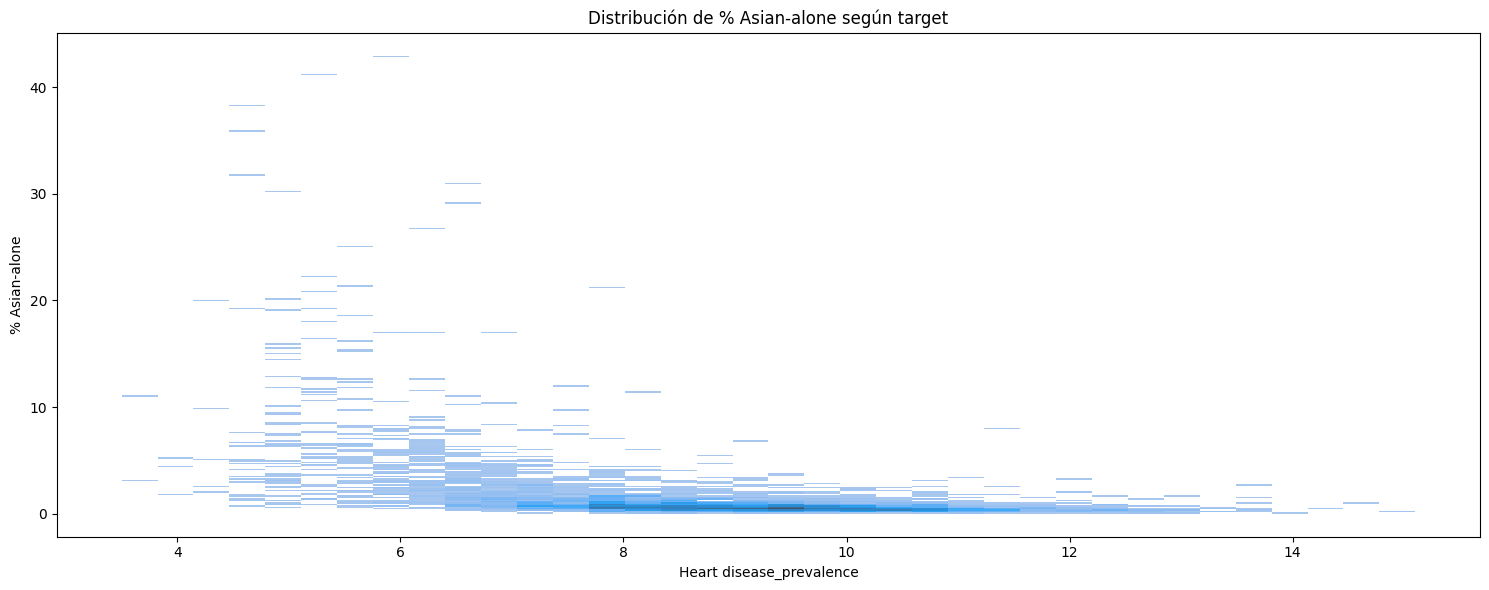

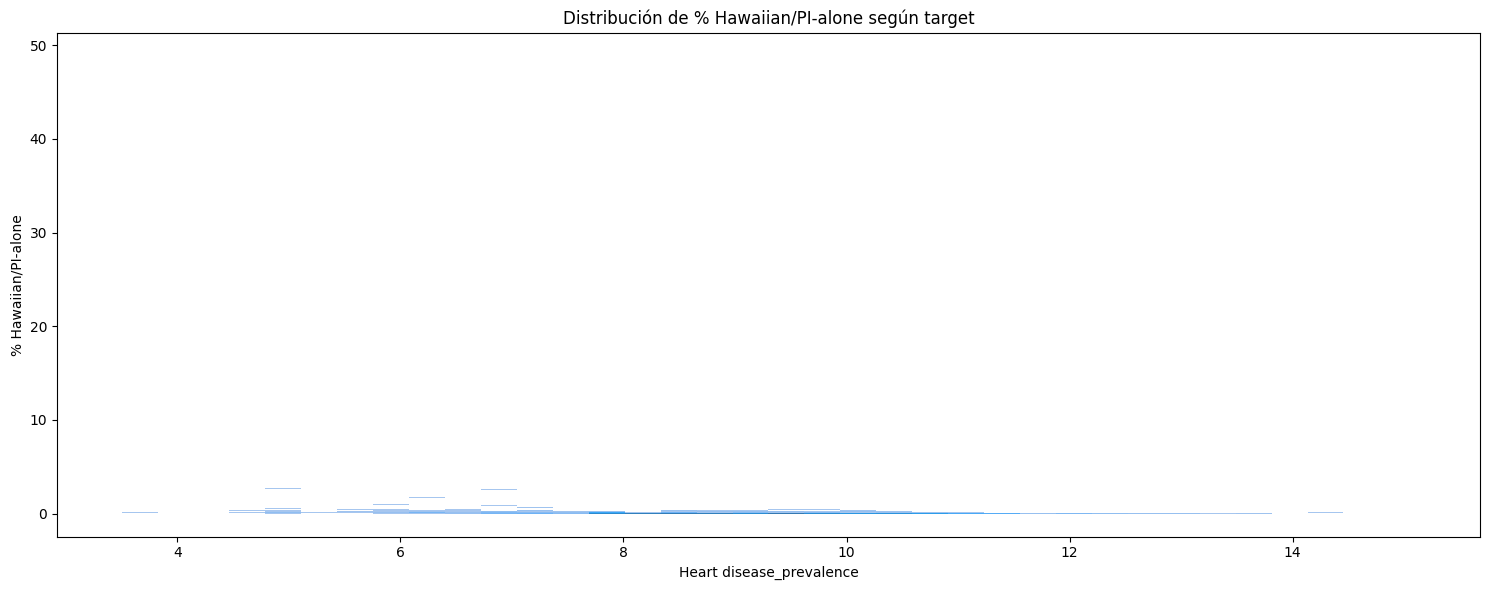

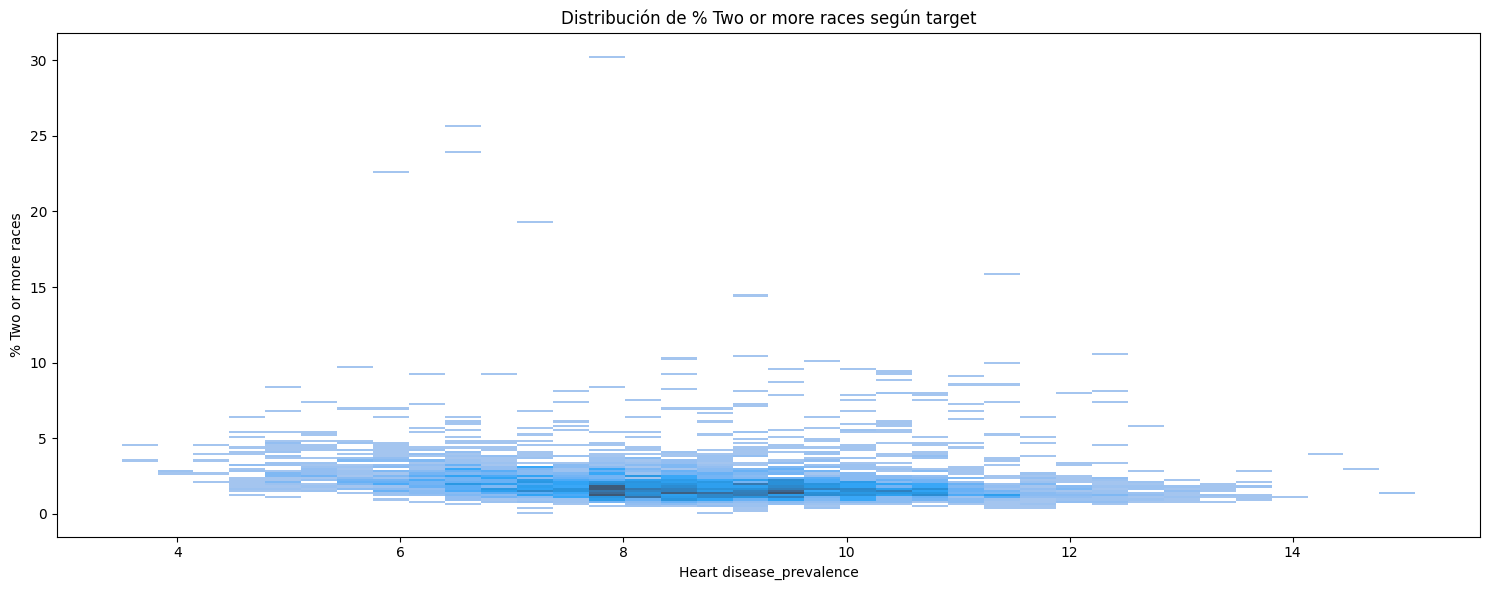

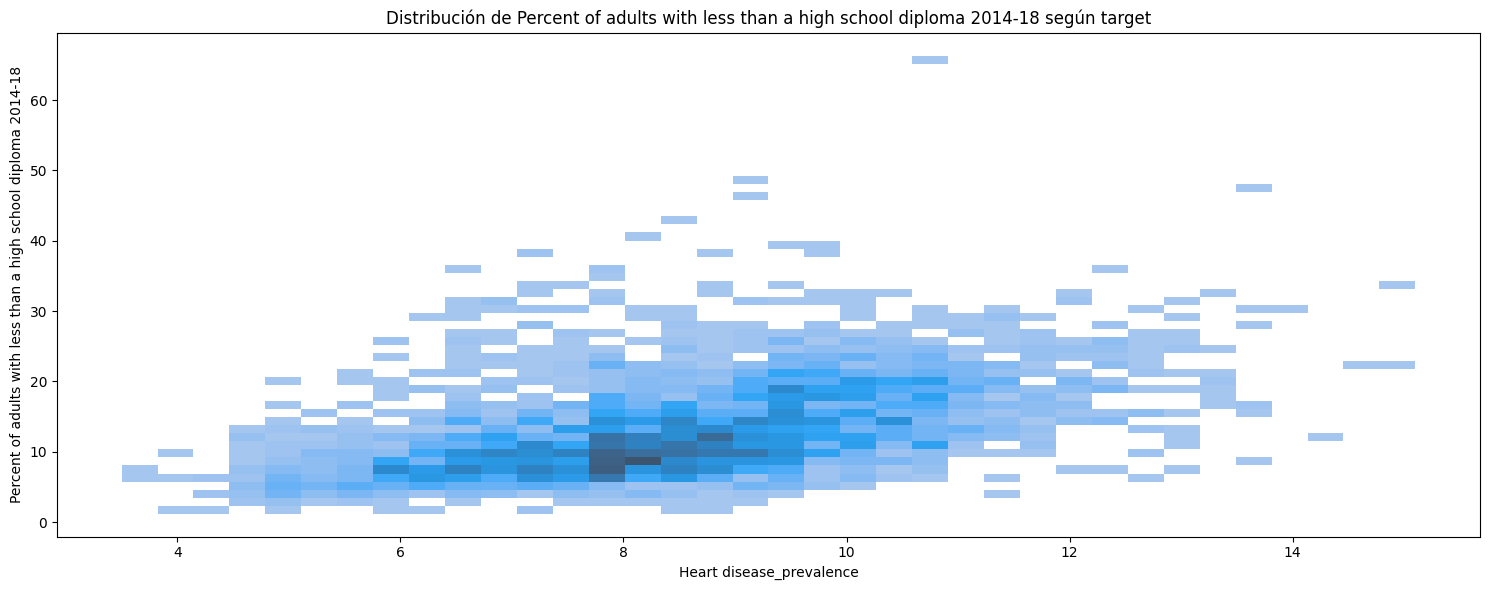

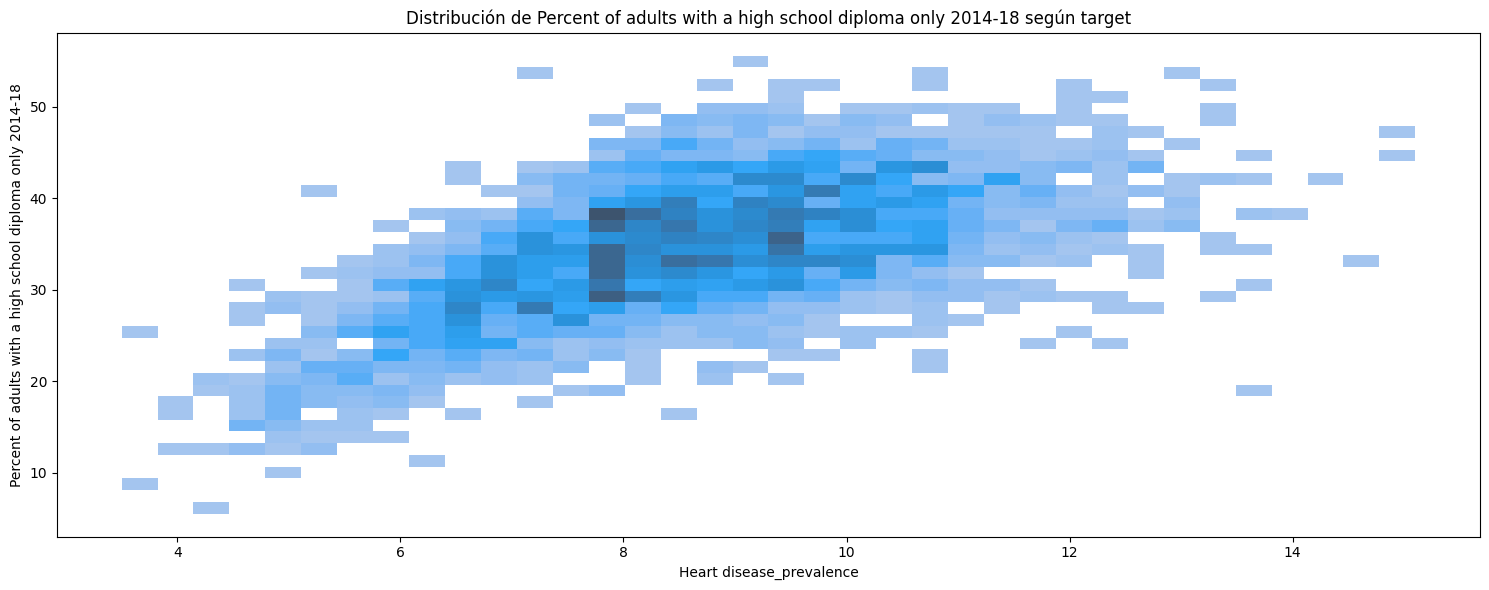

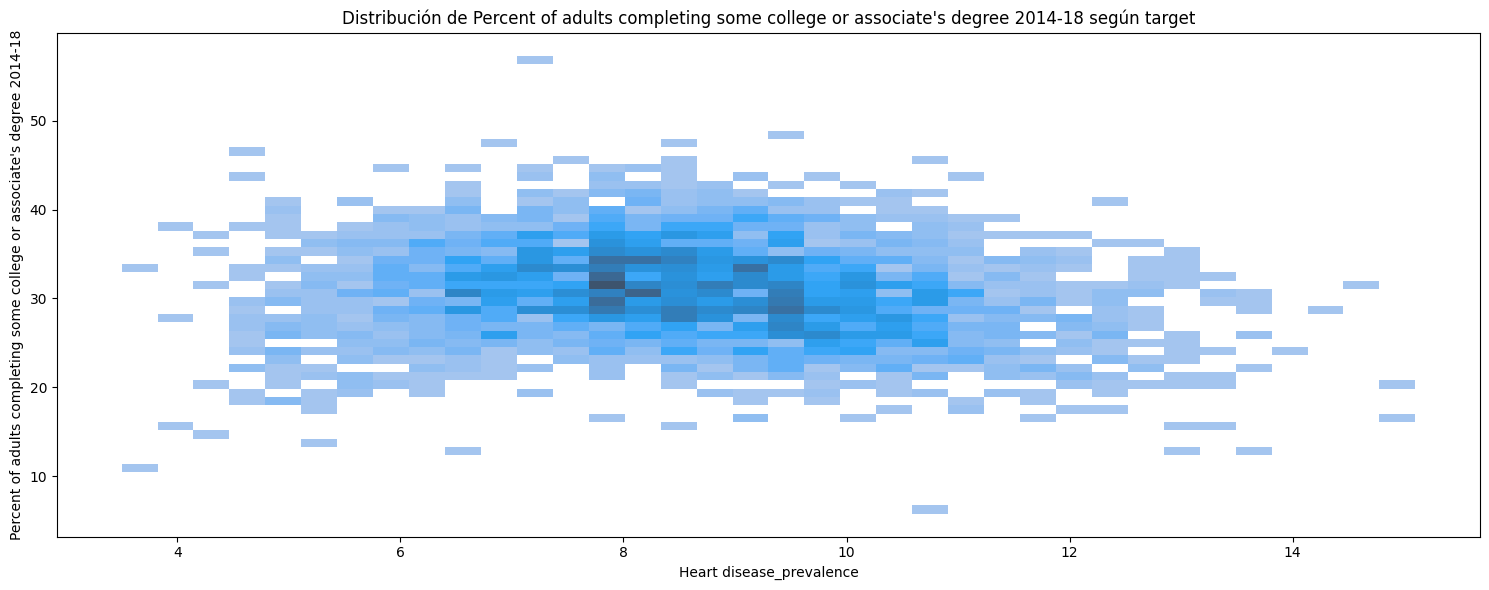

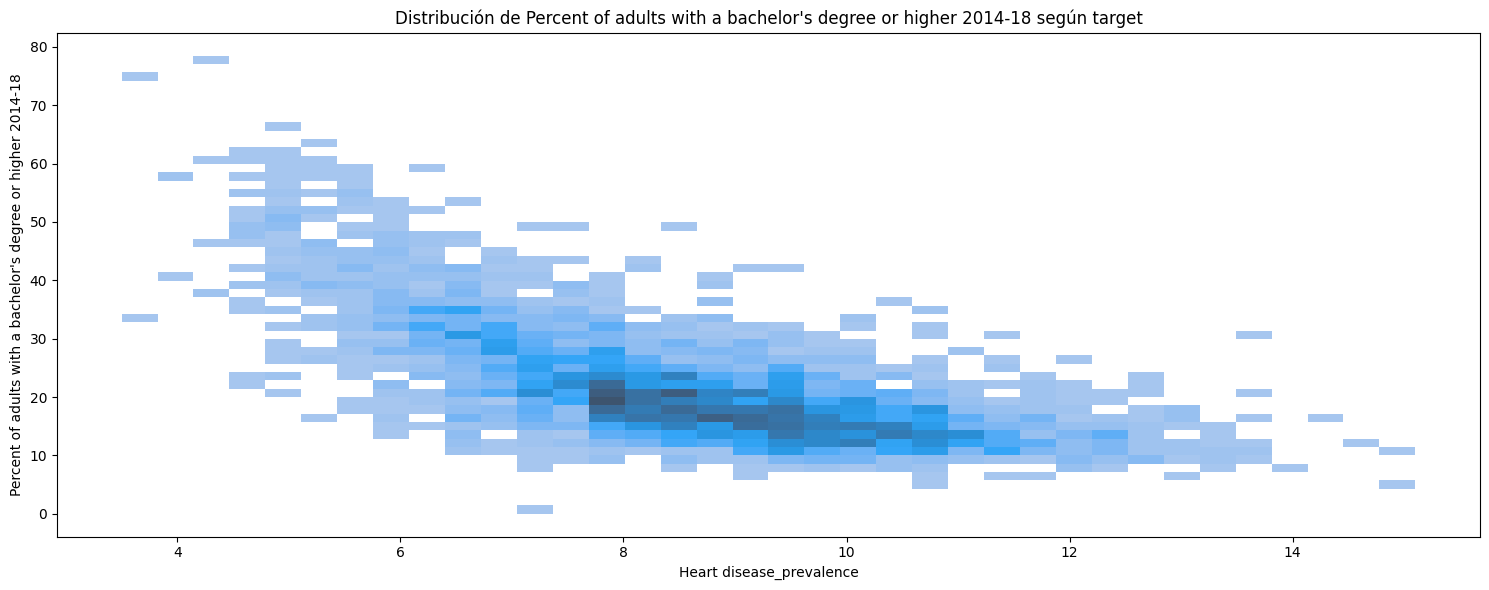

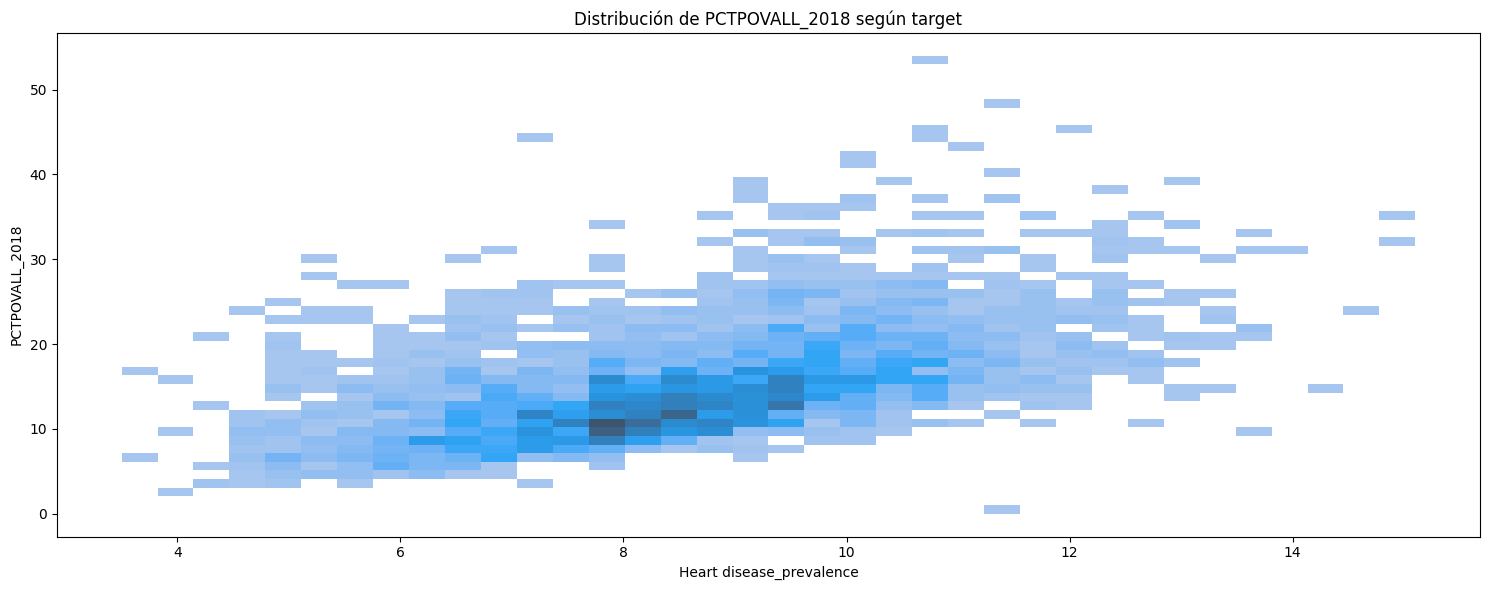

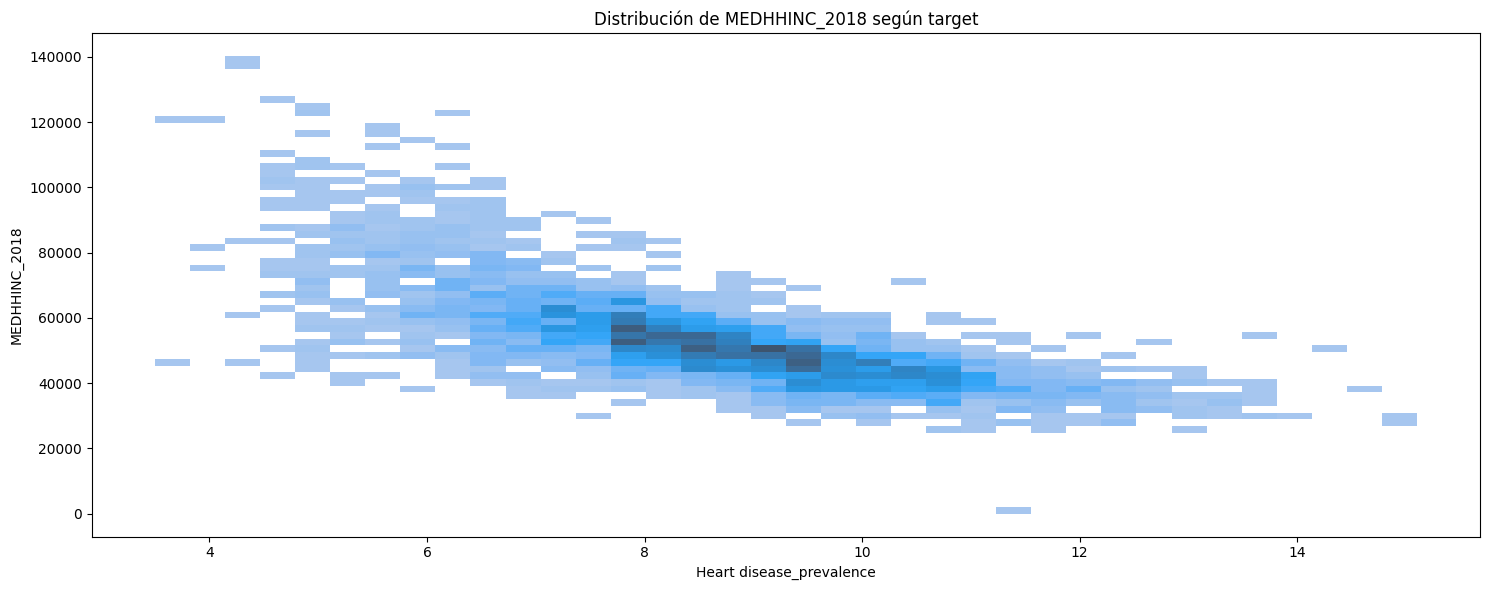

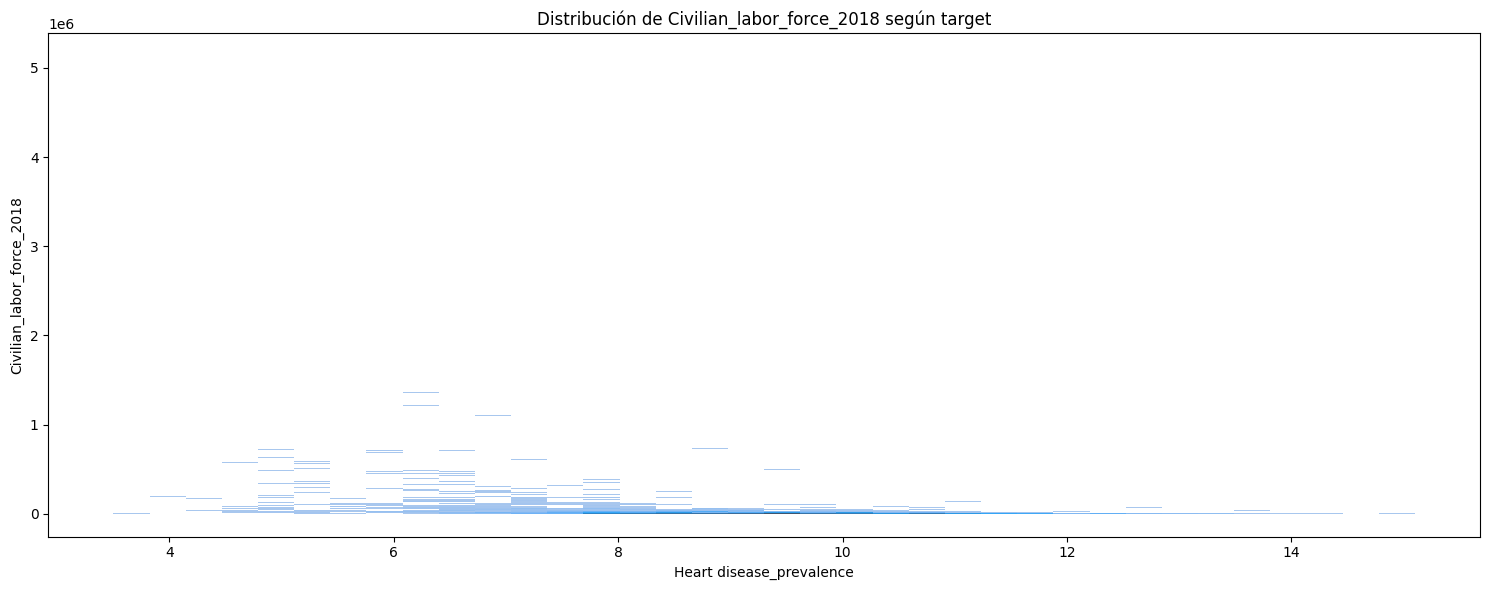

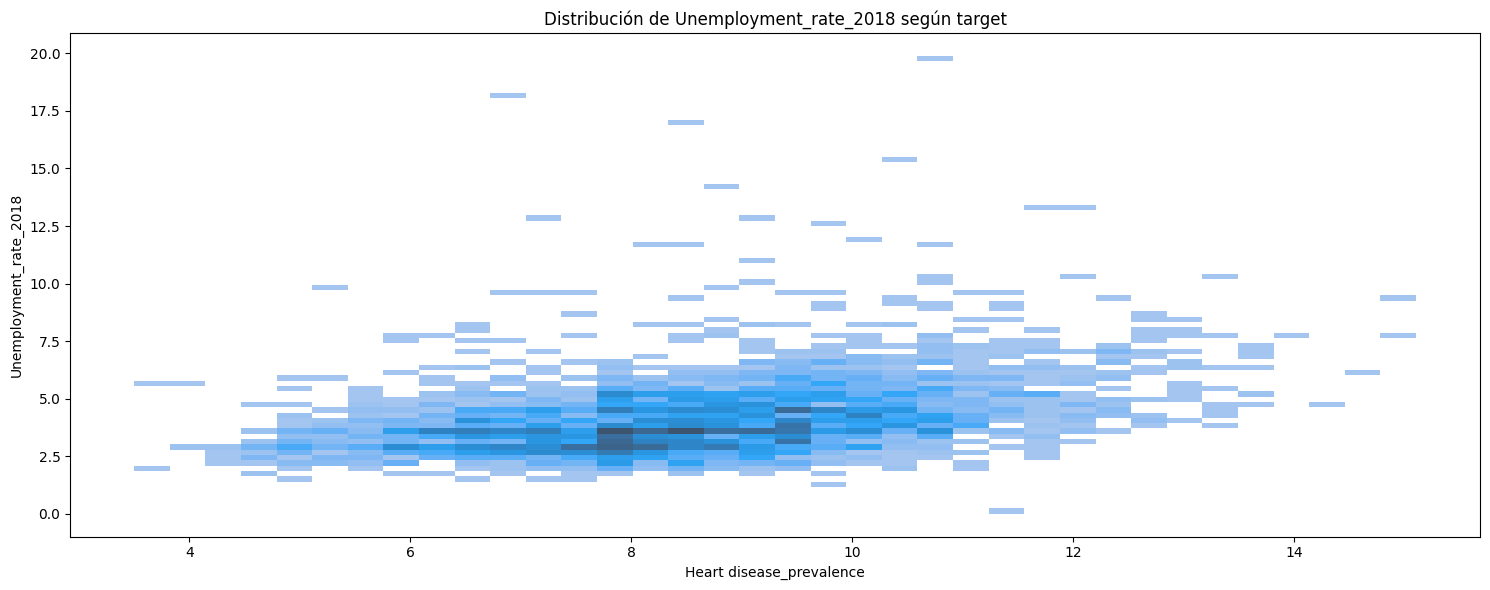

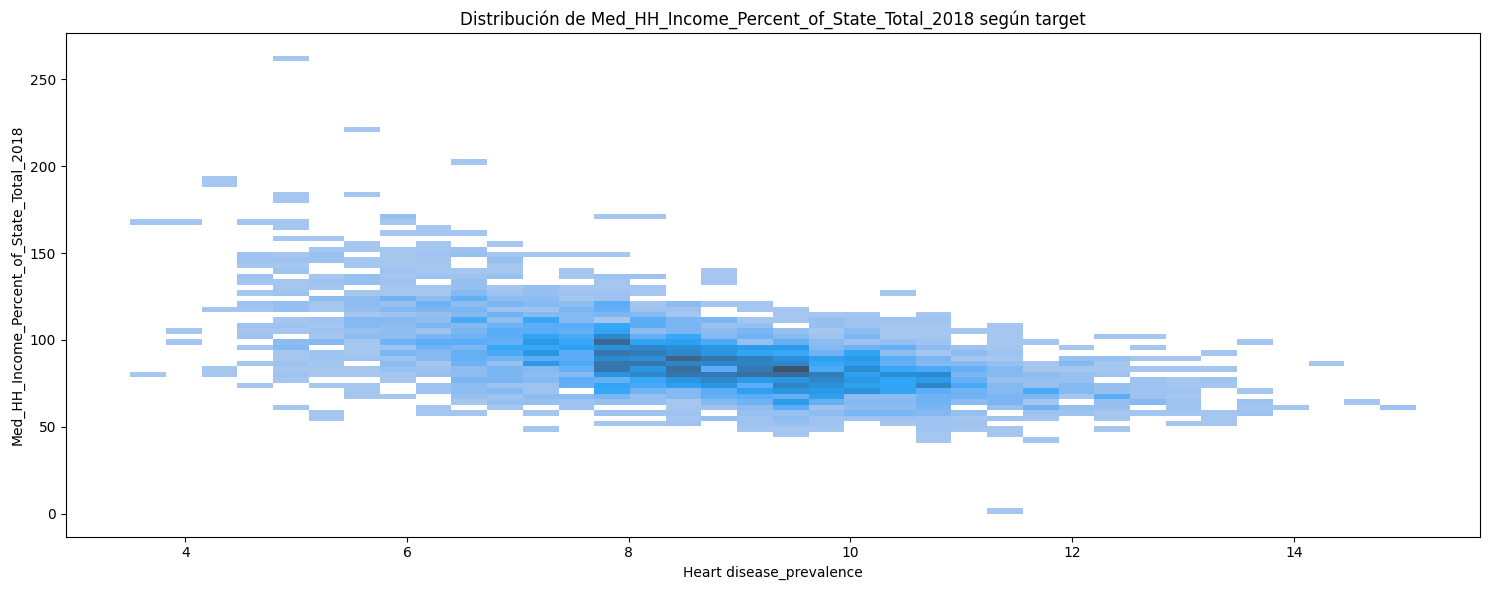

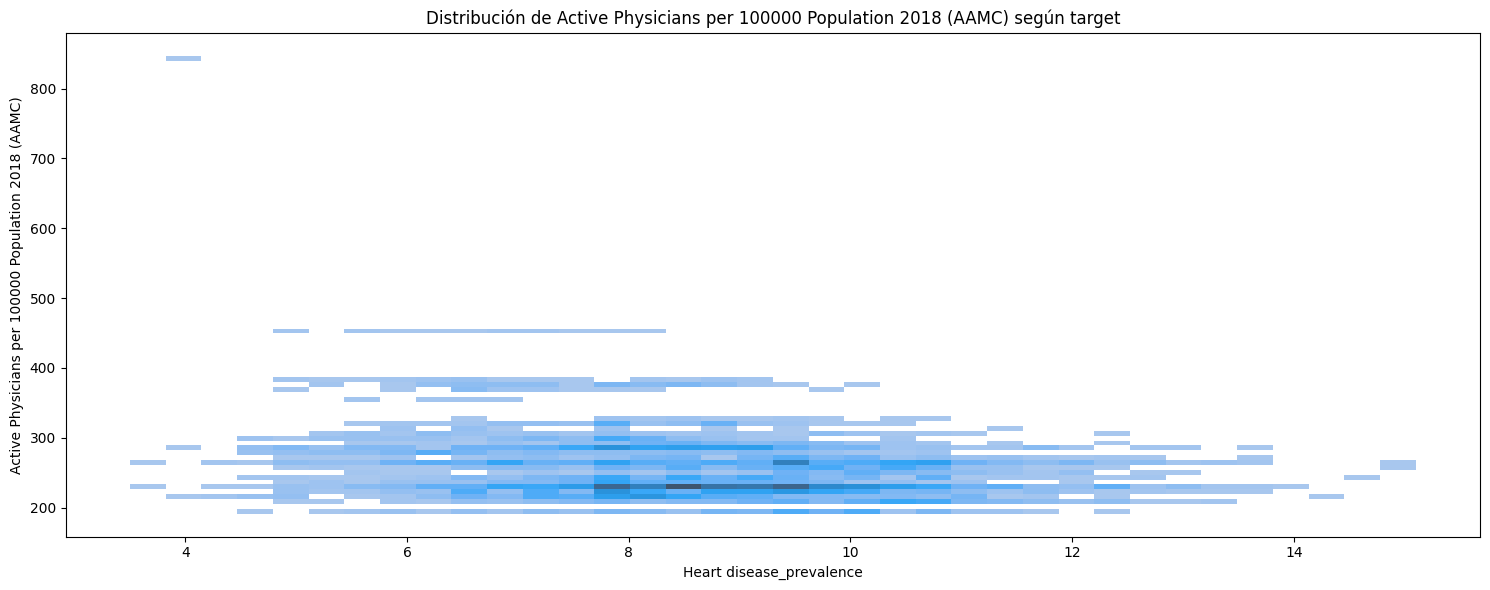

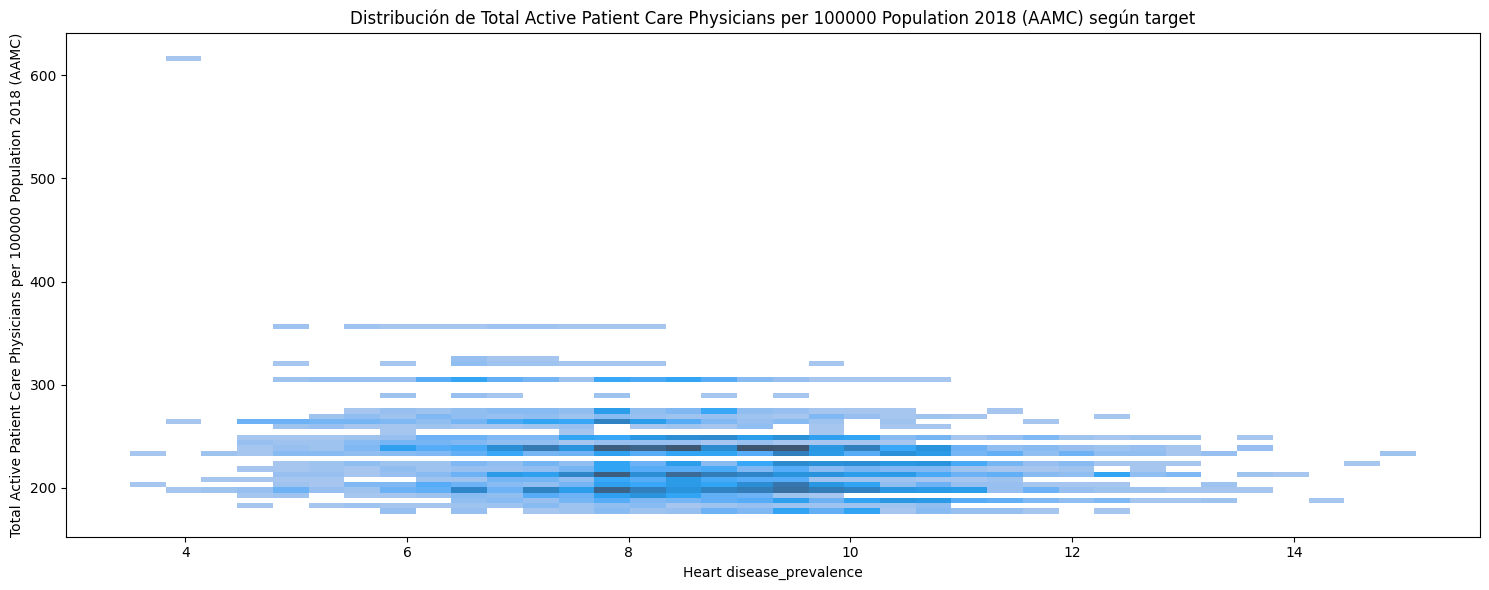

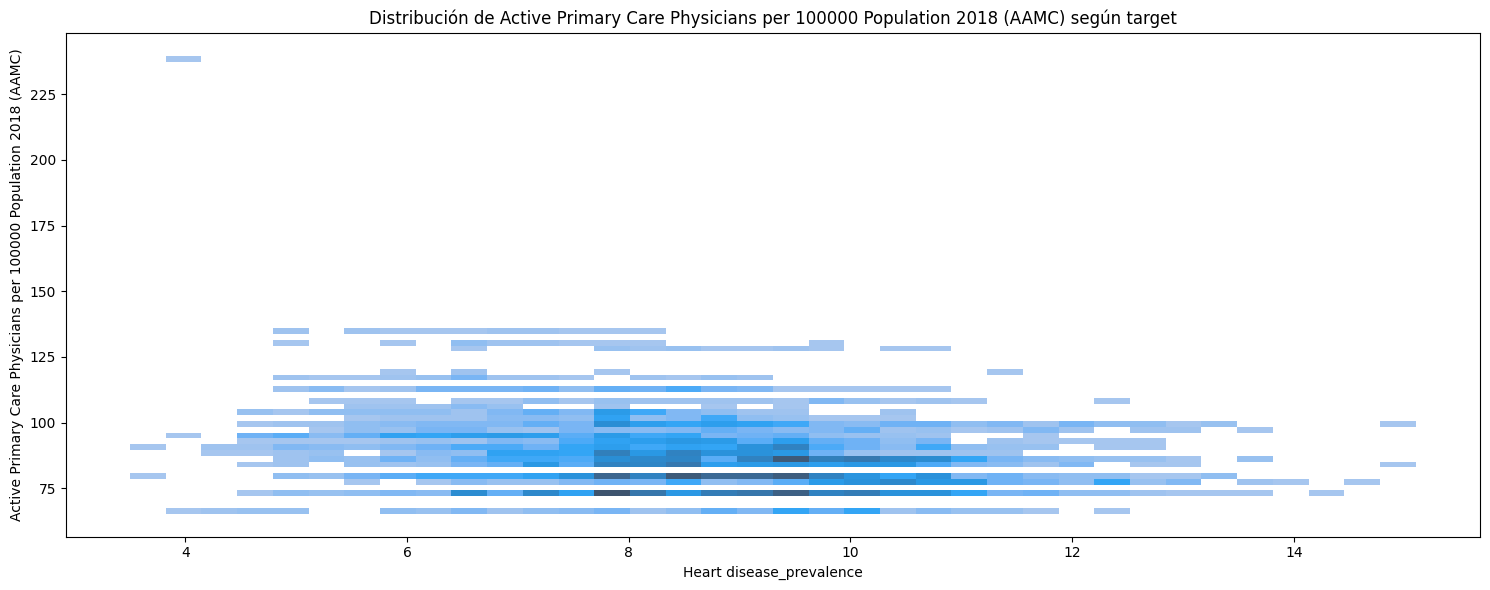

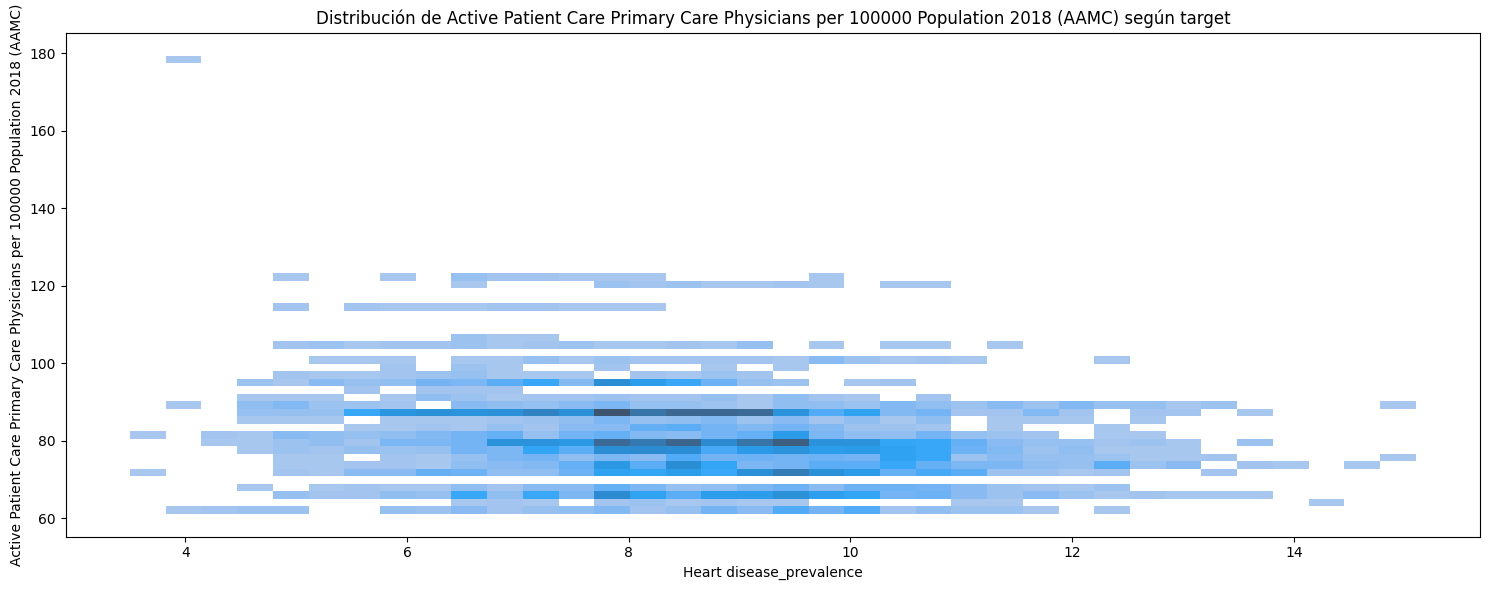

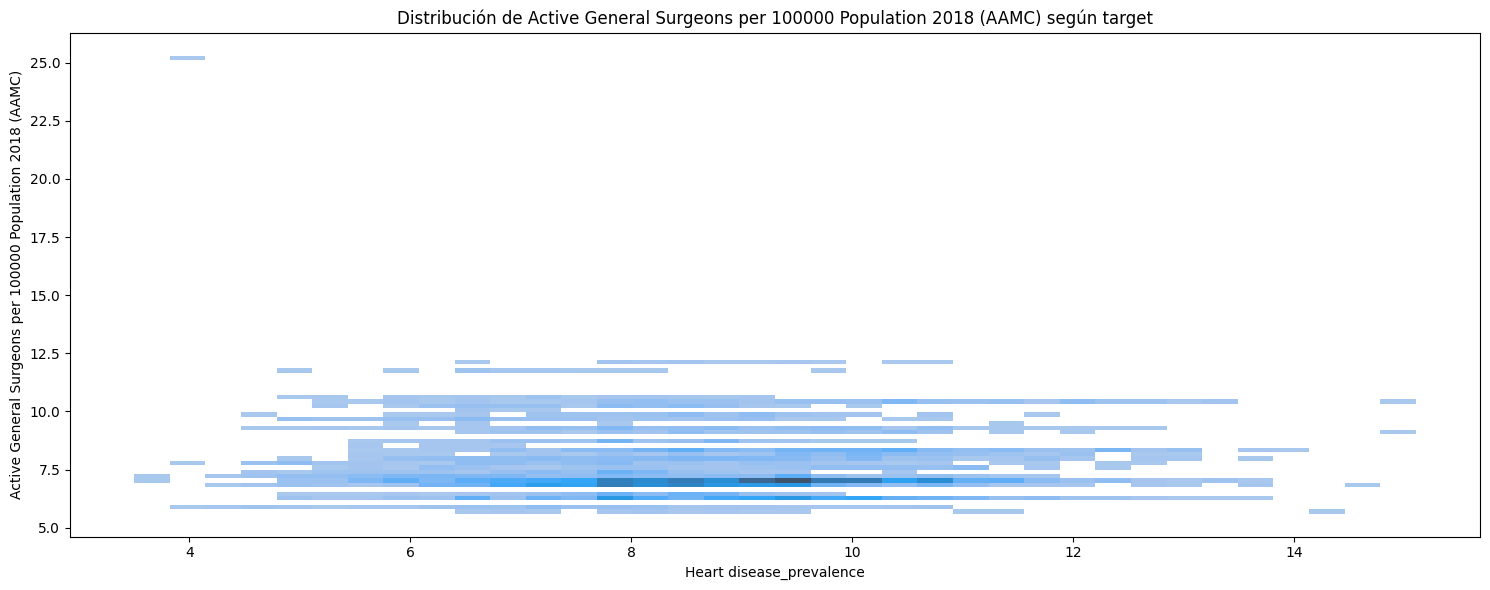

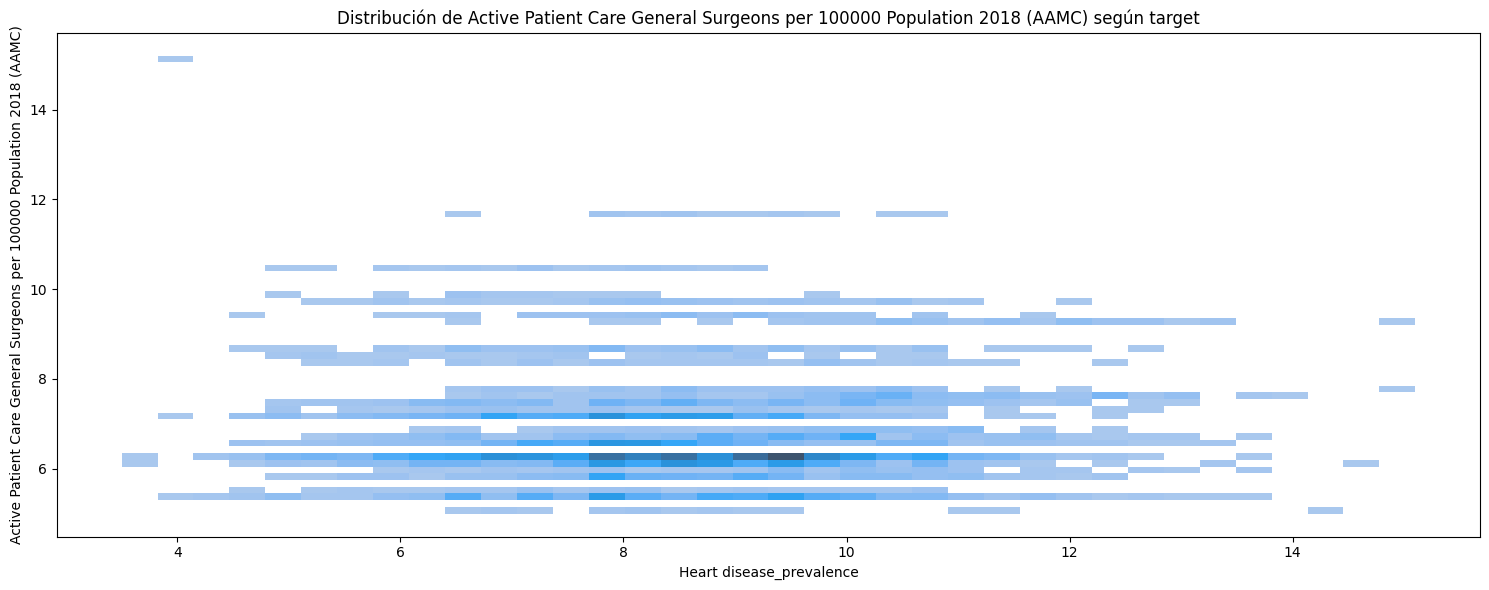

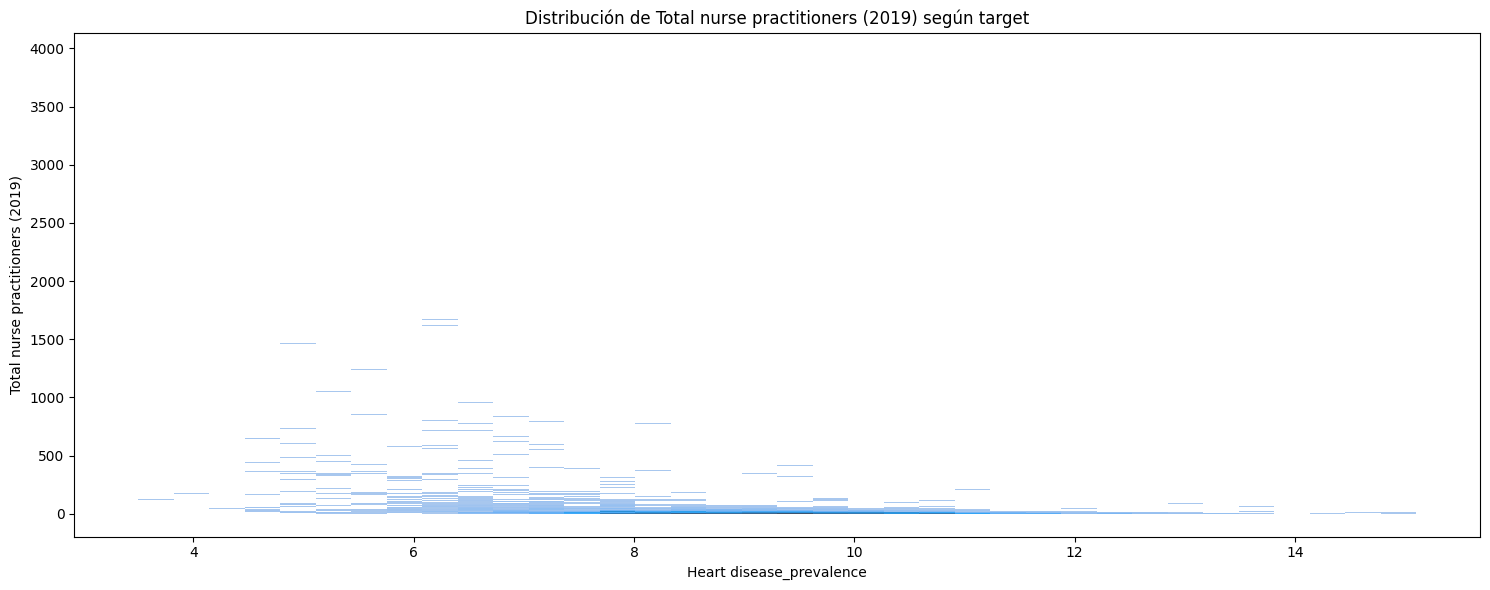

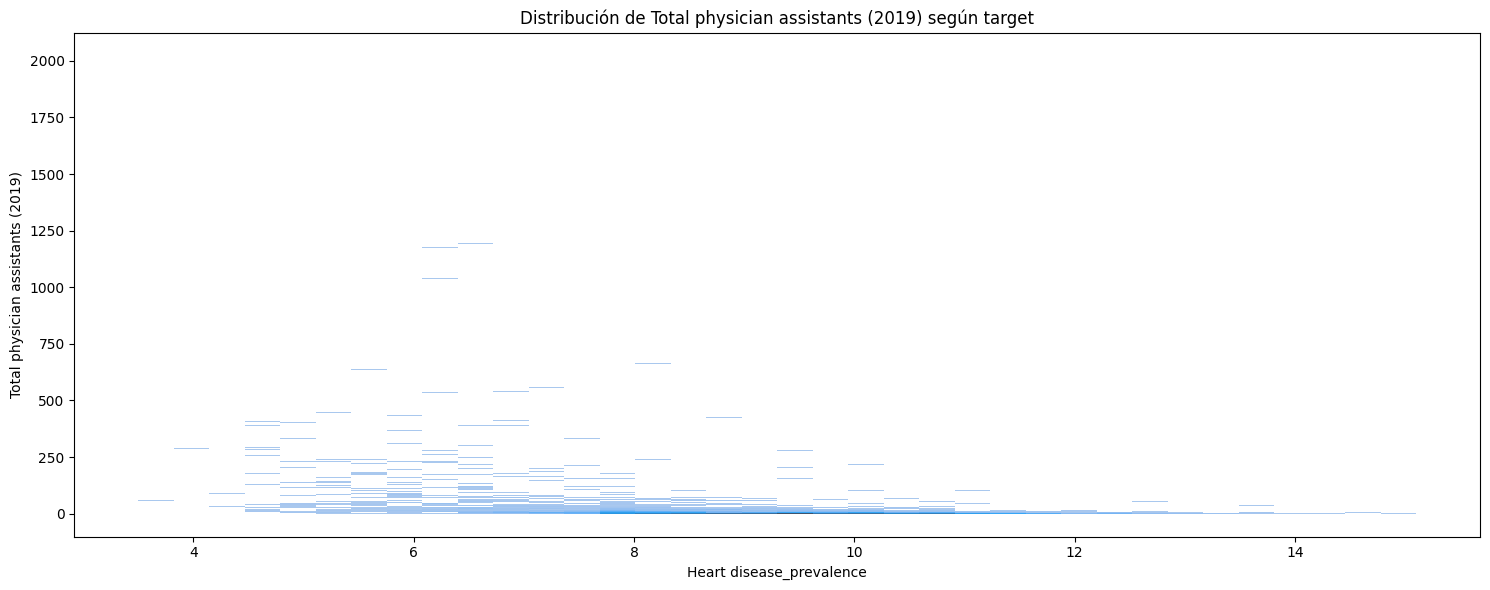

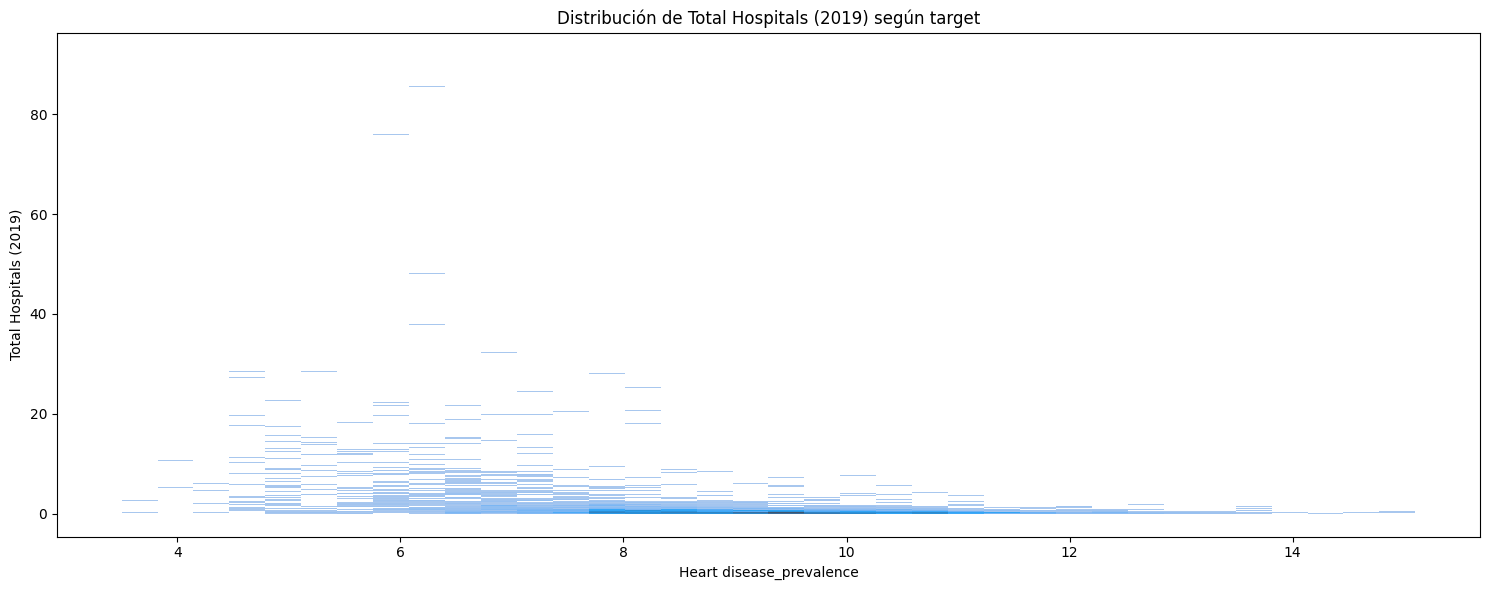

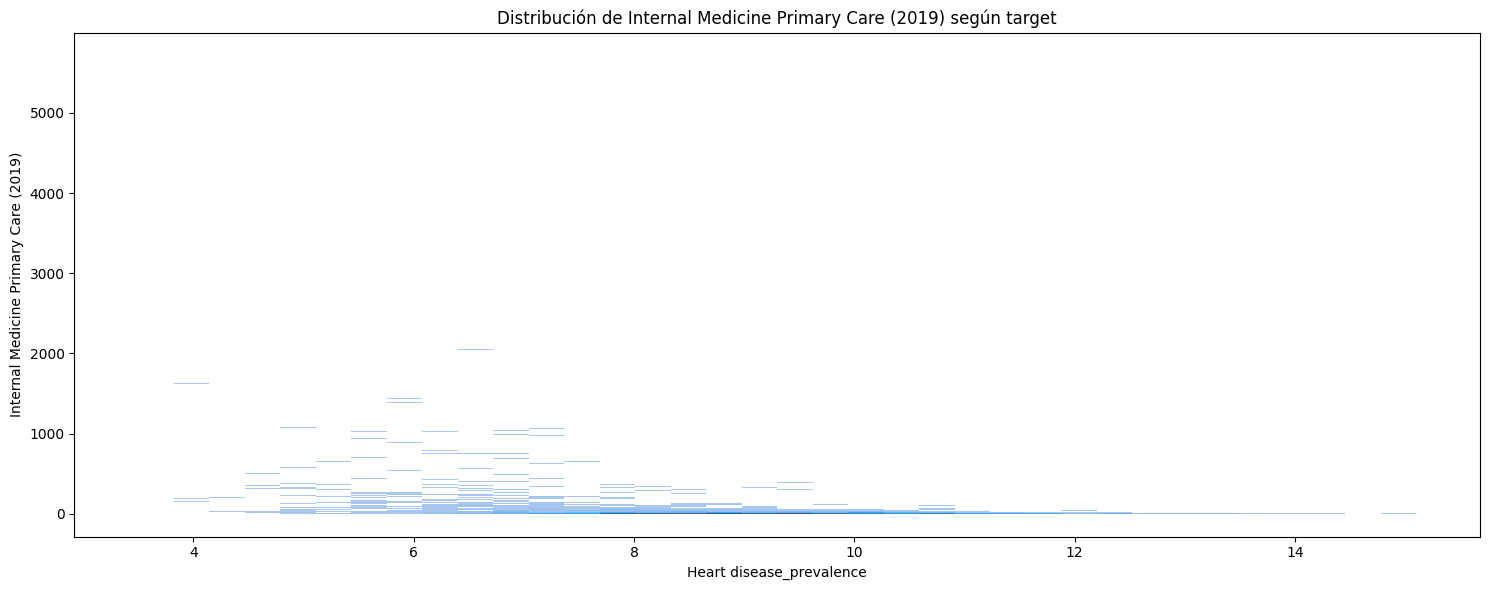

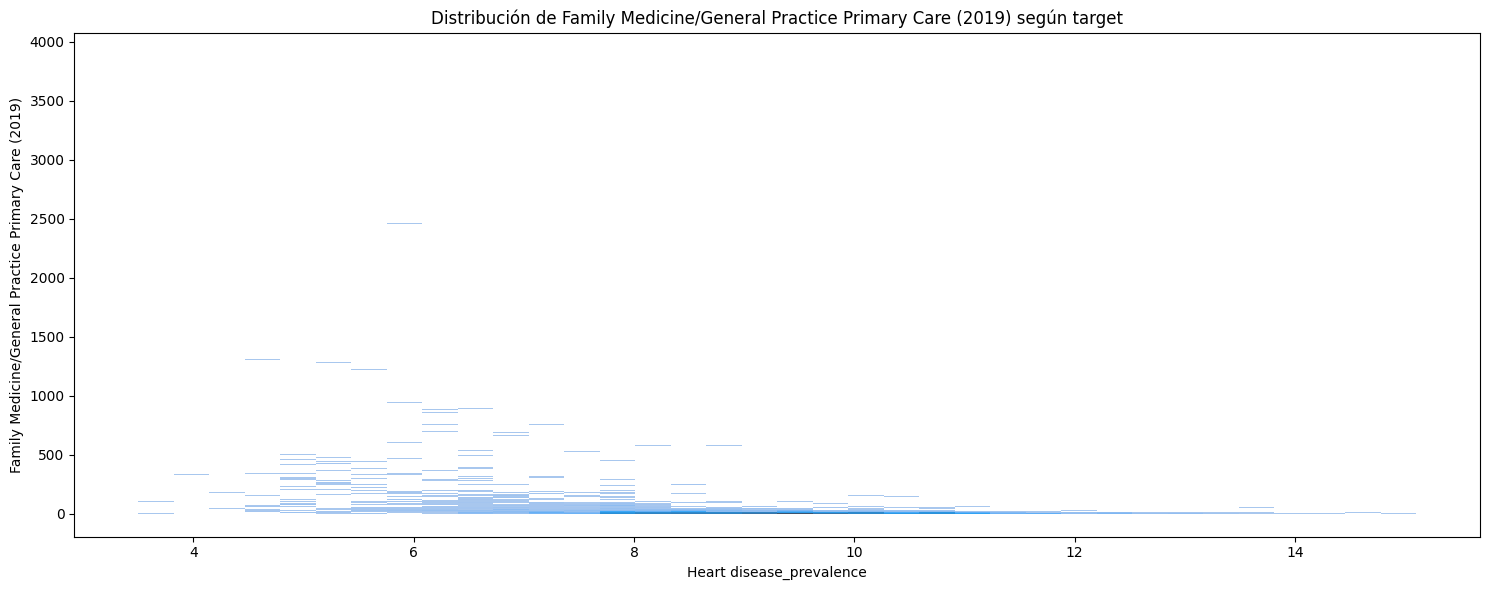

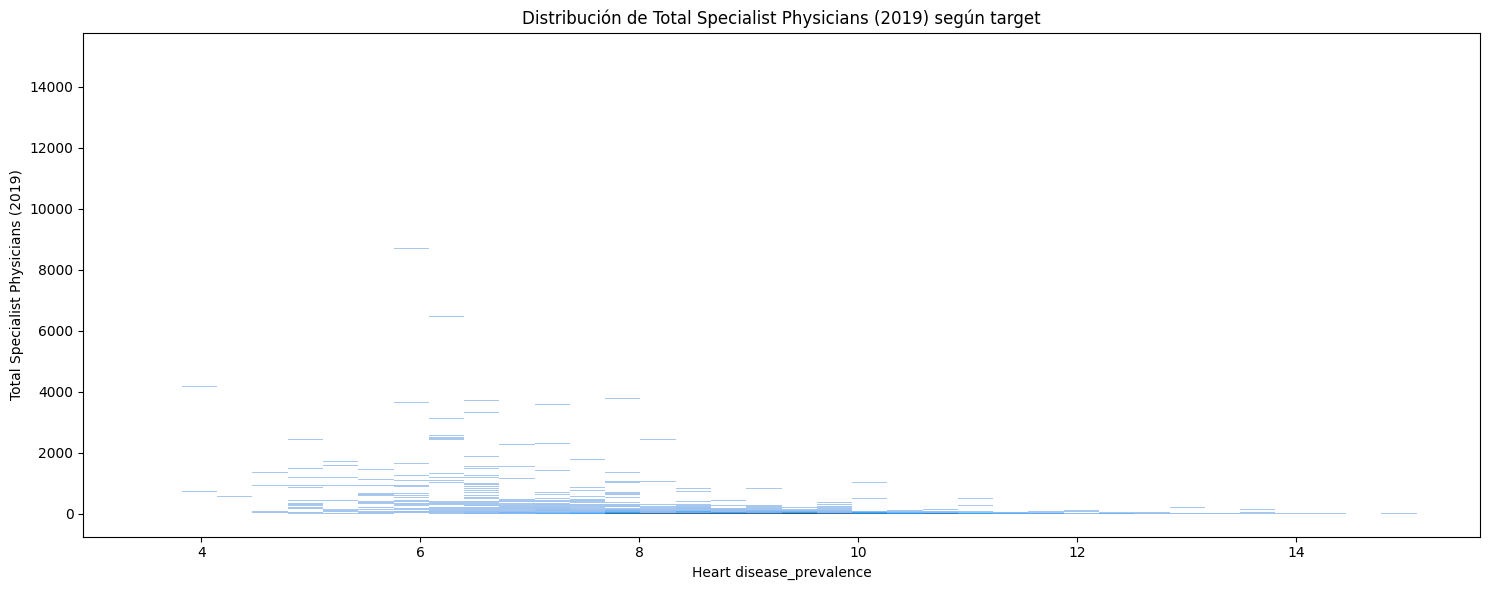

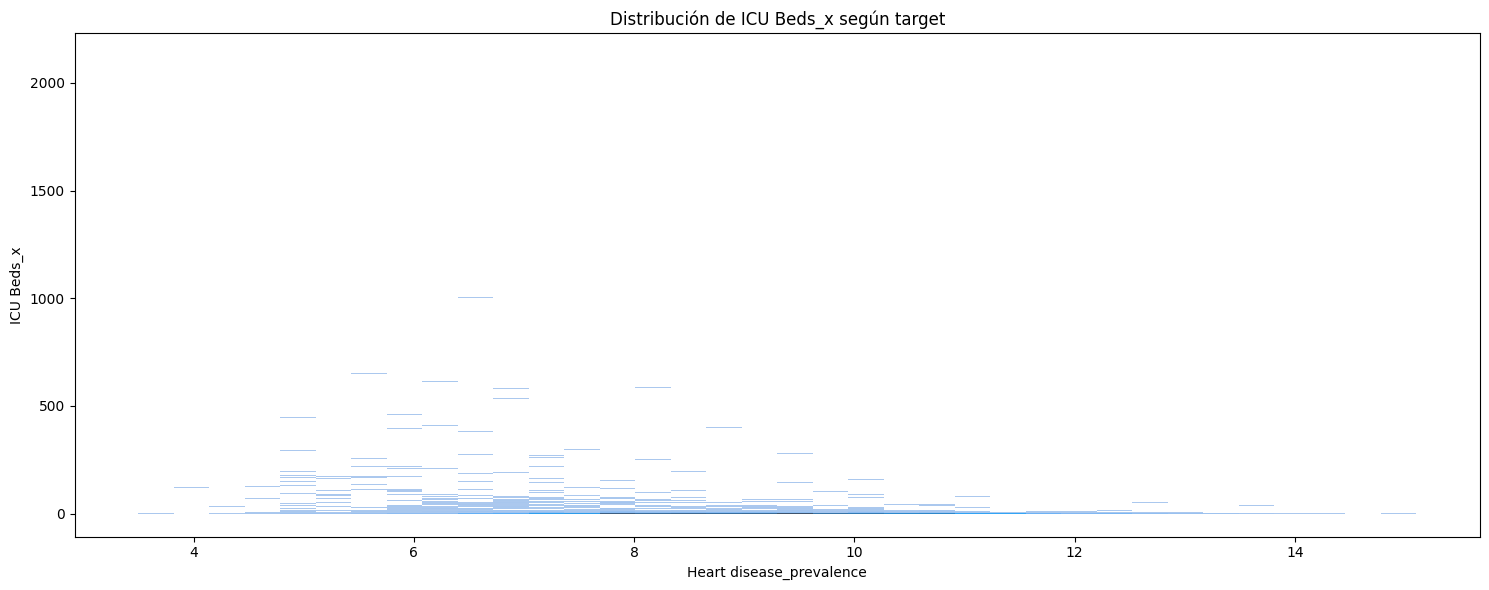

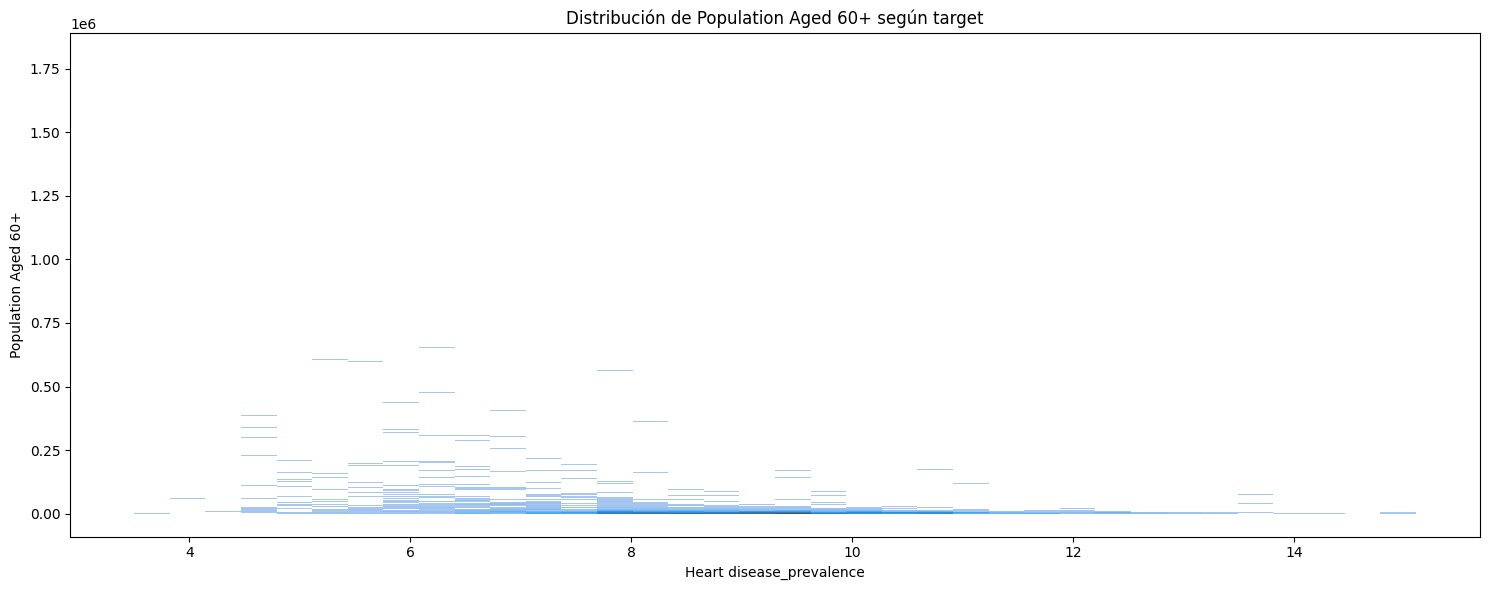

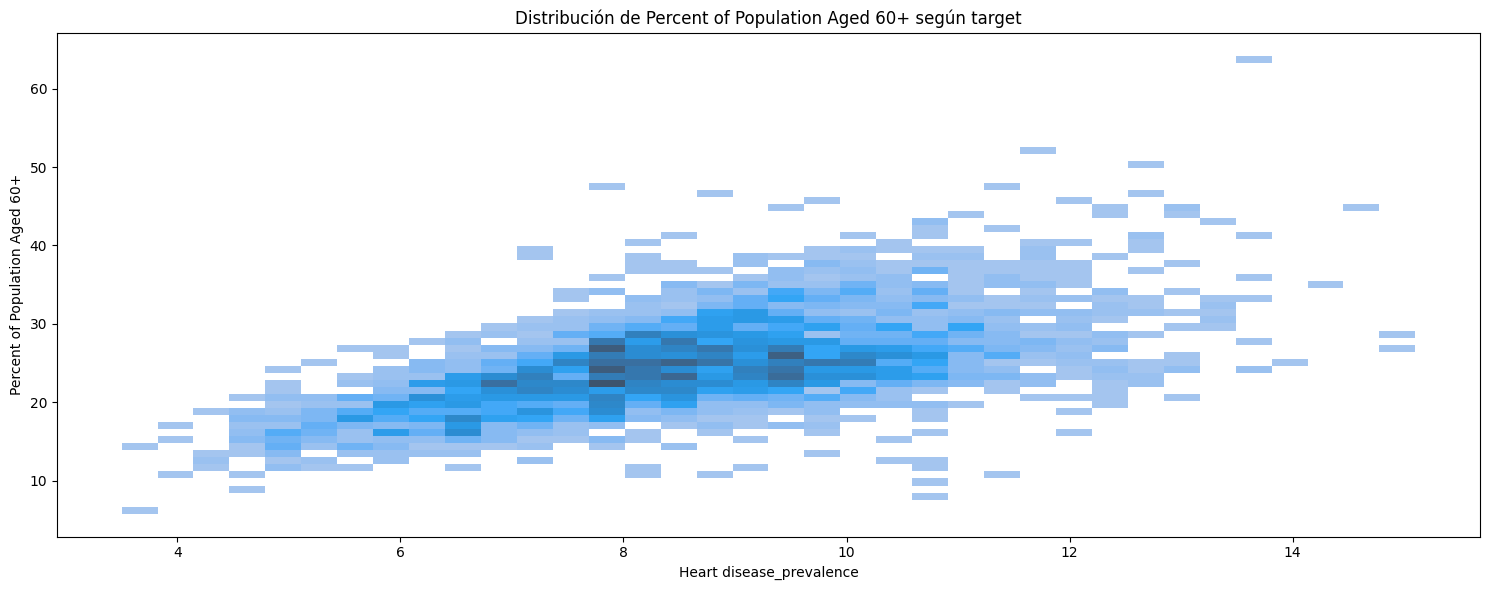

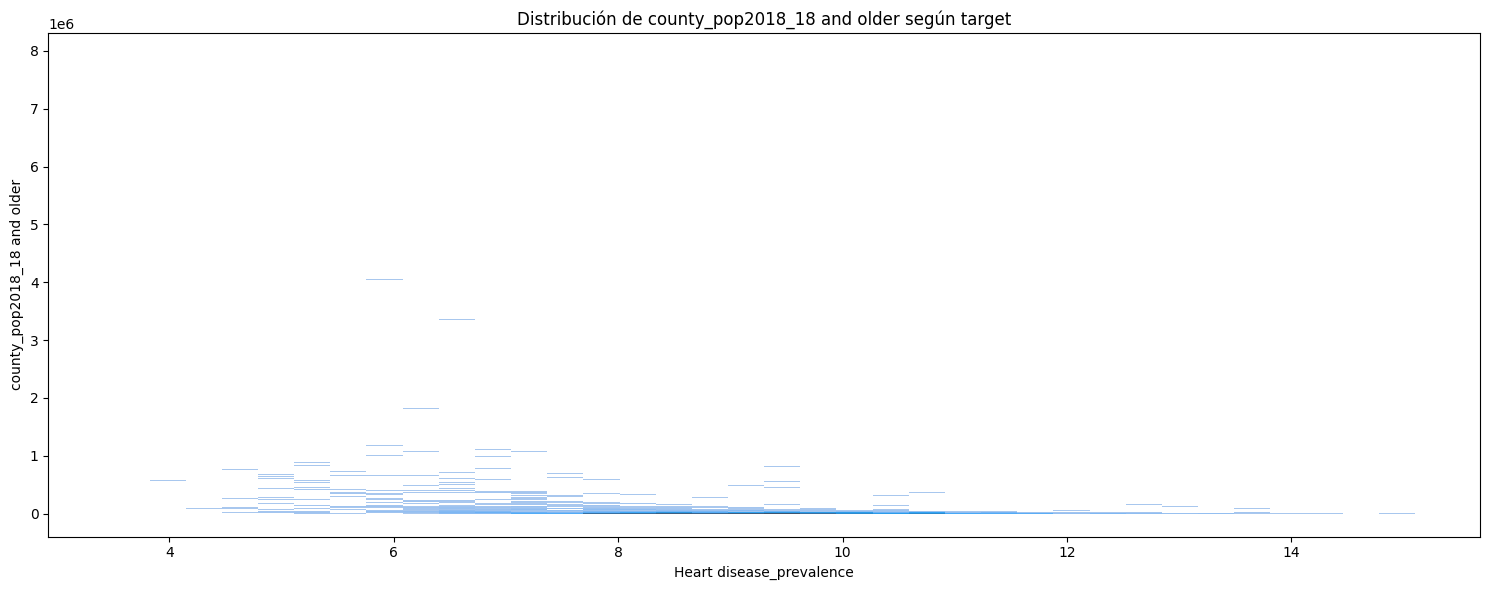

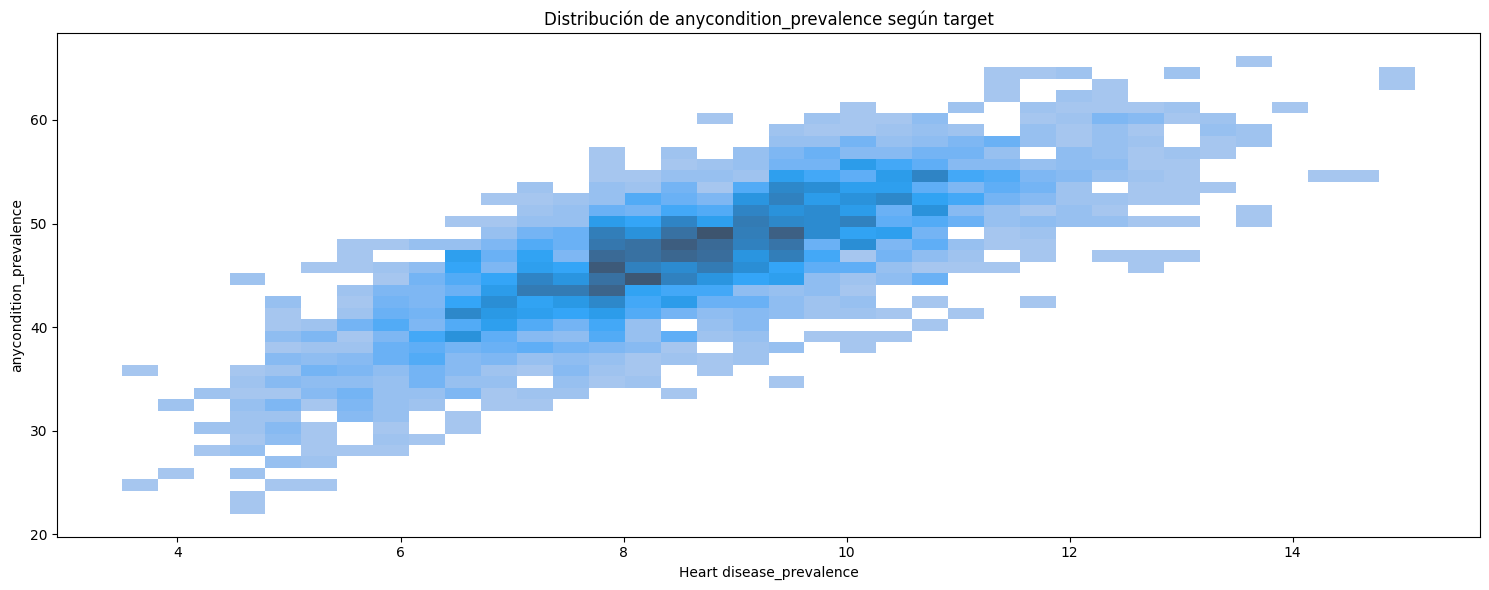

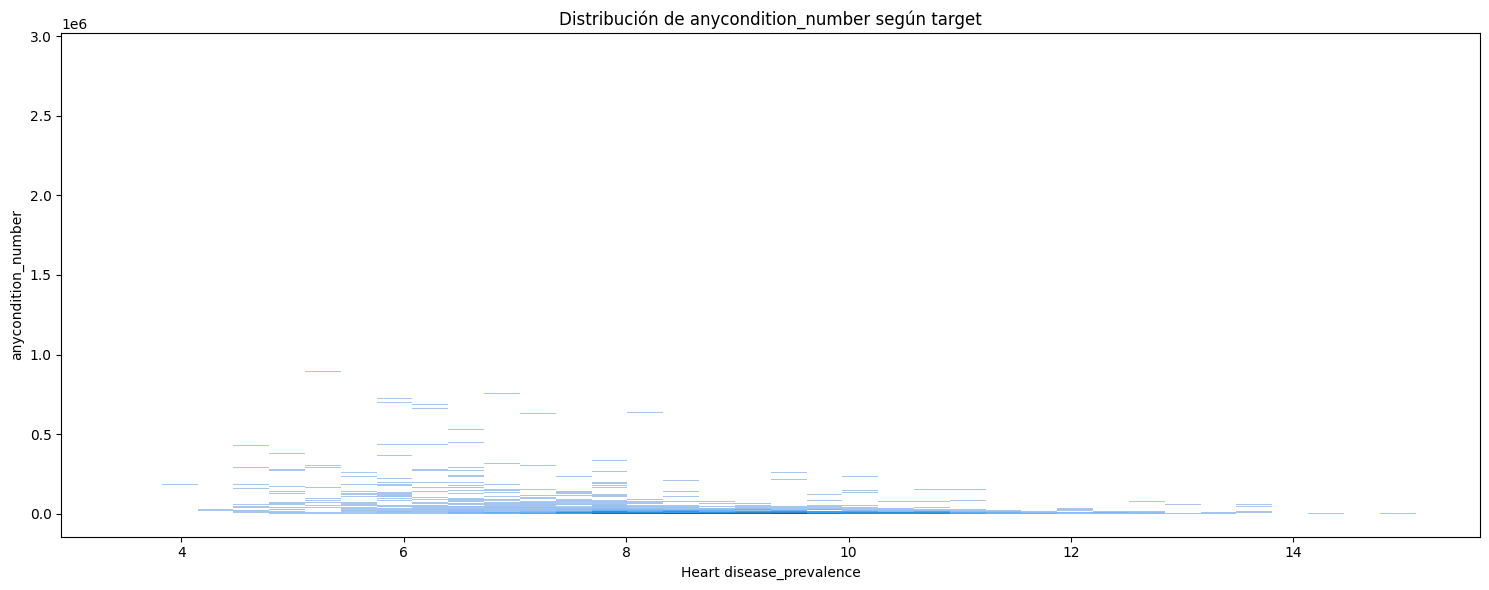

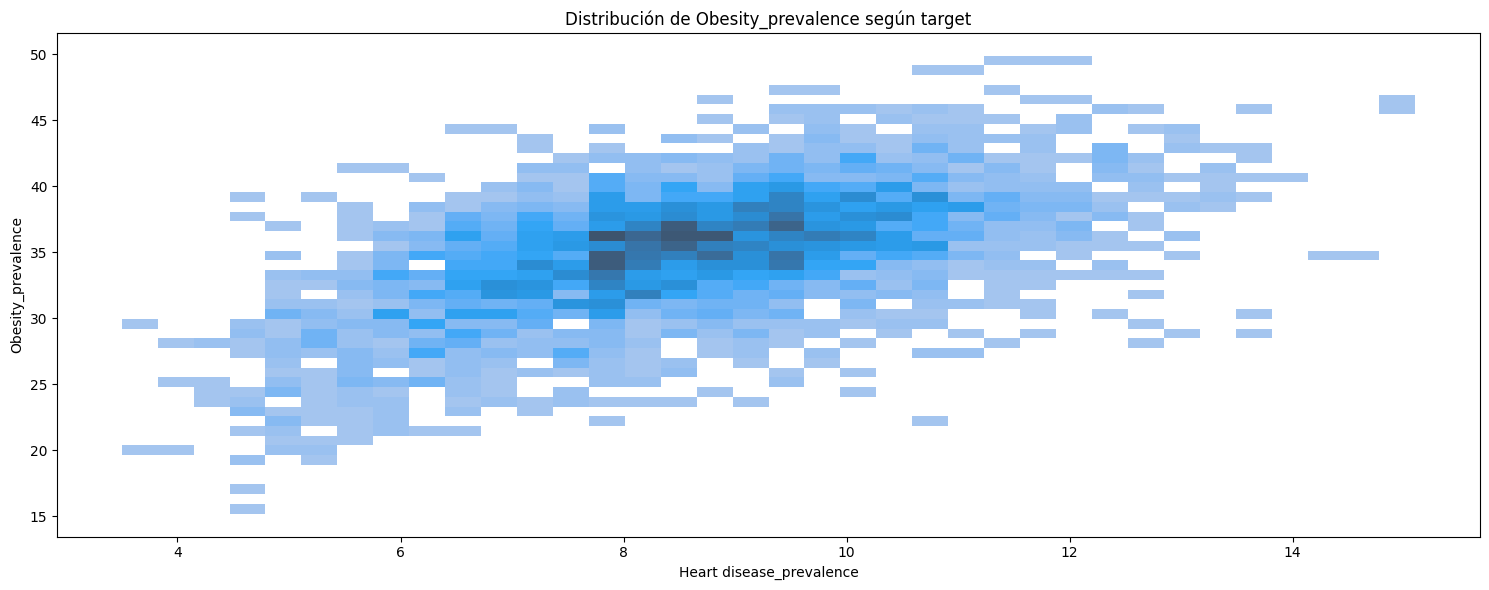

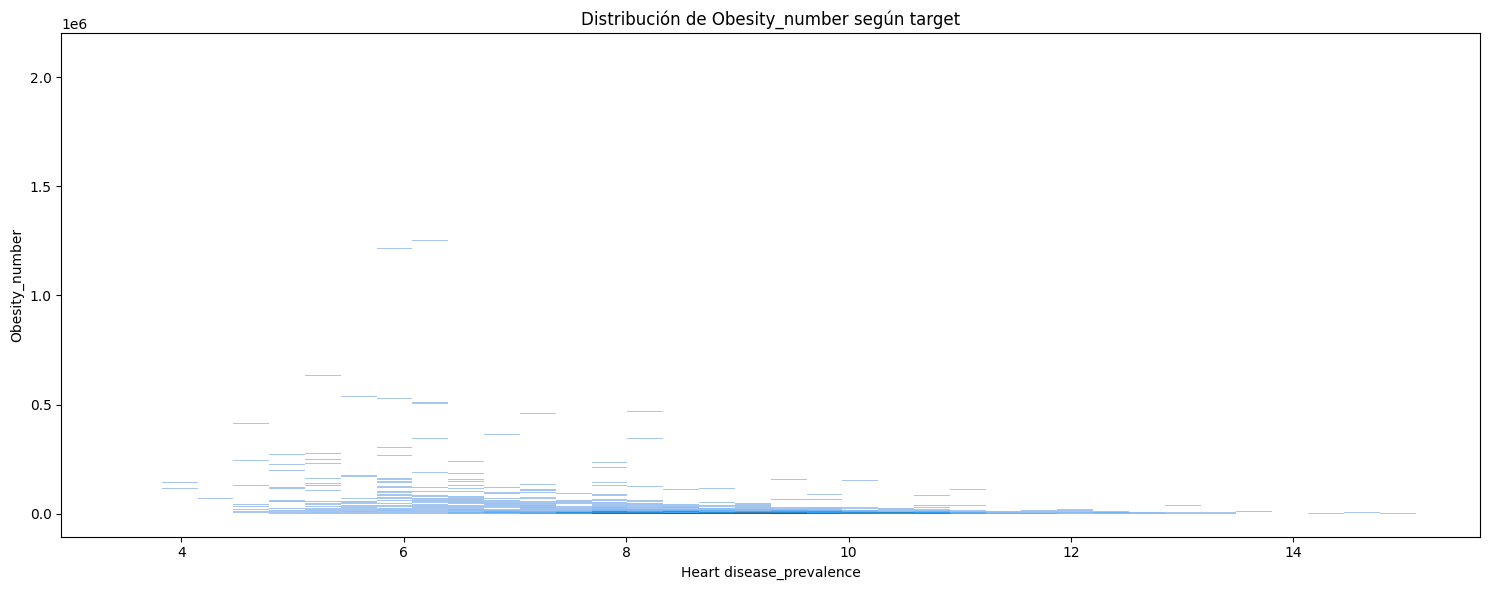

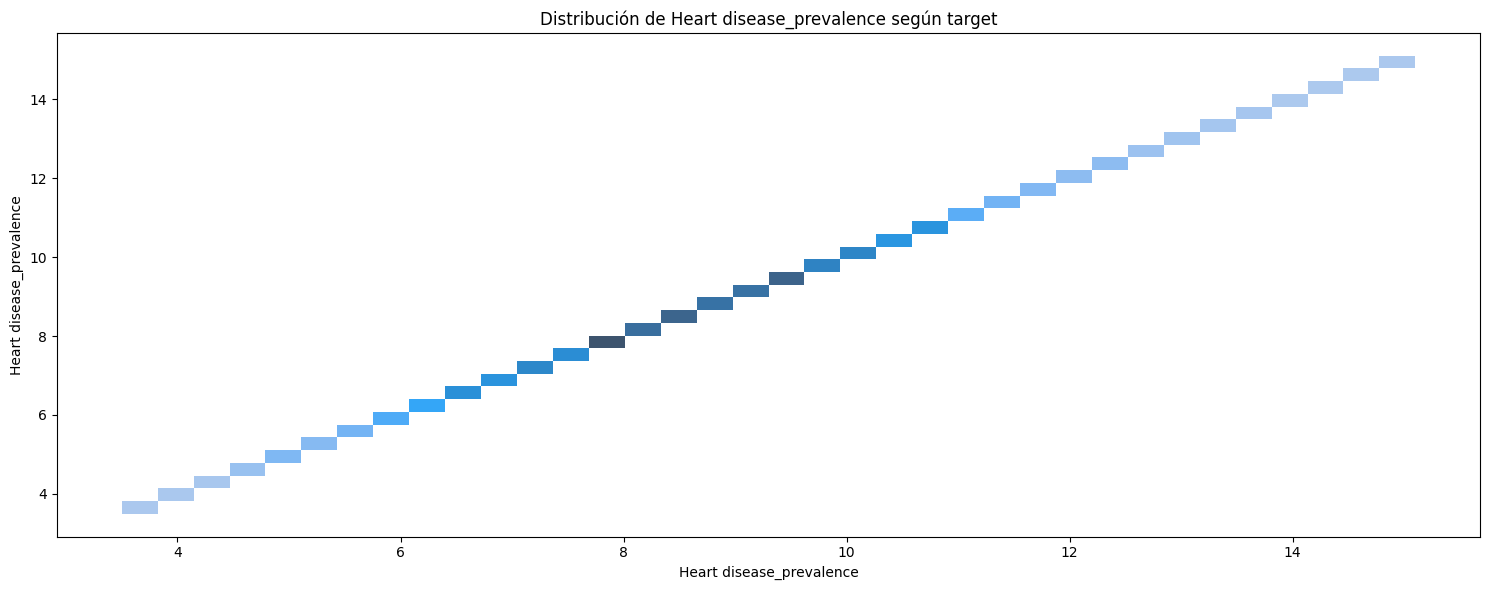

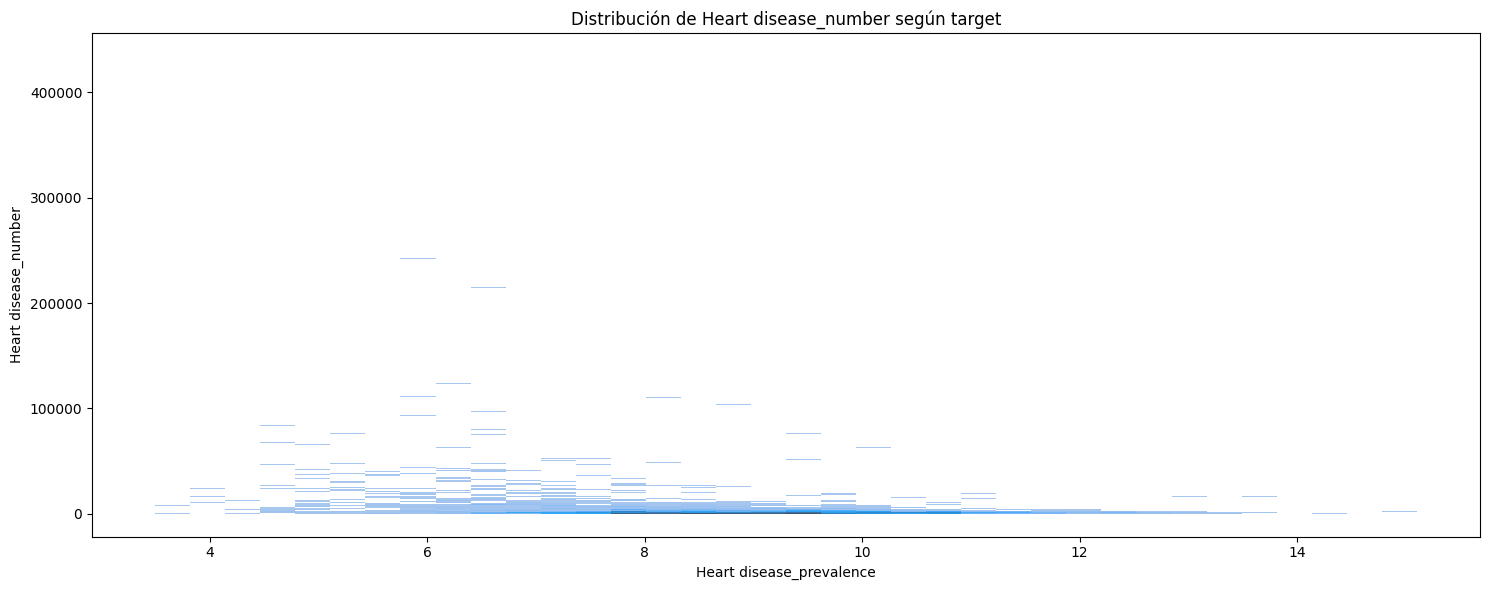

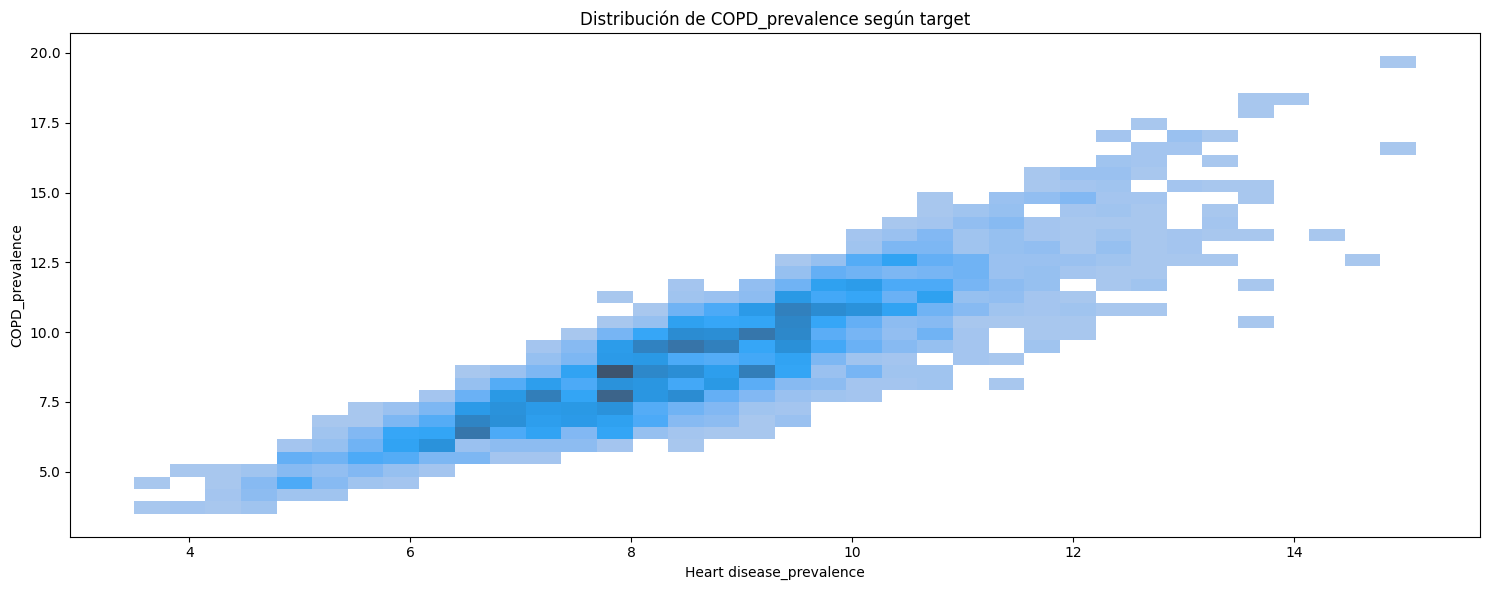

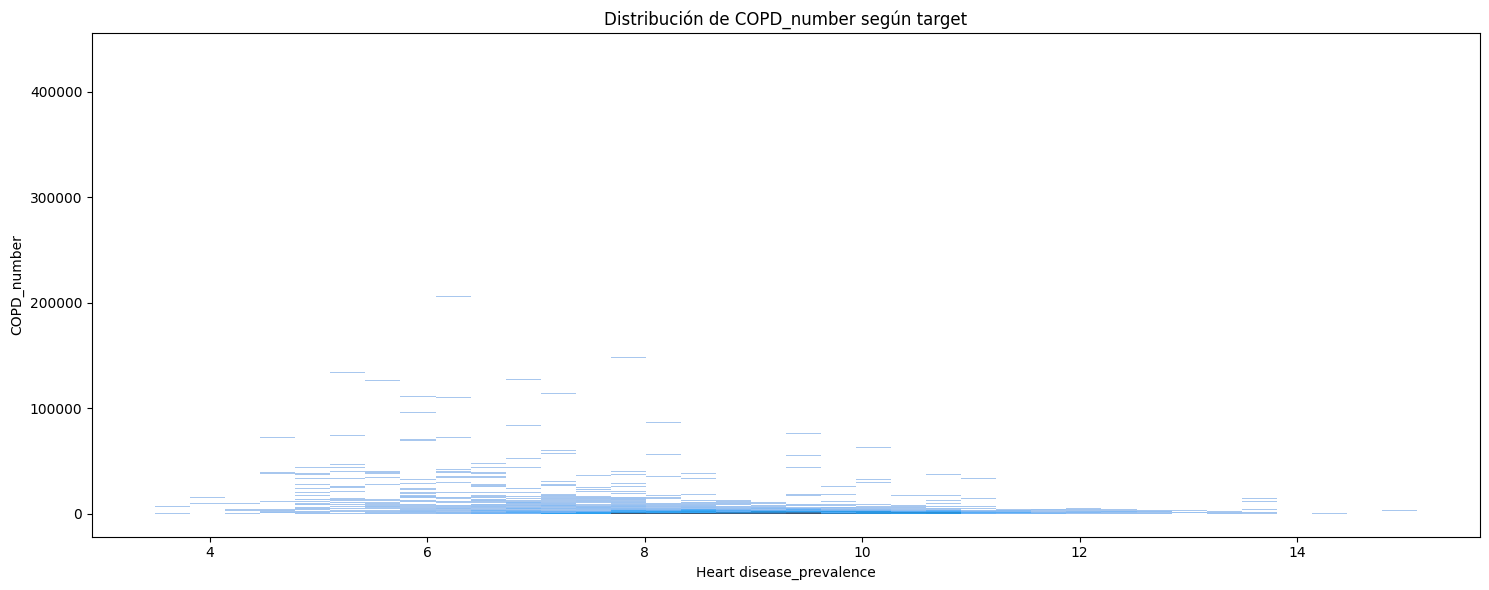

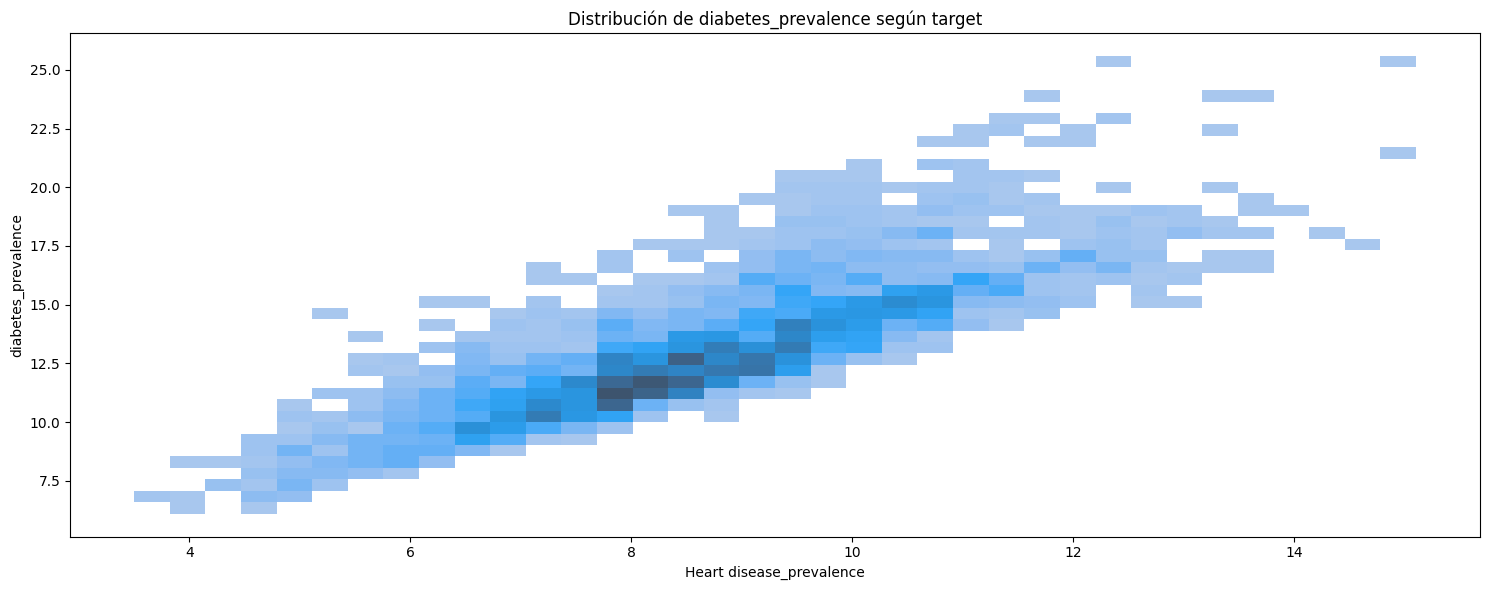

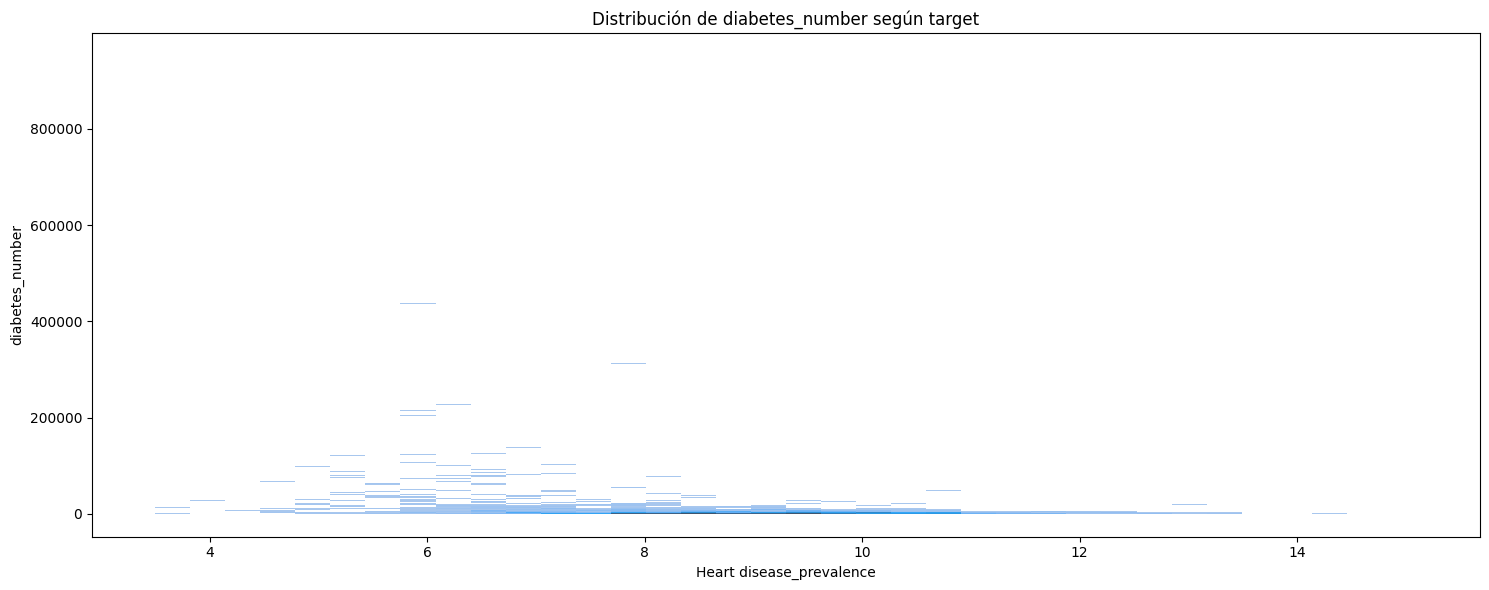

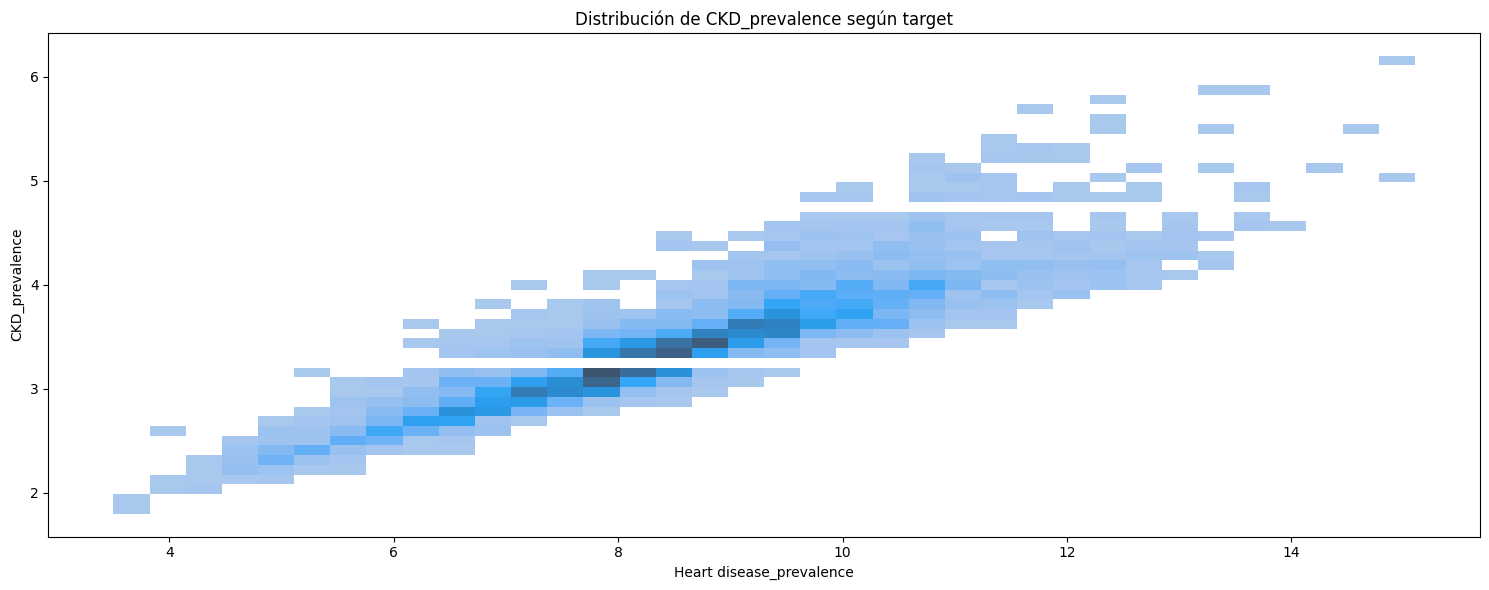

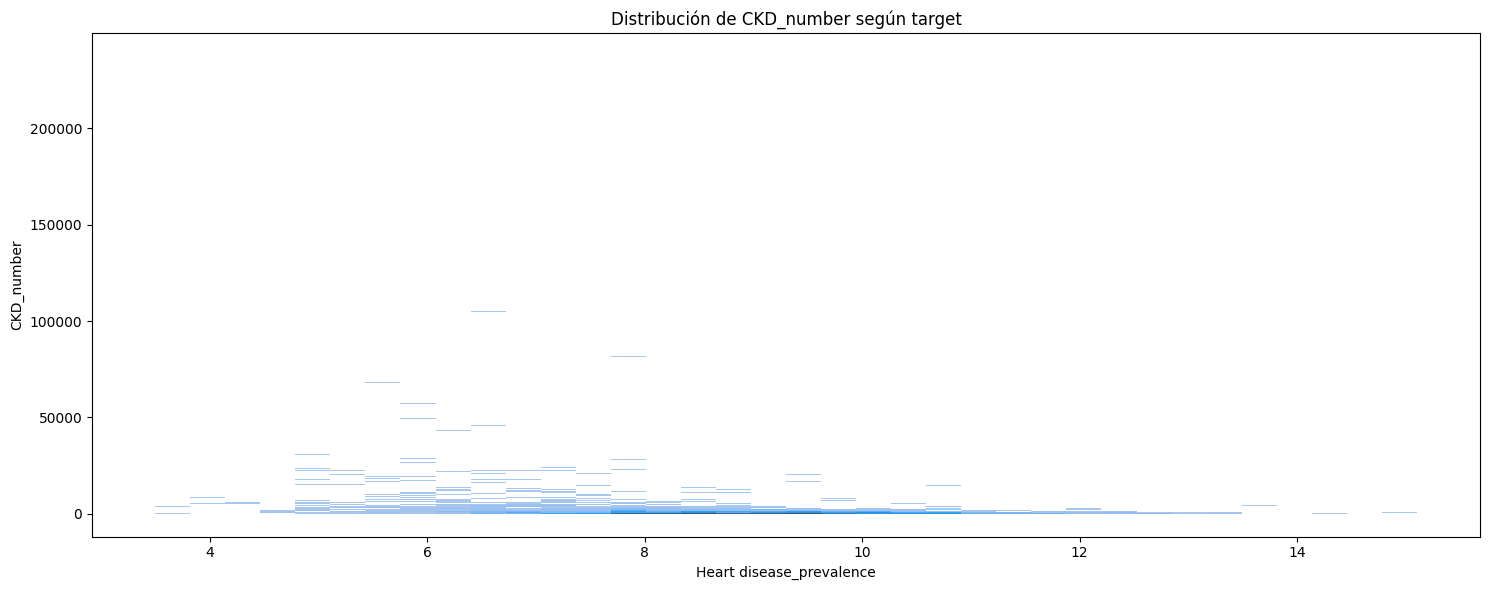

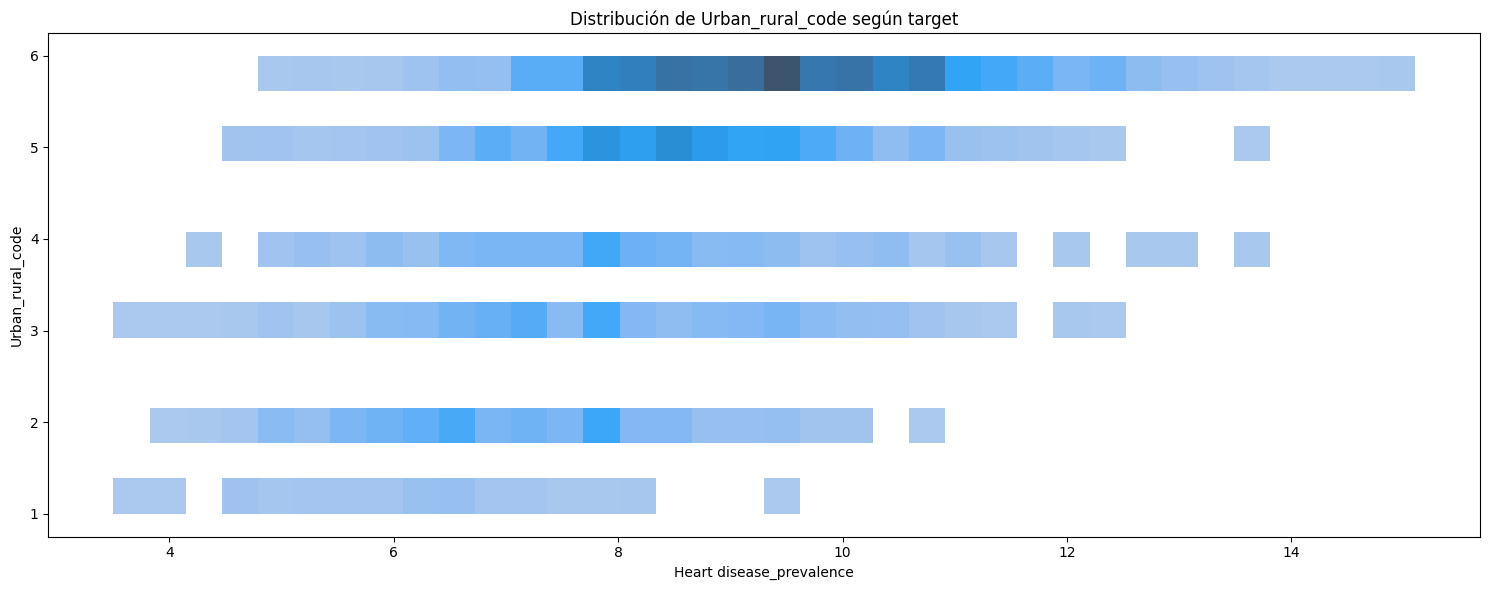

In [ ]:
for columna in df:
    plt.figure(figsize=(15,6))
    sns.histplot(data=df, x="Heart disease_prevalence", y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

### **ANÁLISIS MULTIVARIANTE**

##### Vars Numéricas

* Ages:

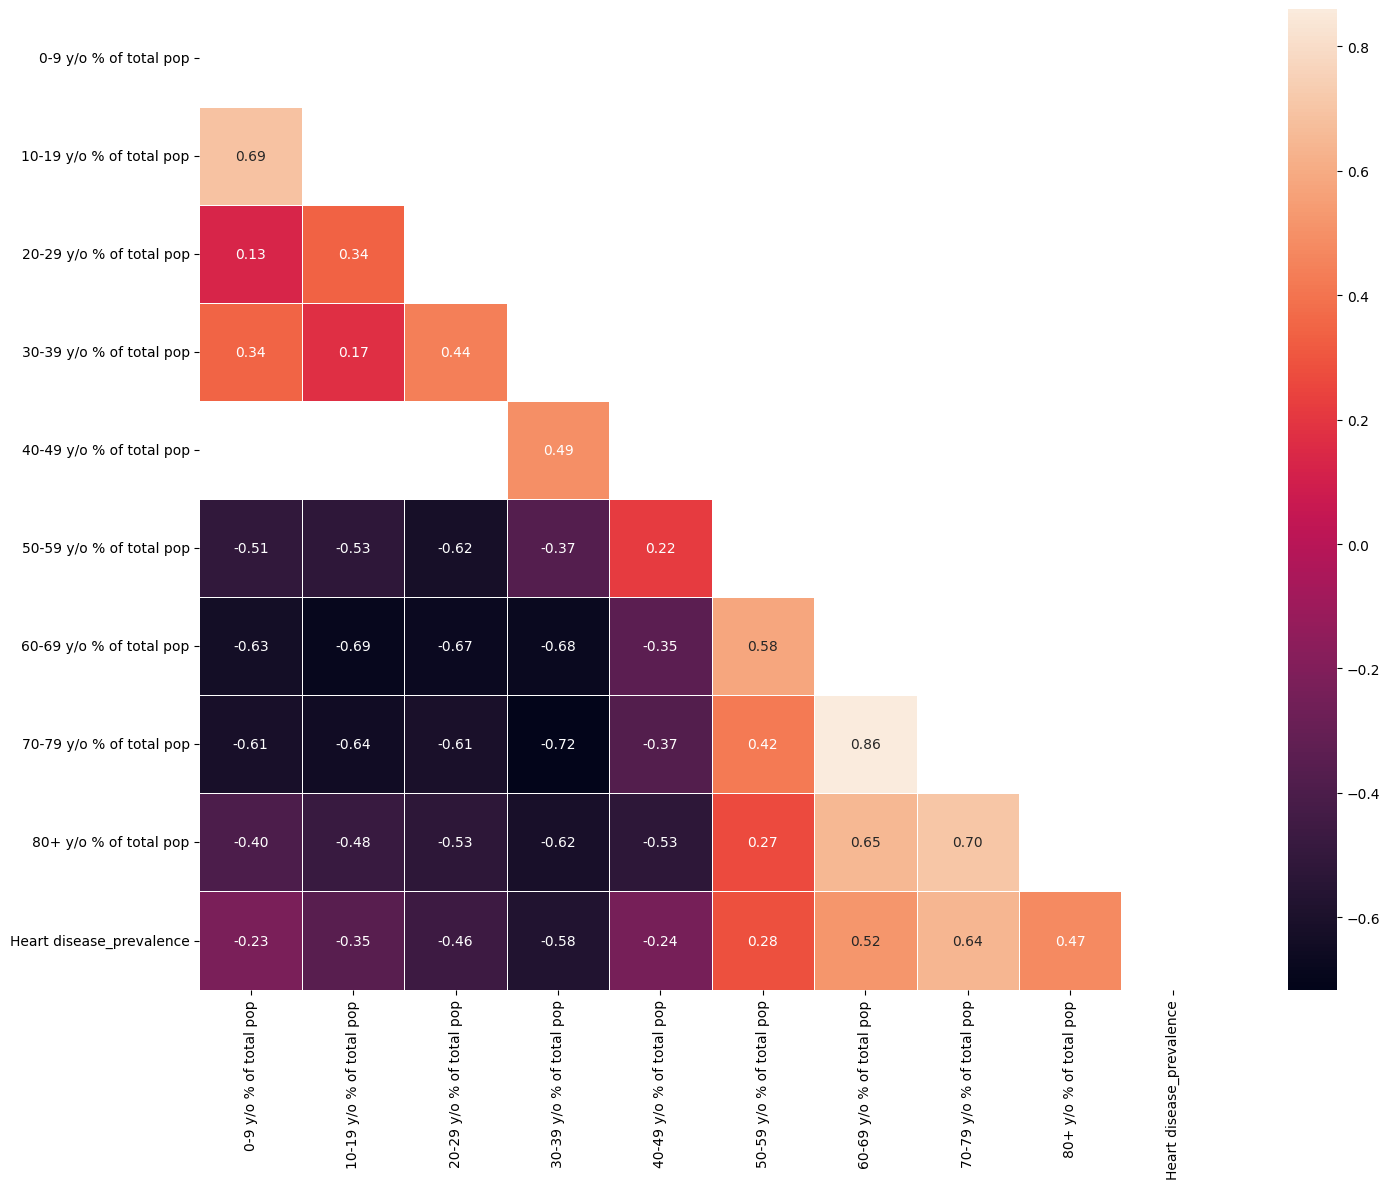

In [ ]:
age_col = ["0-9 y/o % of total pop", "10-19 y/o % of total pop", "20-29 y/o % of total pop", 
       "30-39 y/o % of total pop", "40-49 y/o % of total pop",
       "50-59 y/o % of total pop", "60-69 y/o % of total pop", 
       "70-79 y/o % of total pop", "80+ y/o % of total pop", 
       "Heart disease_prevalence"]

# heatmap
corr = df[age_col].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()




In [ ]:
# Combine age groups into broader categories 
df["age 0-19 pct %"] = df["0-9 y/o % of total pop"] + df["10-19 y/o % of total pop"]
df["age 20-39 pct %"] = df["20-29 y/o % of total pop"] + df["30-39 y/o % of total pop"]
df["age 40-59 pct %"] = df["40-49 y/o % of total pop"] + df["50-59 y/o % of total pop"]
df["age 60-79 pct %"] = df["60-69 y/o % of total pop"] + df["70-79 y/o % of total pop"]
df["age 80+ pct %"] = df["80+ y/o % of total pop"]



In [ ]:
age_columns_to_drop = ["0-9 y/o % of total pop", "10-19 y/o % of total pop", "20-29 y/o % of total pop", "30-39 y/o % of total pop", "40-49 y/o % of total pop",
                       "50-59 y/o % of total pop", "60-69 y/o % of total pop", "70-79 y/o % of total pop", "80+ y/o % of total pop"]

df = df.drop(age_columns_to_drop, axis = 1)

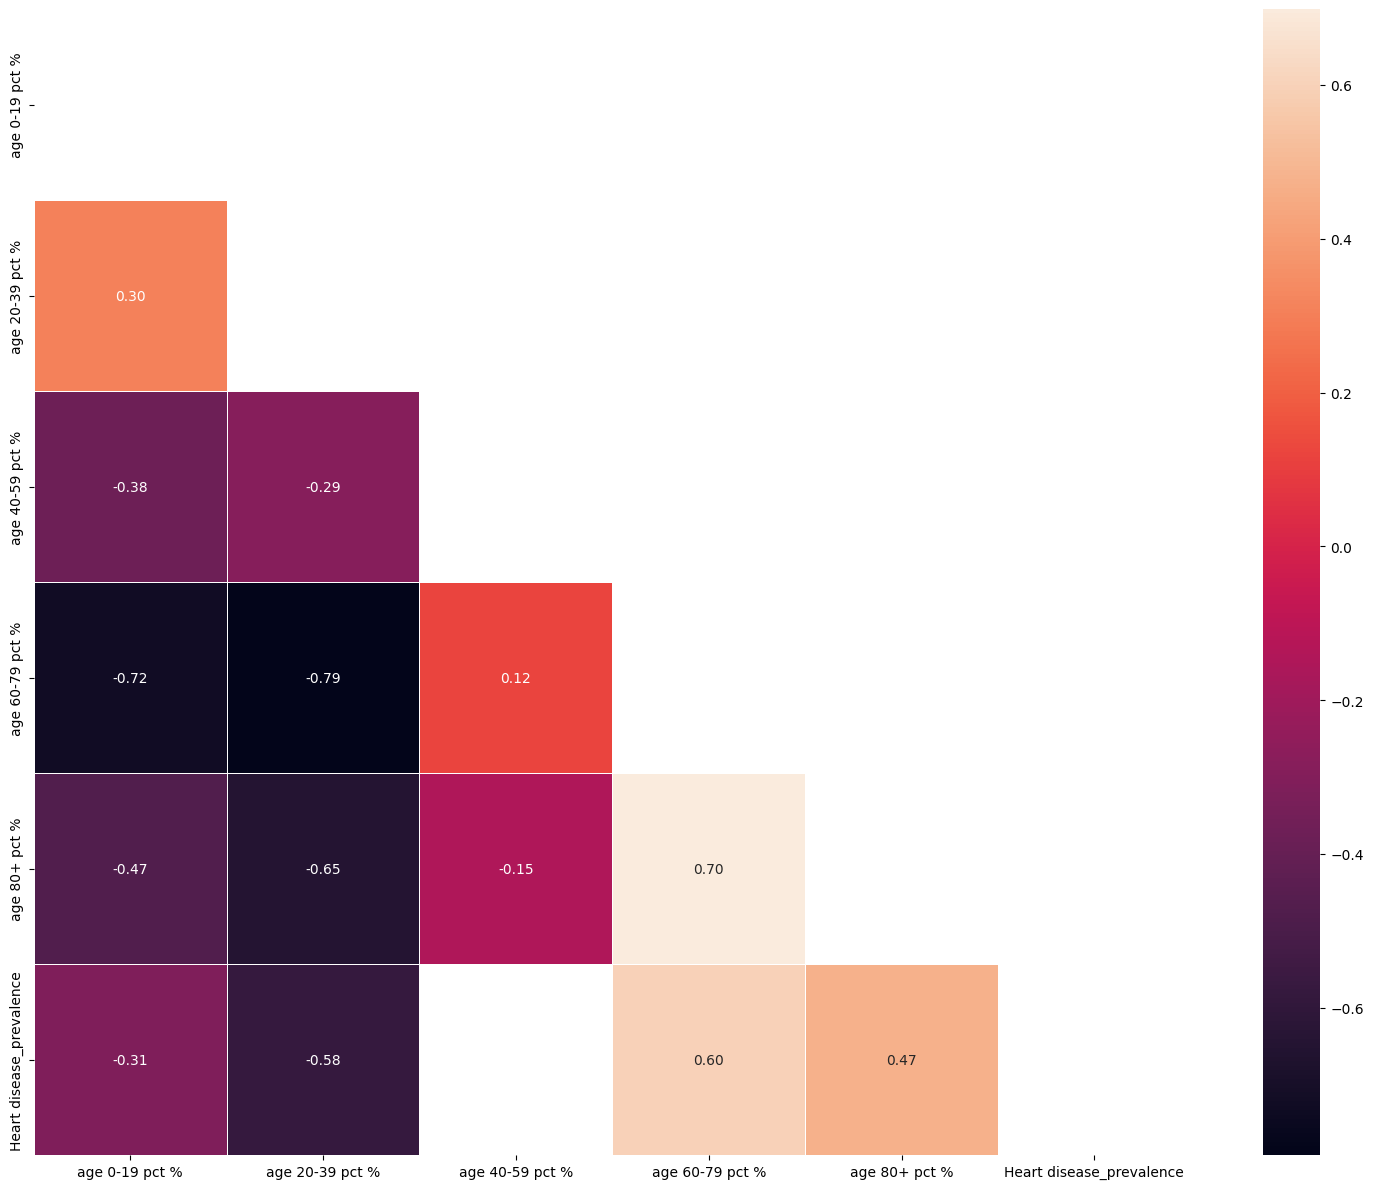

In [ ]:
age_col_two = ["age 0-19 pct %", "age 20-39 pct %", "age 40-59 pct %", "age 60-79 pct %", "age 80+ pct %", "Heart disease_prevalence"]
# heatmap
corr = df[age_col_two].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**Observaciones y drops**:

* Races:

In [ ]:
races = ['% White-alone', '% Black-alone', '% NA/AI-alone',
       '% Asian-alone', '% Hawaiian/PI-alone', '% Two or more races']


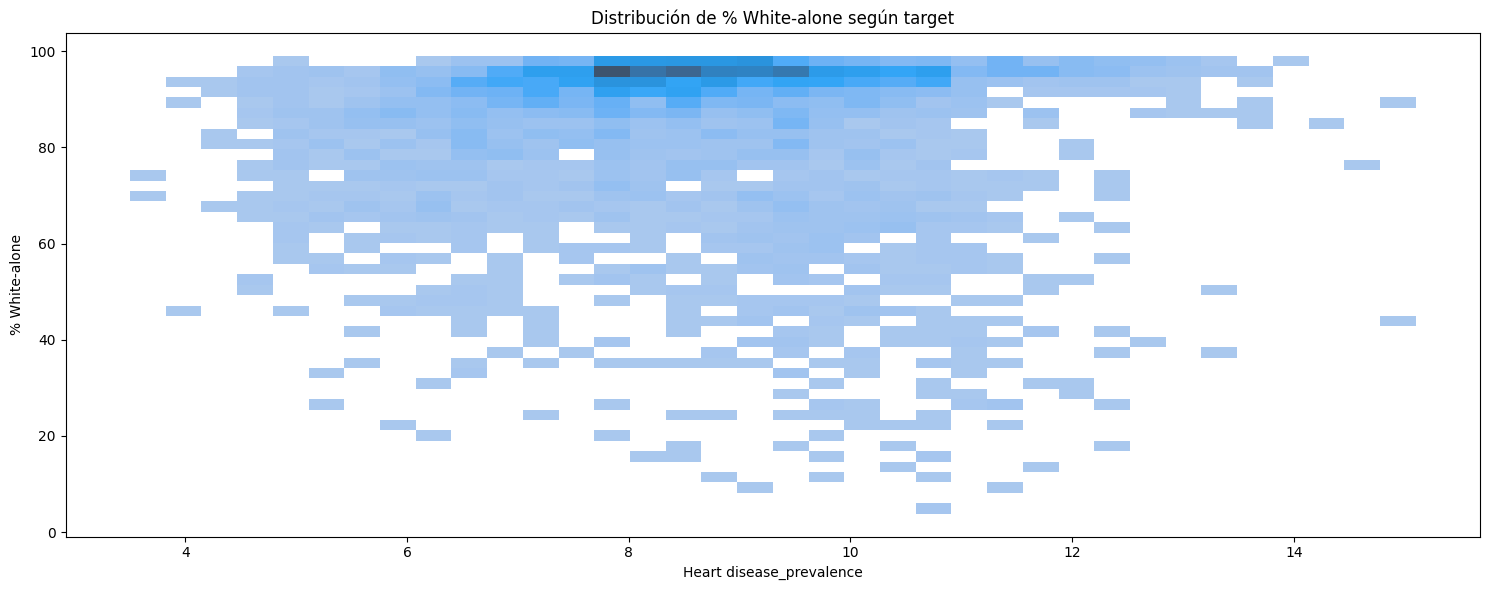

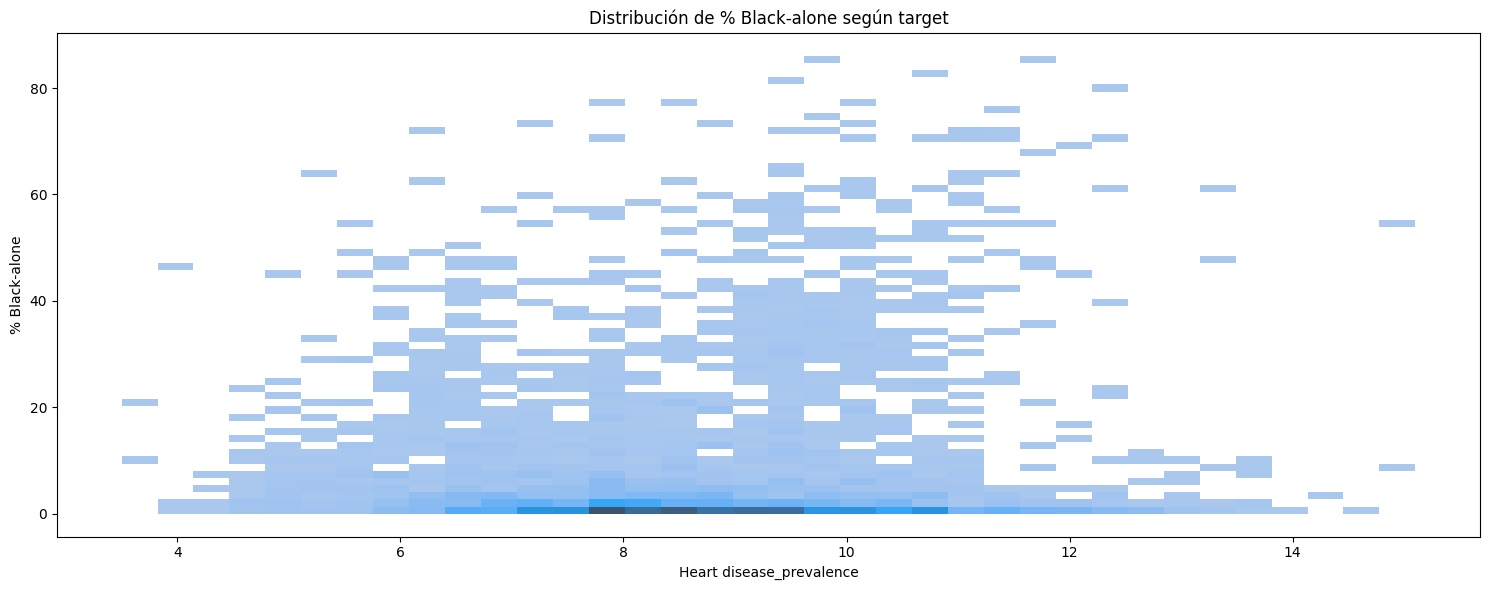

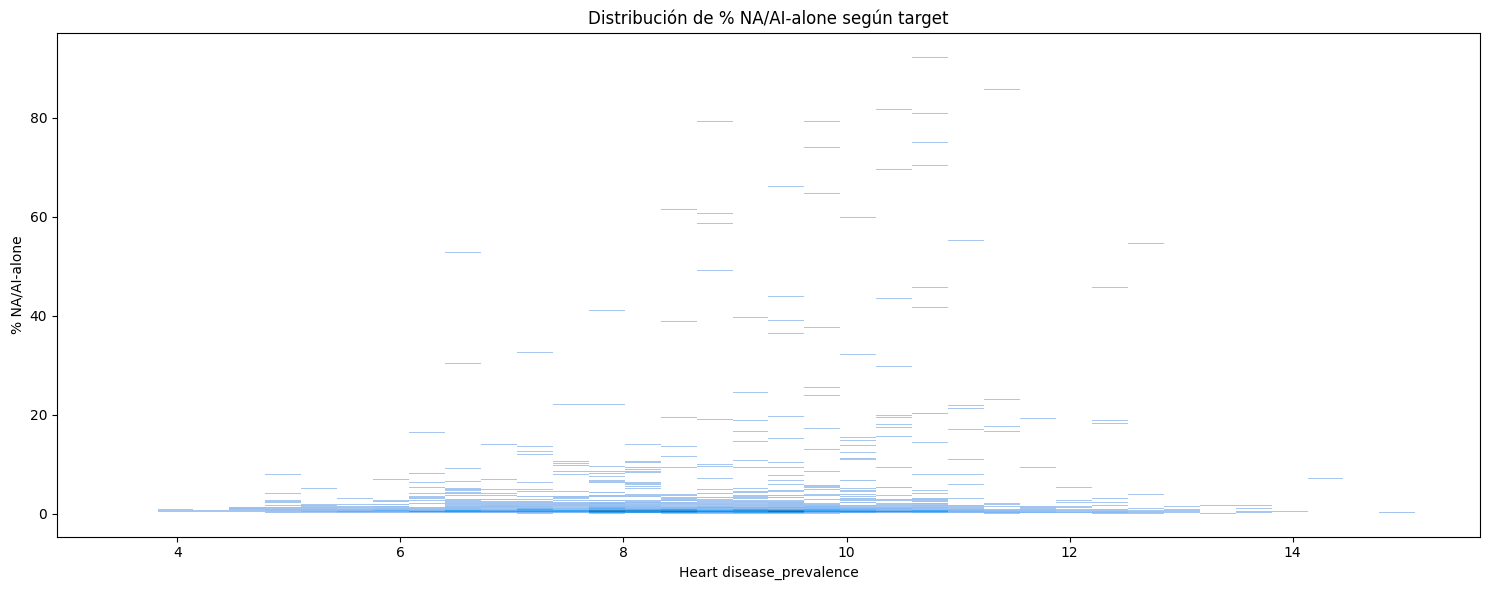

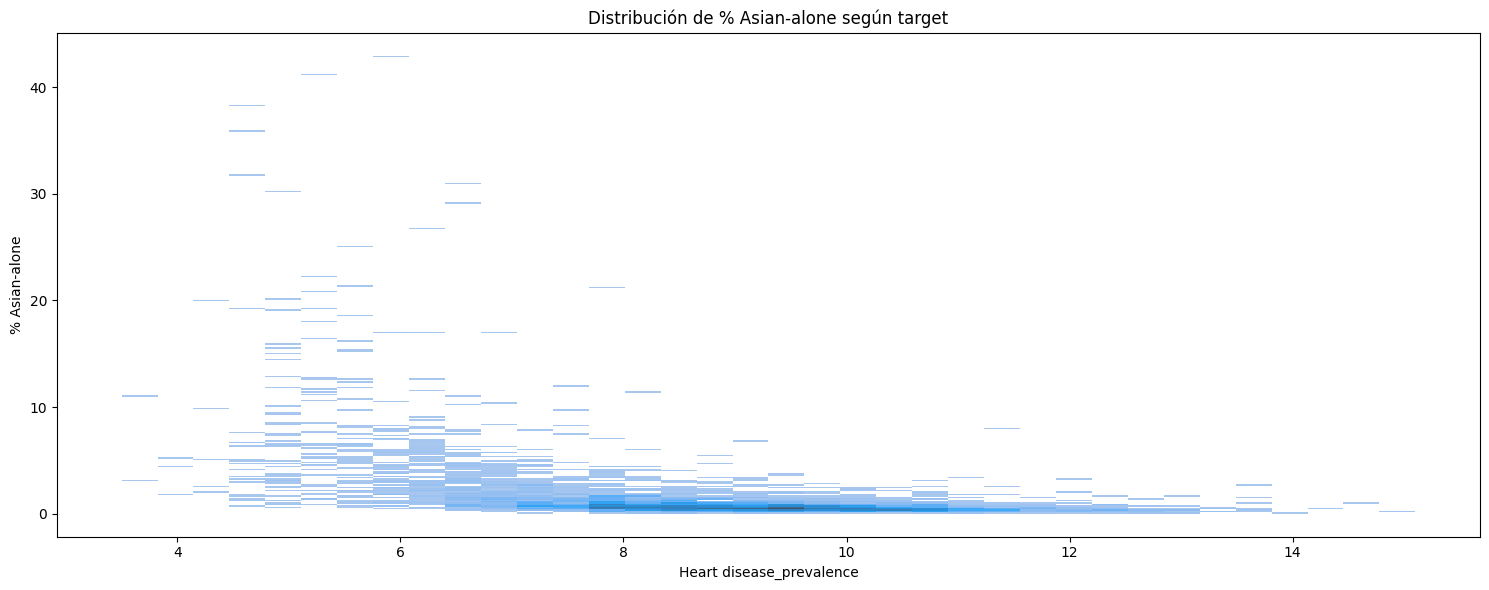

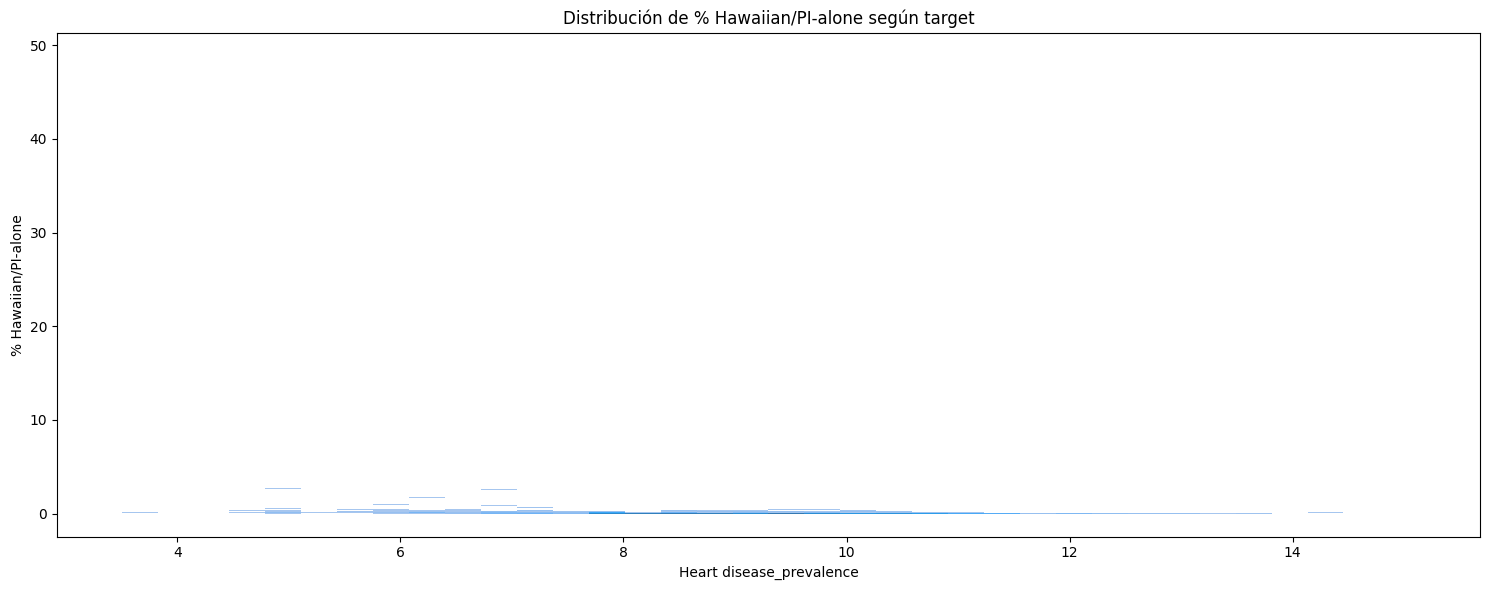

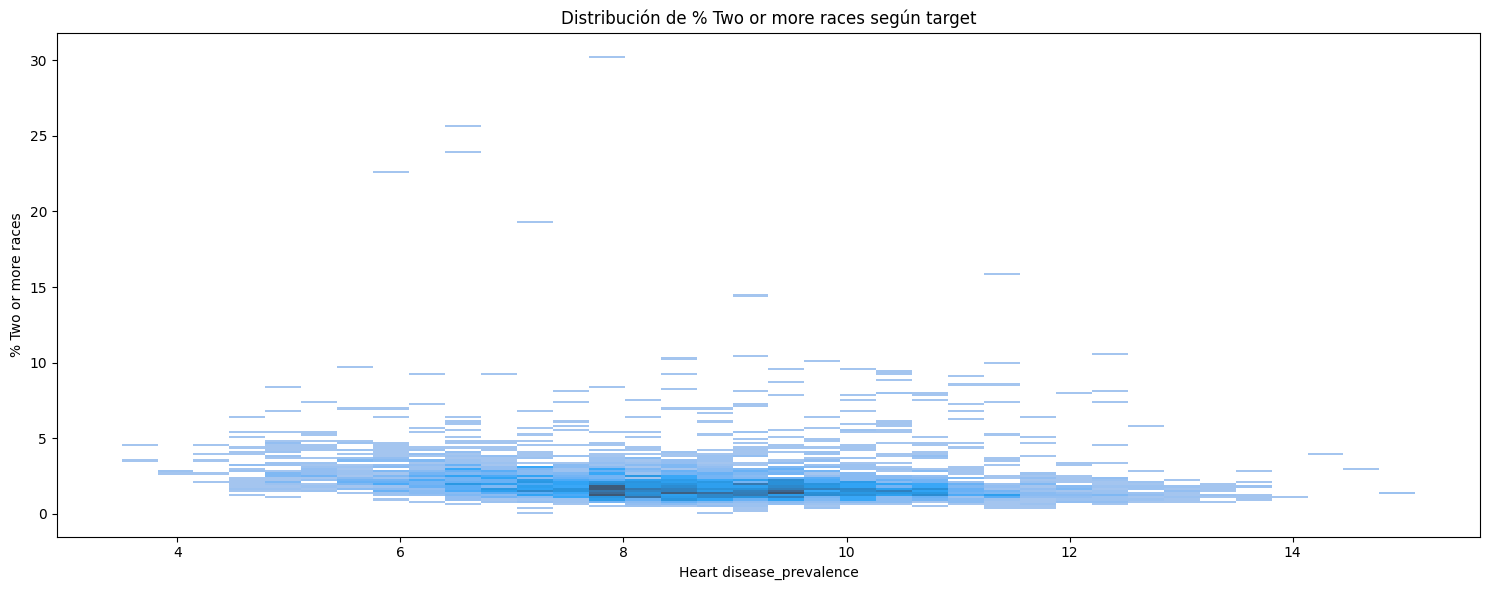

In [ ]:
for columna in races:
    plt.figure(figsize=(15,6))
    sns.histplot(data=df, x="Heart disease_prevalence", y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

**Observaciones y drops**:
No veo necesario eliminar ninguna columna de este grupo ya que aportan información de la población y necesitamosesa infromación.

* Education

In [ ]:
education = ["Less than a high school diploma 2014-18", "High school diploma only 2014-18", "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18"]


**Observaciones y drops**:

In [ ]:
df.columns


Index(['fips', '% White-alone', '% Black-alone', '% NA/AI-alone',
       '% Asian-alone', '% Hawaiian/PI-alone', '% Two or more races',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Civilian_labor_force_2018',
       'Unemployment_rate_2018', 'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active General Surgeons per 100000 Population 2018 (AAMC)',
       'Active Patient Care General Surgeons pe

* Location:


shdjvbkdsjhv

In [ ]:
df.drop(['fips'], axis=1, inplace=True) 

In [ ]:

others = ['Percent of Population Aged 60+',
       'county_pop2018_18 and older', 'anycondition_prevalence',
       'anycondition_number', 'Obesity_prevalence', 'Obesity_number', 'COPD_prevalence',
       'COPD_number', 'diabetes_prevalence', 'diabetes_number',
       'CKD_prevalence', 'CKD_number', 'age 0-19 pct %',
       'age 20-39 pct %', 'age 40-59 pct %', 'age 60-79 pct %',
       'age 80+ pct %', 'Heart disease_number', 'Heart disease_prevalence']

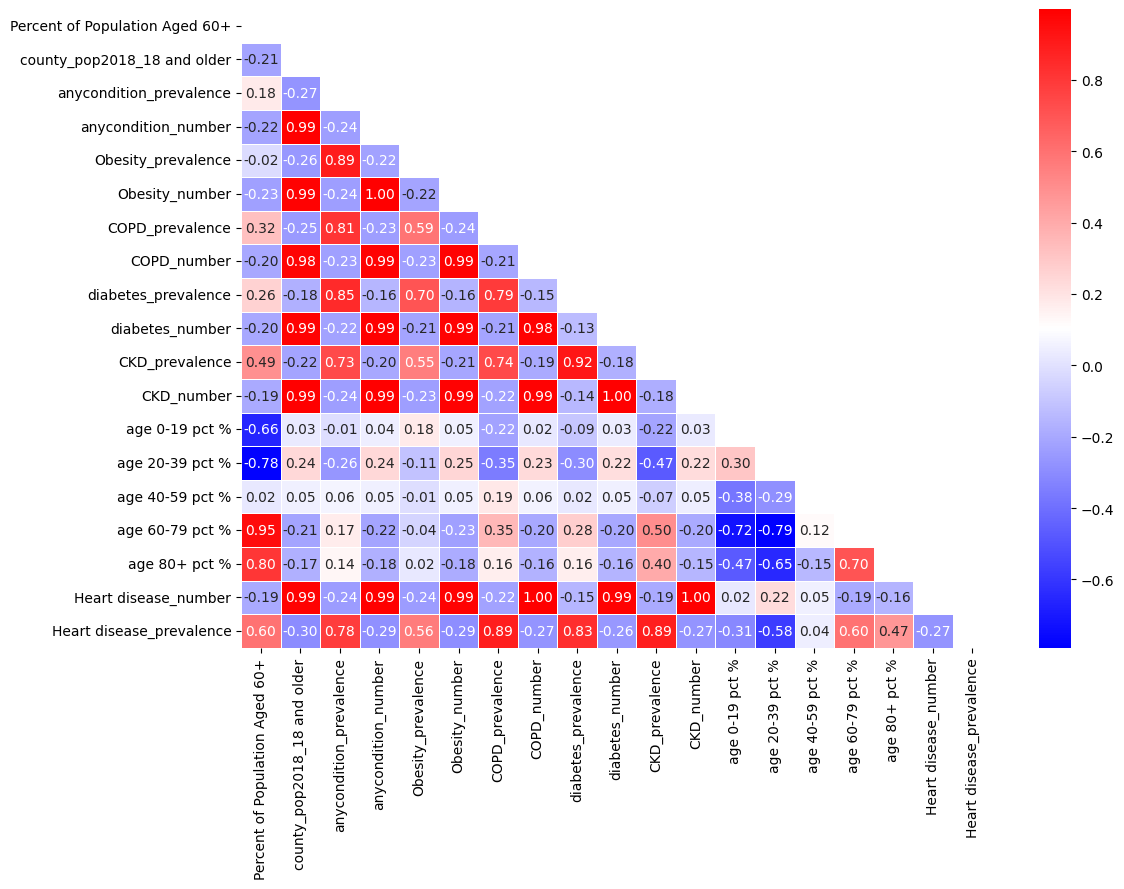

In [ ]:
corr = df[others].corr

corr = df[others].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='bwr')

plt.tight_layout()
plt.show()

In [ ]:
df.info

<bound method DataFrame.info of       % White-alone  % Black-alone  % NA/AI-alone  % Asian-alone  \
0         76.725239      19.630942       0.480207       1.224798   
1         87.285228       8.940382       0.772399       1.150343   
2         49.069571      48.398376       0.659137       0.454162   
3         76.834821      21.294643       0.437500       0.236607   
4         95.878285       1.642462       0.653527       0.319848   
...             ...            ...            ...            ...   
3135      93.835219       1.375113       1.544680       1.010429   
3136      95.190850       0.758199       0.914172       1.412417   
3137      95.354451       0.827627       1.418789       0.472930   
3138      94.483196       0.507292       1.813570       0.824350   
3139      93.081671       0.688962       1.765466       1.937706   

      % Hawaiian/PI-alone  % Two or more races  \
0                0.111509             1.827305   
1                0.066966             1.784682   
2

**Segundo heatmap de comparación en columnas finales**:

In [ ]:

others_filtered = ['Percent of Population Aged 60+',
       'county_pop2018_18 and older', 'anycondition_prevalence',
       'Obesity_prevalence', 'COPD_prevalence',
       'diabetes_prevalence', 
       'CKD_prevalence', 'age 0-19 pct %',
       'age 20-39 pct %', 'age 40-59 pct %', 'age 60-79 pct %',
       'age 80+ pct %', 'Heart disease_prevalence']

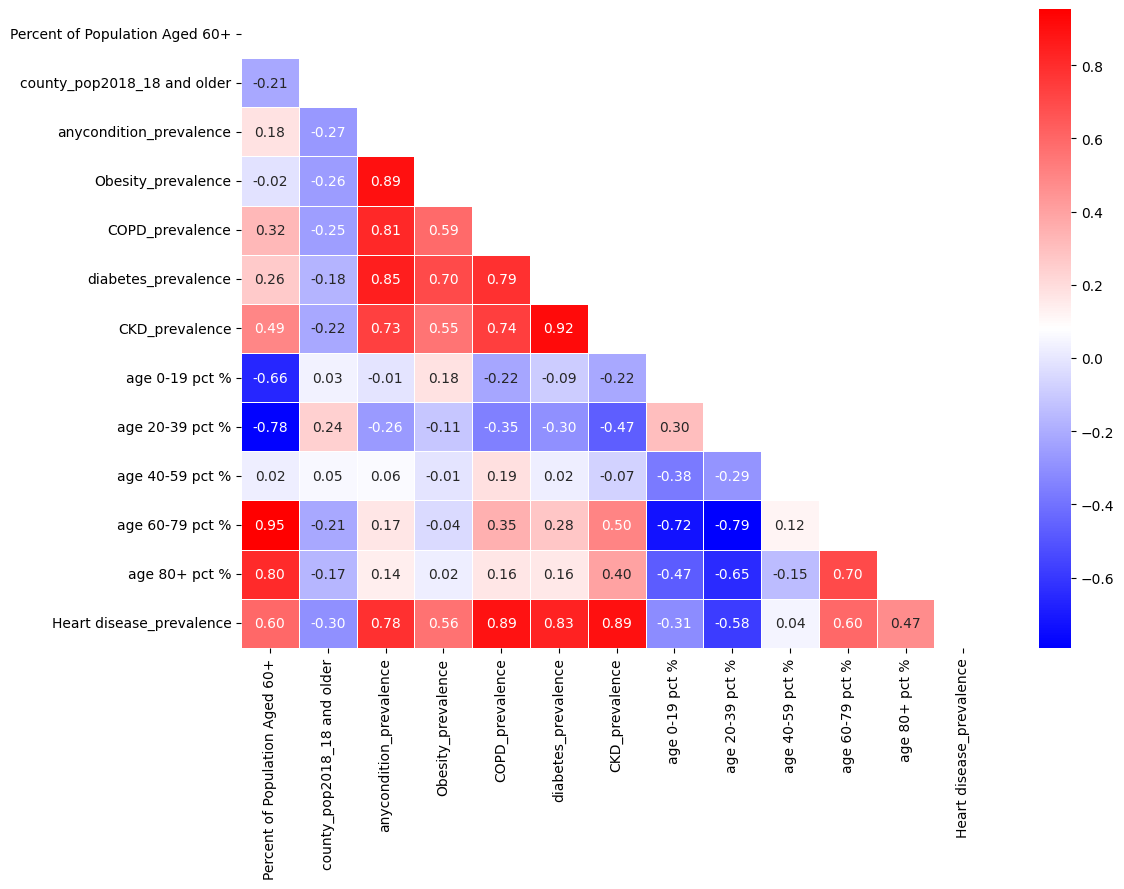

In [ ]:
corr = df[others_filtered].corr

corr = df[others_filtered].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='bwr')

plt.tight_layout()
plt.show()

**Drops**:

In [ ]:
df = df.drop(["county_pop2018_18 and older", "anycondition_prevalence", "Percent of Population Aged 60+"], axis=1)

### **Columnas para el analisis:**

In [ ]:
df.columns

Index(['% White-alone', '% Black-alone', '% NA/AI-alone', '% Asian-alone',
       '% Hawaiian/PI-alone', '% Two or more races',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Civilian_labor_force_2018',
       'Unemployment_rate_2018', 'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active General Surgeons per 100000 Population 2018 (AAMC)',
       'Active Patient Care General Surgeons per 100000

In [ ]:
df.info

<bound method DataFrame.info of       % White-alone  % Black-alone  % NA/AI-alone  % Asian-alone  \
0         76.725239      19.630942       0.480207       1.224798   
1         87.285228       8.940382       0.772399       1.150343   
2         49.069571      48.398376       0.659137       0.454162   
3         76.834821      21.294643       0.437500       0.236607   
4         95.878285       1.642462       0.653527       0.319848   
...             ...            ...            ...            ...   
3135      93.835219       1.375113       1.544680       1.010429   
3136      95.190850       0.758199       0.914172       1.412417   
3137      95.354451       0.827627       1.418789       0.472930   
3138      94.483196       0.507292       1.813570       0.824350   
3139      93.081671       0.688962       1.765466       1.937706   

      % Hawaiian/PI-alone  % Two or more races  \
0                0.111509             1.827305   
1                0.066966             1.784682   
2

**Observaciones y drops finales**:
> * Country_pop2018 se elimina porque ya tenemos una columna que se refiere a ese rango de edad ----> 
> * Me quedo con 46 columnas y todas las filas

In [ ]:
df.columns

Index(['% White-alone', '% Black-alone', '% NA/AI-alone', '% Asian-alone',
       '% Hawaiian/PI-alone', '% Two or more races',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Civilian_labor_force_2018',
       'Unemployment_rate_2018', 'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active General Surgeons per 100000 Population 2018 (AAMC)',
       'Active Patient Care General Surgeons per 100000

## OUTLIERS

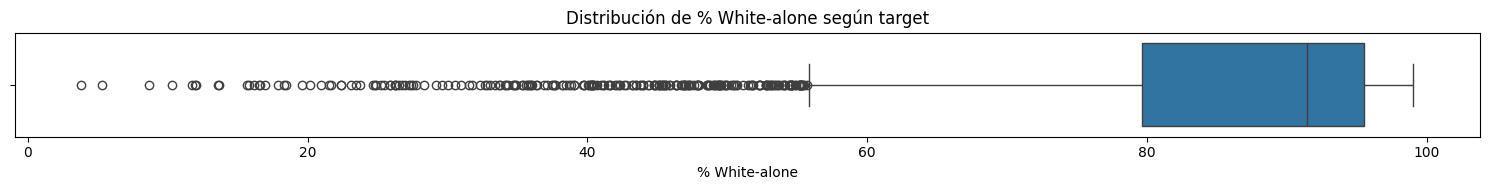

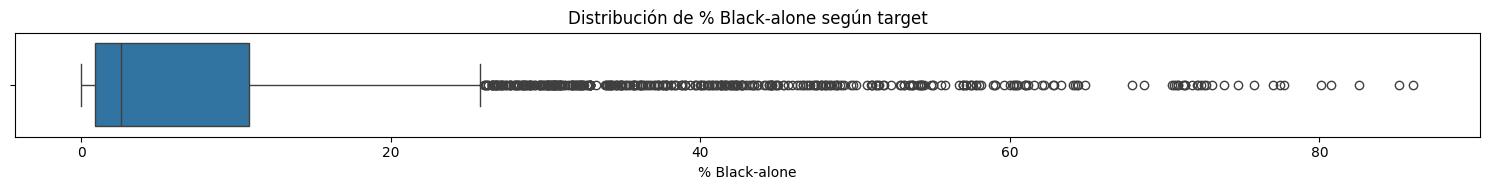

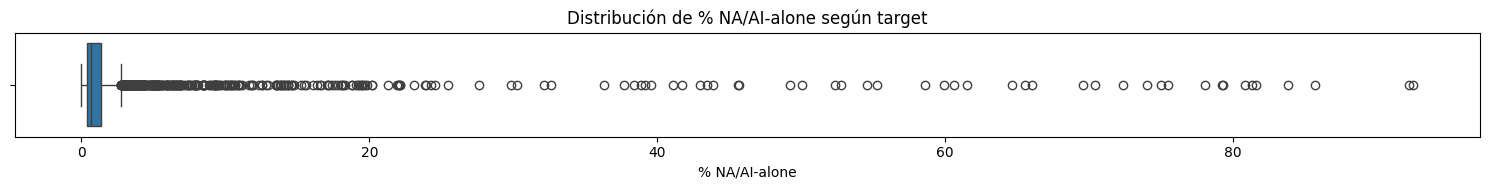

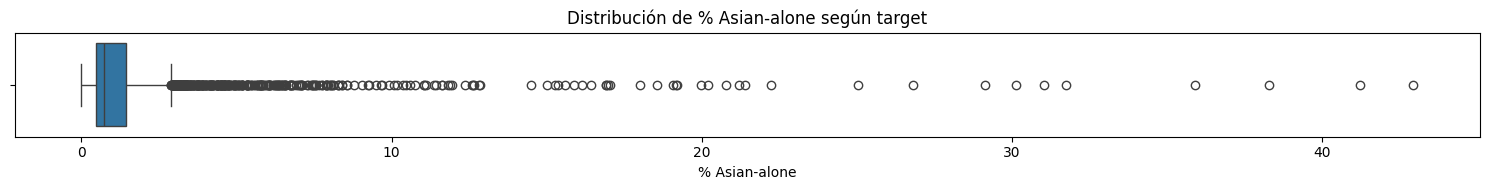

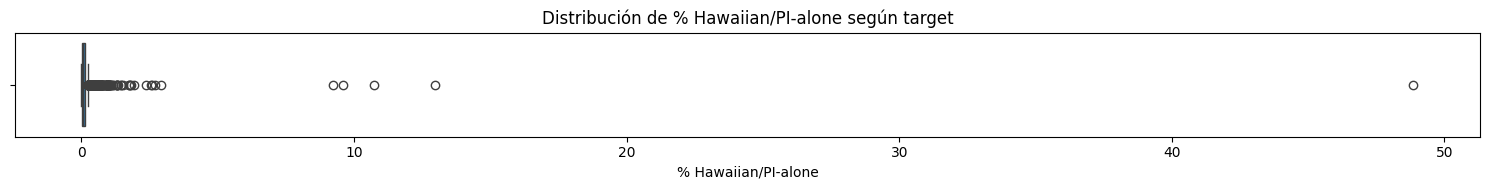

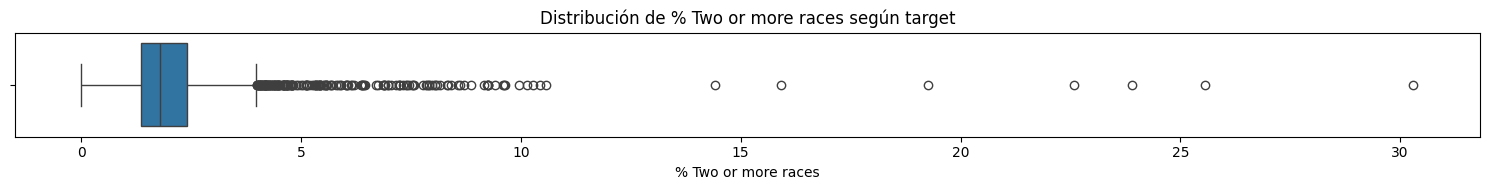

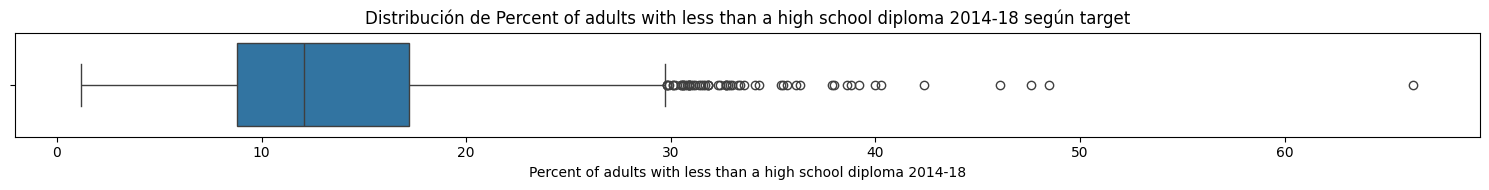

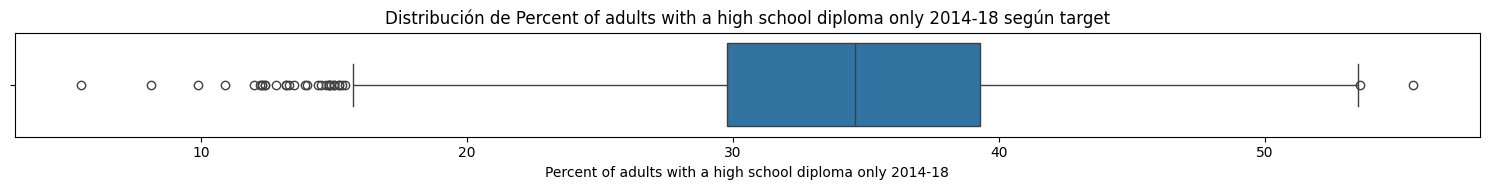

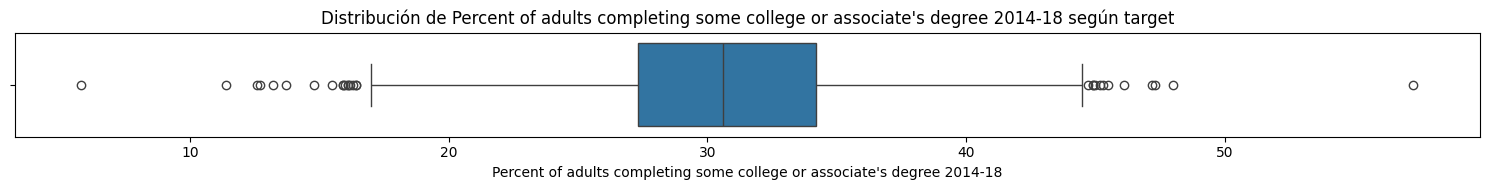

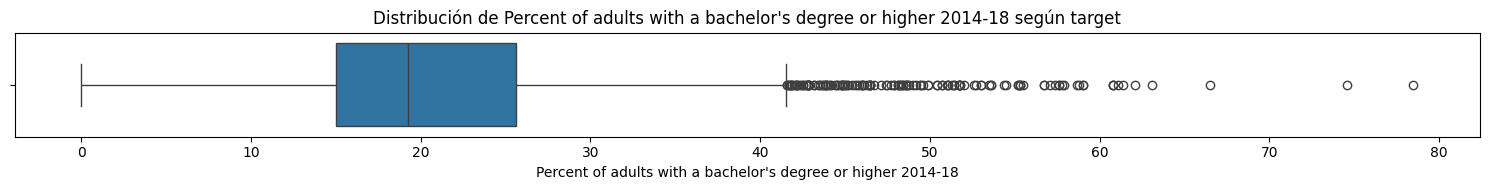

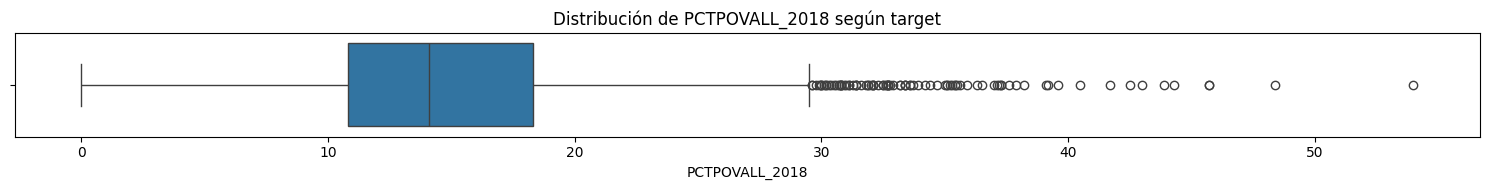

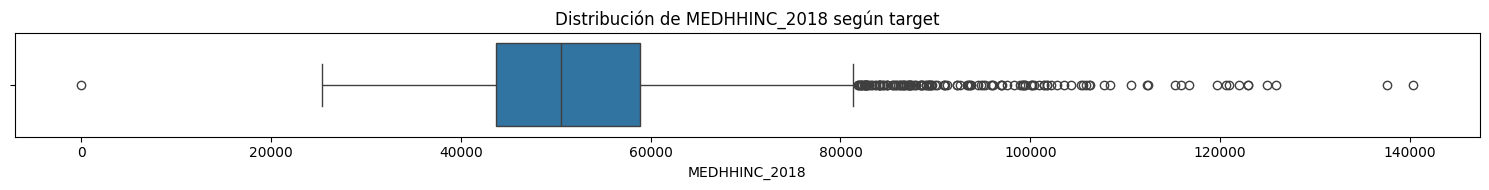

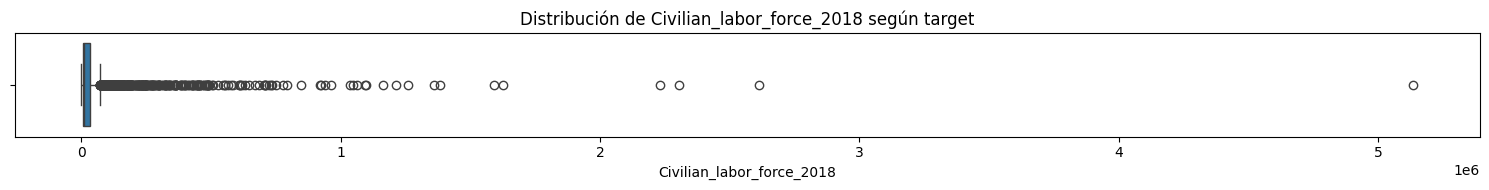

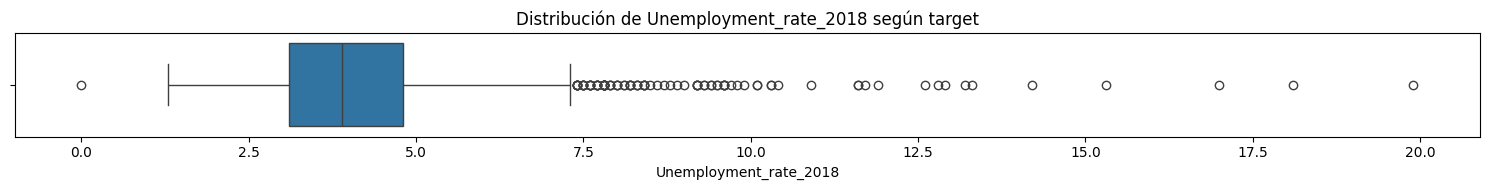

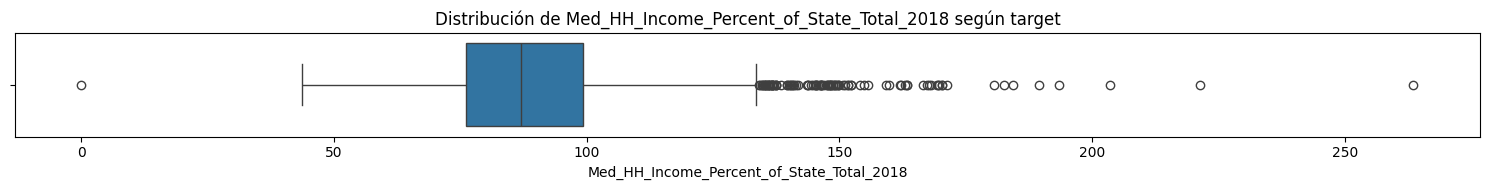

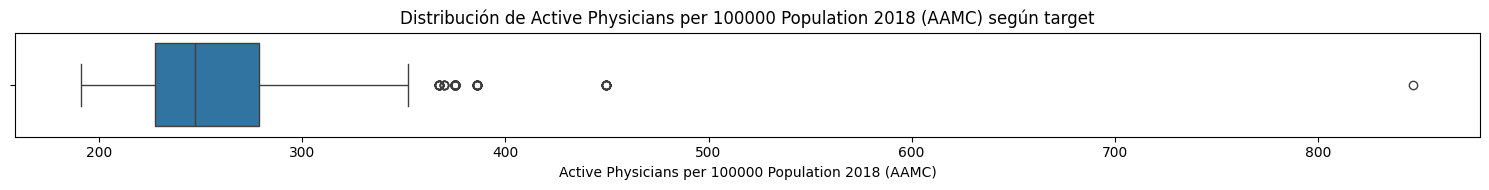

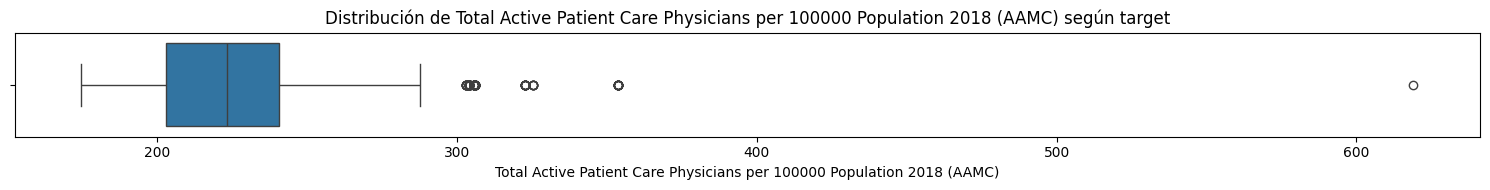

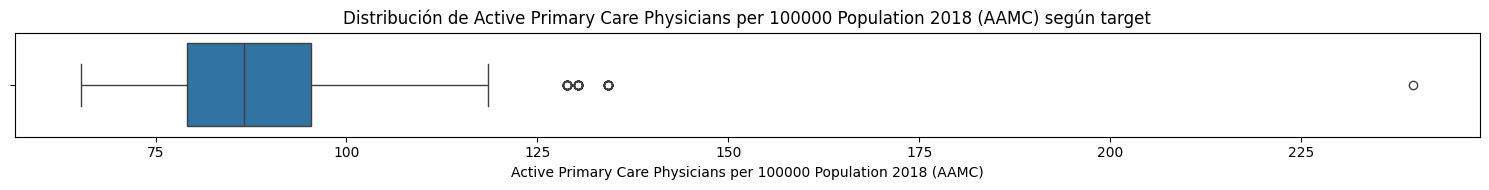

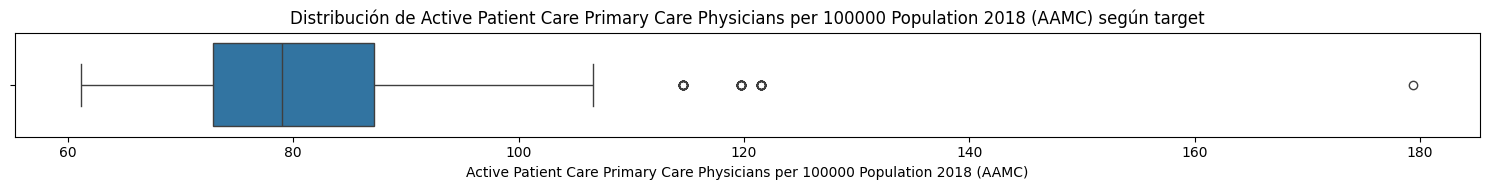

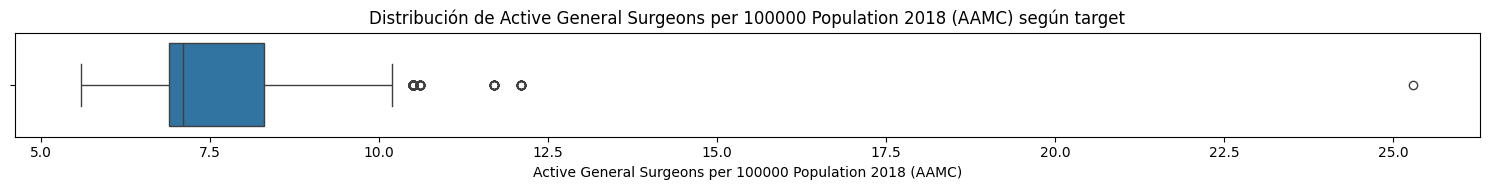

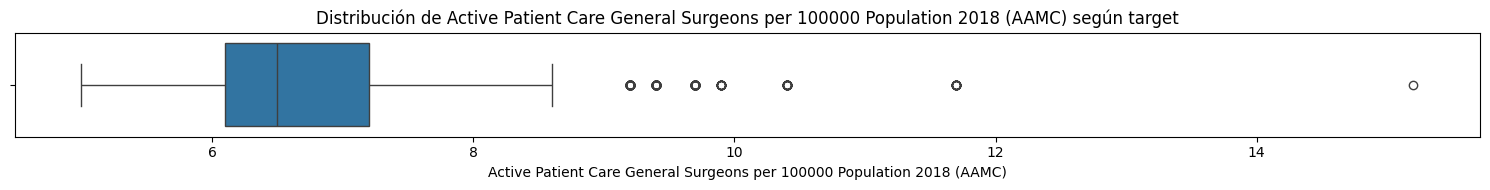

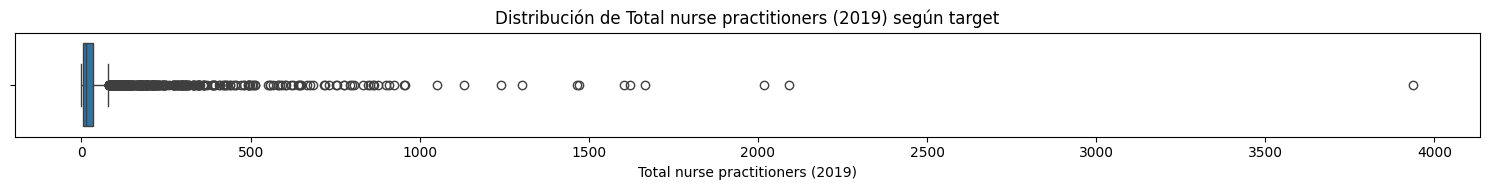

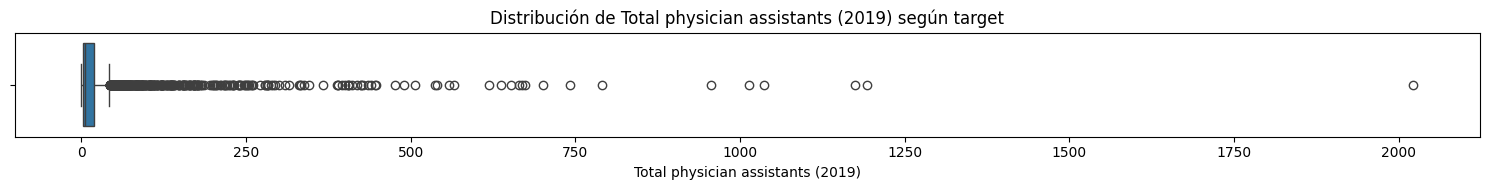

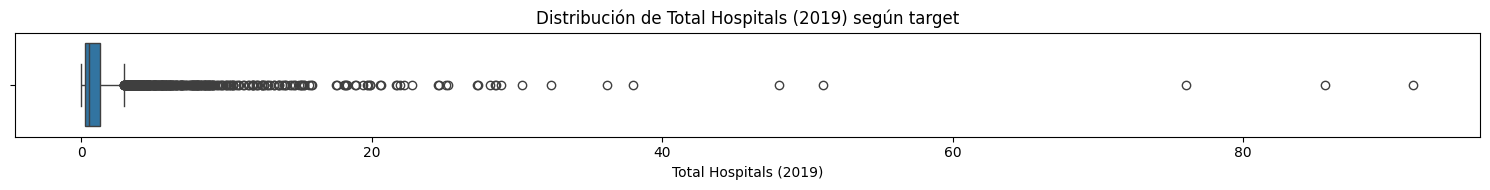

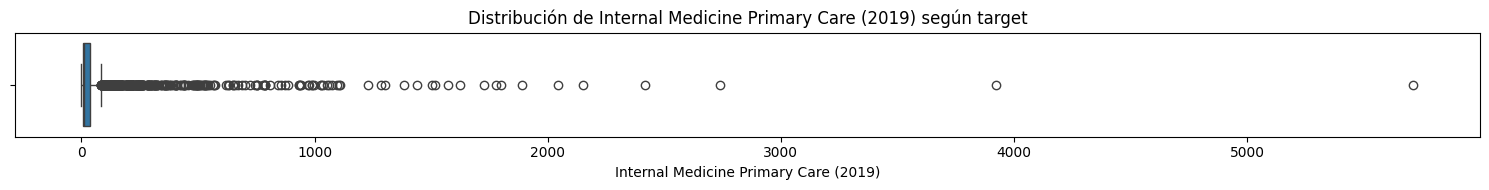

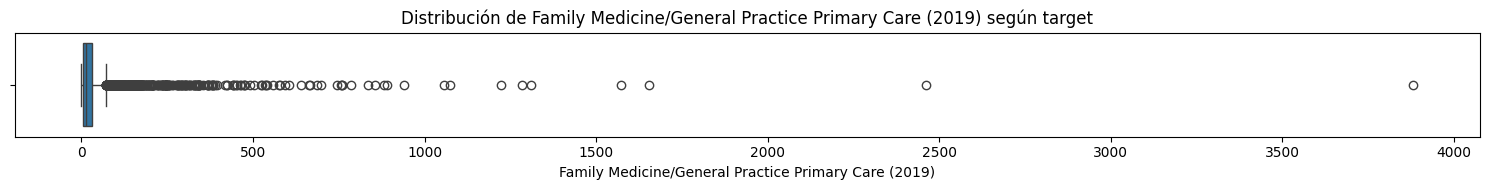

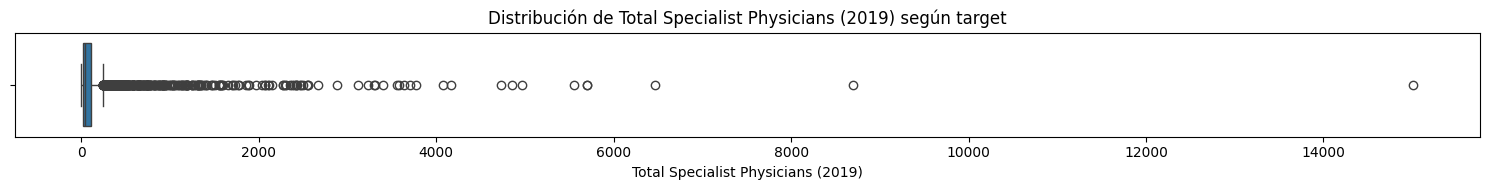

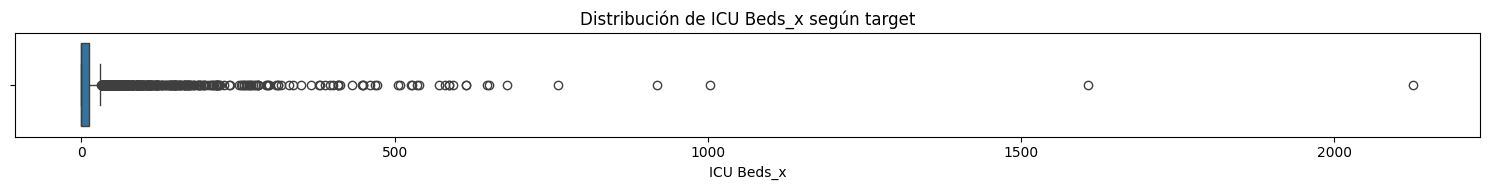

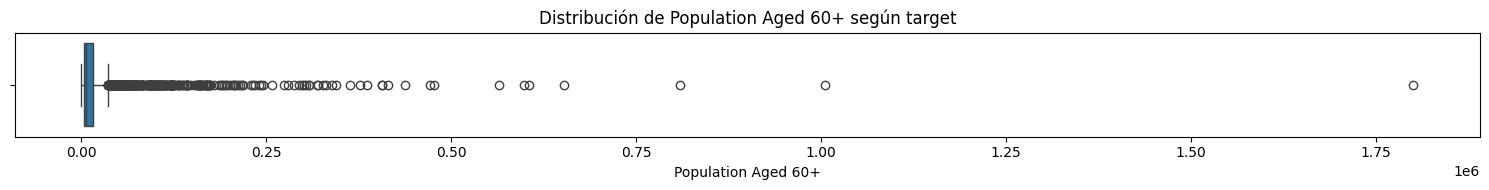

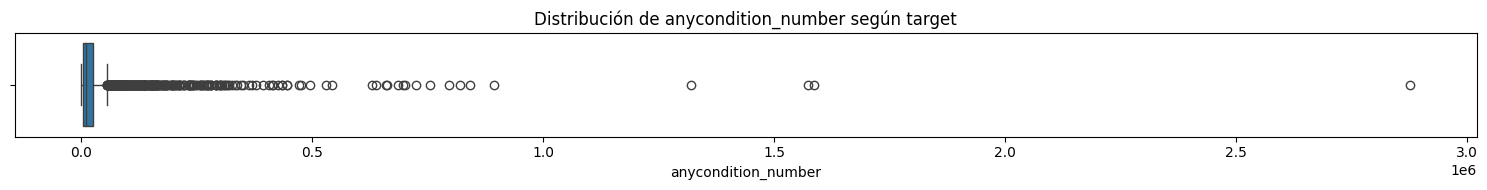

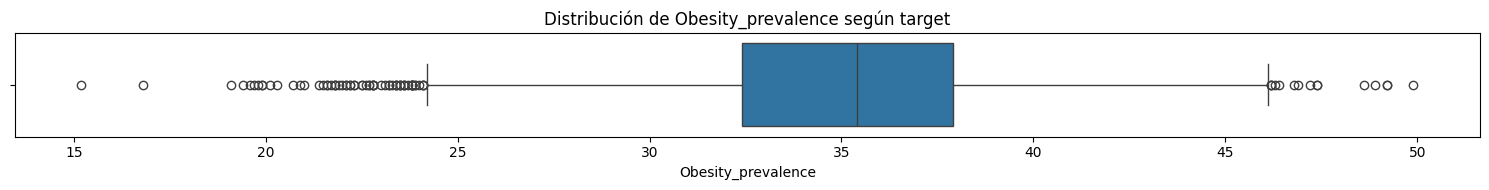

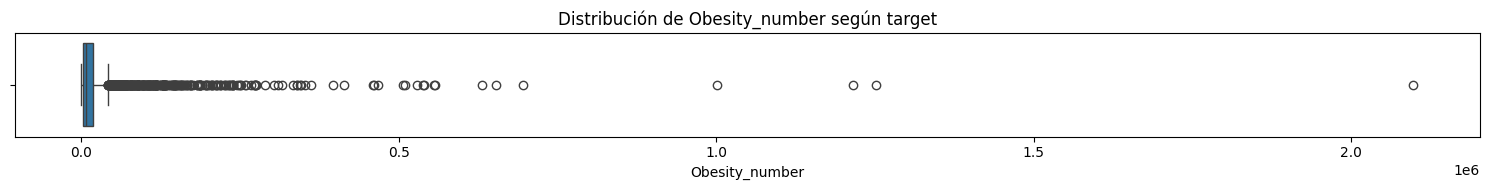

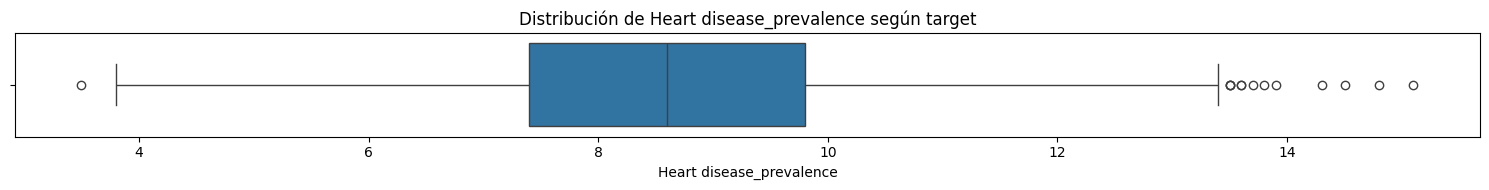

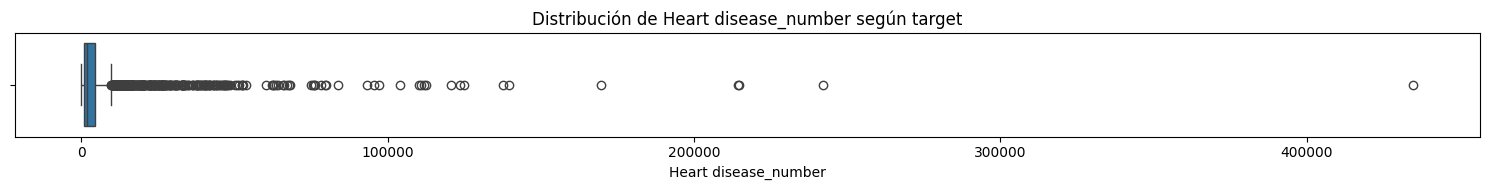

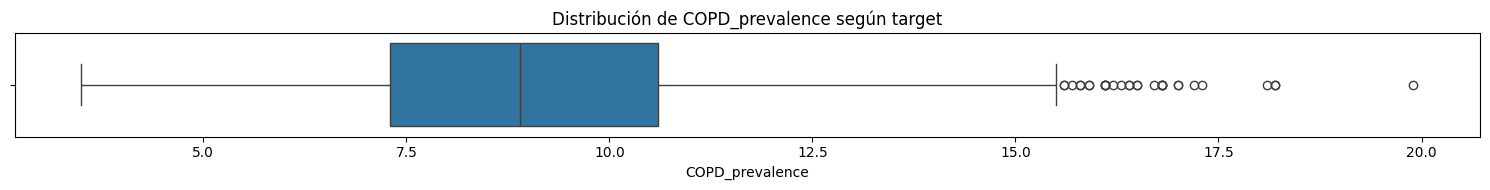

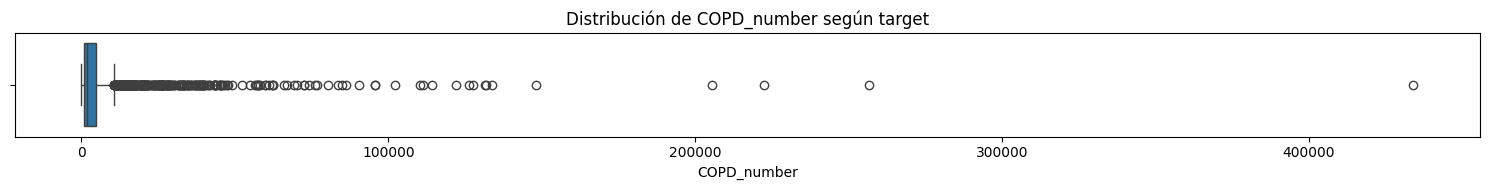

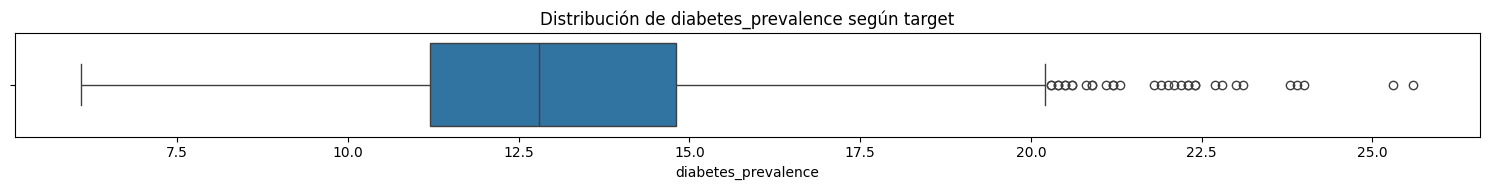

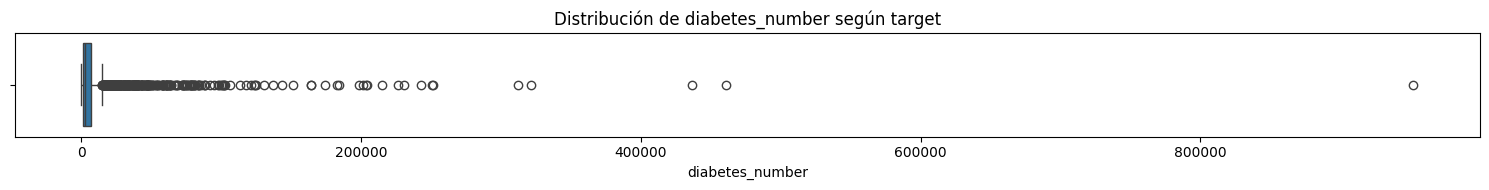

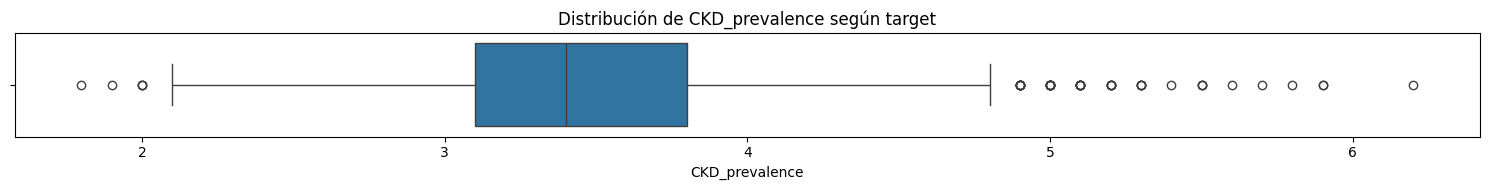

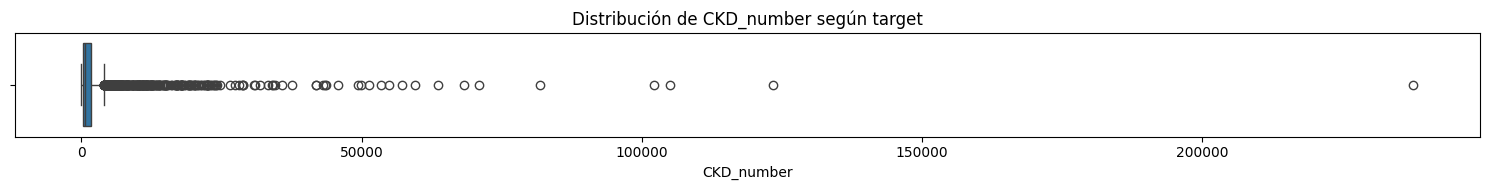

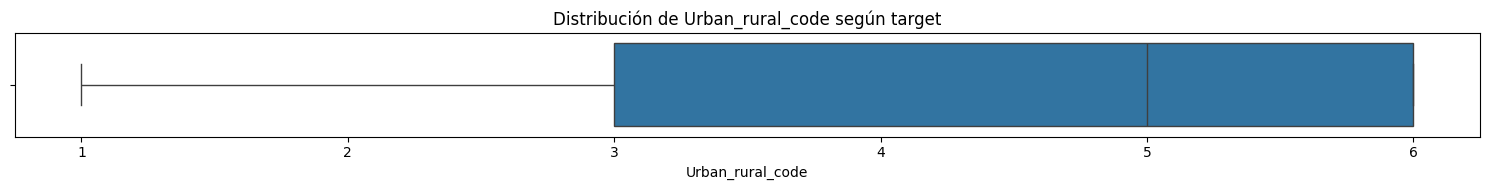

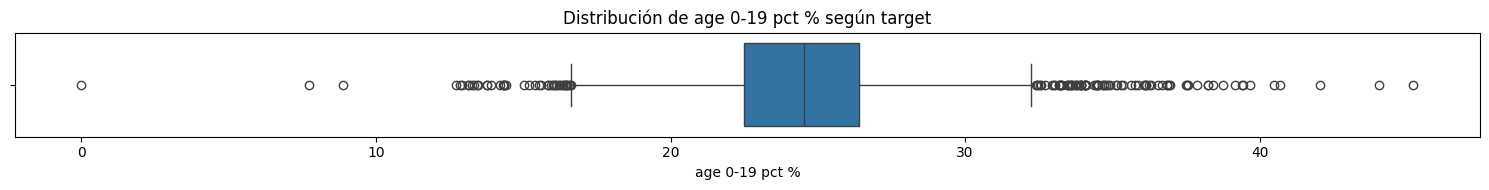

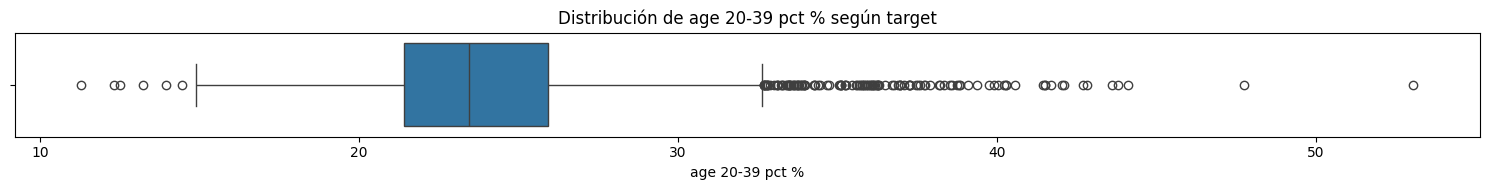

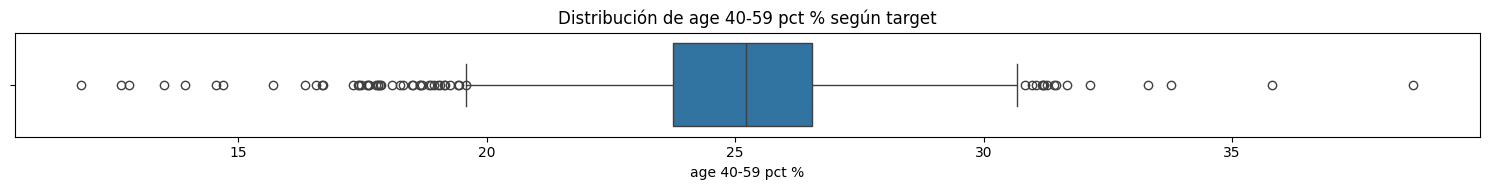

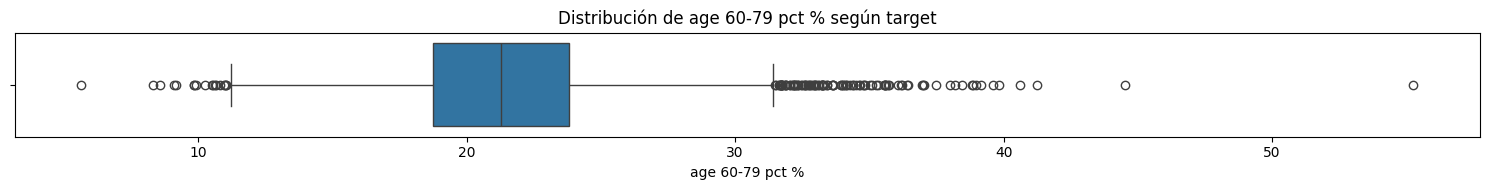

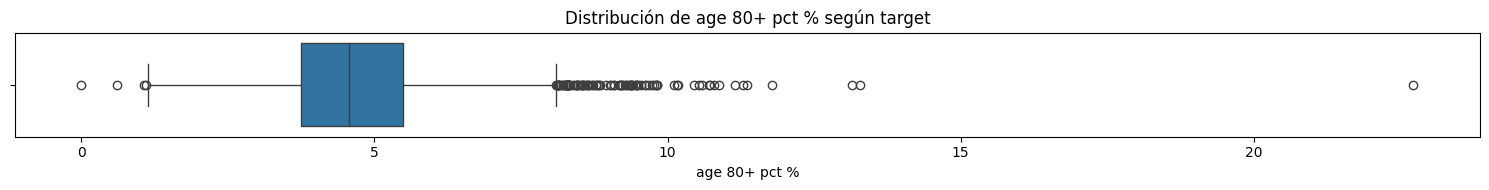

In [ ]:
for columna in df:
    plt.figure(figsize=(15,2))
    sns.boxplot(data=df, x=columna, orient="h")
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

##### análisis y quitar outliers

In [ ]:
# Calculo el Rango inter Cuartil: IQR = Q3(75%) - Q1(25%)
for column in df:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    # Definir los límites inferior y superior
    lower_limit = 0 if (q1 - 1.5 * iqr) < 0 else q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    print(f"Límites superior: {round(upper_limit, 2)}, límite inferior: {round(lower_limit, 2)}, rango intercuartílico: {round(iqr, 2)}")

Límites superior: 119.37, límite inferior: 55.77, rango intercuartílico: 15.9
Límites superior: 25.83, límite inferior: 0, rango intercuartílico: 9.98
Límites superior: 2.75, límite inferior: 0, rango intercuartílico: 0.95
Límites superior: 2.89, límite inferior: 0, rango intercuartílico: 0.97
Límites superior: 0.25, límite inferior: 0, rango intercuartílico: 0.09
Límites superior: 3.99, límite inferior: 0, rango intercuartílico: 1.05
Límites superior: 29.8, límite inferior: 0, rango intercuartílico: 8.4
Límites superior: 53.55, límite inferior: 15.55, rango intercuartílico: 9.5
Límites superior: 44.55, límite inferior: 16.95, rango intercuartílico: 6.9
Límites superior: 41.5, límite inferior: 0, rango intercuartílico: 10.6
Límites superior: 29.55, límite inferior: 0, rango intercuartílico: 7.5
Límites superior: 81540.12, límite inferior: 20959.12, rango intercuartílico: 15145.25
Límites superior: 71711.0, límite inferior: 0, rango intercuartílico: 26716.0
Límites superior: 7.35, límit

**Conclusión:** 
No elimino ningún outlier ya que estamos tratando datos médicos para determinar la población que más sufro de ataques al corazón y al eliminar outliers podríamos perder información relevante en consecuenta aumentaría el error de predicción
Se ha incluido una columna categorica en el gráfico de outliers. No la tengo en cuenta. (urban_rural_code)

## PASO 5: **Split Data: tain & test**

In [ ]:
X = df.drop("Heart disease_prevalence", axis=1)
y = df["Heart disease_prevalence"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

NameError: name 'train_test_split' is not defined

## PASO 6: **Encoding**

### **Guardado de data codificada**

In [ ]:
# Utilizando Pickle (que nos permite guardar objetos de Python)
# with open('/workspaces/betaniammc-machine-learning/models/logistic-regression-label-encoder.pkl', 'wb') as file:
#     pickle.dump(label_encoder_contact, file)

### **Escalado de normalización**

In [ ]:
norm_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler

NameError: name 'StandardScaler' is not defined

### **Generar modelo de entrenamiento de datos (con los datos ya escalados)**

In [ ]:
# Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)
model = LogisticRegression(random_state=18)

# Entrena
model.fit(X_train_cat_le_scaled, y_train)

# ML

## PASO x: **Linear Regression Model**

APUNTES: Cómo funciona la R.Lineal / R. Logística
| Aspecto           | Regresión Logística                |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Clasificación                      |
| Salida del modelo | Probabilidad entre 0 y 1           |
| Toma de decisión  | Por umbral (e.g. 0.5)              |
| Nombre confuso    | Proviene de la estadística clásica |

### **Definiciñon de variables para el modelo:**

1. VAR. DEPENDIENTE:
> * N
2. VARS INDEPENDIENTES:
> * N

### **Paso 1_Import train and test data or Split**

### **Paso 2_Iniciacion y entrenamiento del modelo**

### **Paso 3_Predicción del modelo**

In [ ]:
# pREDECIR EL CONJUNTO DE DATOS TEST
y_pred = model.predict(X_test_cat_le_scaled)
y_pred

In [ ]:
# y_pred = 
# model_accuracy -> accuracy_score(y_test,y_pred)

In [ ]:
# # Confusion matrix:

# titanic_cm = confusion_matrix(y_test, y_pred)

# # Dibujaremos esta matriz para hacerla más visual
# df_cm = pd.DataFrame(titanic_cm)

# plt.figure(figsize=(3, 3))
# sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.show()


**Observaciones:**
> * TP (True Positive)
> * TN (True Negative)
> * FP (False Positive)
> * FN (False Negative)

### **Umbral de decisión:**

In [ ]:
# # predict() from scikit.learn sets 0.5 umbral to convert the predicted probabilities into binary labels
# # Suponiendo que 'model' es tu modelo de regresión logística ya entrenado
# y_proba = model.predict_proba(X_test)

# # Suponiendo que deseas ajustar el umbral a 0.3
# threshold = 0.3
# y_pred_threshold = np.where(y_proba[:, 1] > threshold, 1, 0)

# # Evaluar el rendimiento con el nuevo umbral
# accuracy_score(y_test, y_pred_threshold)


### **Optimicaxion de resultados:**

##### **Hiperparémetros:**

> * ``penalty``, 
> * ``C``, 
> * ``solver``, 
> * ``max_iter``, 
> * ``random_state``, 

In [ ]:
# Definición hiperparams
# GridSearchCV()
# Metodo .fit(X_train,y_train) -> determinates penalty¿?
# grid -> accurary - model accuracy comparation
# model_random_search -> nueva hiperparametrizacion para entrenar el modelo